# Análisis Exploratorio de Datos — Proyecto Integrador CRC

## Identificación de biomarcadores lipidómicos y metabolómicos para la detección temprana de cáncer colorrectal

**Conjunto de datos:** `BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv` (211 observaciones × 138 variables).

**Procedencia del conjunto de datos:** Albóniga, O. E. et al. (2025). *Metabolic Signature in Combination with Fecal Immunochemical Test as a Non-Invasive Tool for Advanced Colorectal Neoplasia Diagnosis*. **Cancers**, 17, 2339. DOI: [10.3390/cancers17142339](https://doi.org/10.3390/cancers17142339). La denominación del archivo (`Data Mat`) corresponde al Supplementary File S1 (`MX_SuppTable.xlsx → DataMat`) del estudio original.

**Alcance del documento:** El presente análisis comprende el Análisis Exploratorio de Datos (EDA) completo, estructurado en los siguientes módulos:

1. Saneamiento y diagnóstico de calidad del conjunto de datos.
2. Caracterización de distribuciones, evaluación comparativa de transformaciones y detección de valores atípicos.
3. Análisis bivariado e identificación de biomarcadores candidatos.
4. Caracterización de la estructura multivariada mediante correlaciones, Análisis de Componentes Principales (PCA), Análisis Discriminante por Mínimos Cuadrados Parciales (PLS-DA) y derivación de atributos estructurales.

> El modelado supervisado se encuentra **fuera del alcance** del presente documento y se reserva para una fase subsecuente del proyecto.

**Variable objetivo:** `group`, de naturaleza categórica con tres niveles:

- **CTRL** — Controles sanos (n = 78).
- **AA** — Adenoma avanzado (n = 58), considerado etapa precursora del adenocarcinoma colorrectal.
- **CRC** — Cáncer colorrectal confirmado mediante colonoscopía (n = 75).

Proyecto Integrador

# Equipo 22 - Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717


## 1. Configuración inicial

In [1]:
# Imports estándar para EDA
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

print('Setup listo.')


Setup listo.


In [ ]:
# Ruta del dataset con búsqueda automática (compatible con estructura de repo)
import os

DATA_FILENAME = 'BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv'

# Buscar el dataset en las ubicaciones posibles según donde se ejecute la libreta
candidate_paths = [
    os.path.join('..', 'data', DATA_FILENAME),        # Si se ejecuta desde notebooks/
    os.path.join('data', DATA_FILENAME),               # Si se ejecuta desde la raíz del repo
    os.path.join('.', DATA_FILENAME),                  # Si está en el mismo directorio
    os.path.join('/Users/sofiaordazlopez/Documents/Proyecto Integrador', DATA_FILENAME),  # Ruta absoluta (entorno original)
]

file_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if file_path is None:
    raise FileNotFoundError(
        f"No se encontró el archivo '{DATA_FILENAME}'. "
        f"Asegúrate de tener el conjunto de datos en la carpeta data/ del repositorio."
    )

print('Ruta del archivo:', file_path)
print('Archivo encontrado:', os.path.exists(file_path))


## 2. Carga del archivo y reconstrucción de encabezados

El archivo CSV presenta una estructura particular: las primeras **cuatro filas** contienen metadatos anidados que describen las columnas, mientras que las observaciones inician en la quinta fila. La reconstrucción manual de encabezados resulta necesaria para preservar la información jerárquica.

| Fila | Contenido |
|---|---|
| 0 | Familia lipídica (`SPHINGOLIPIDS`, `GLYCEROLIPIDS`, entre otras) — presente únicamente en columnas específicas |
| 1 | Subfamilia o denominación de variable clínica (`Ceramides`, `AGE`, `FIT`, etc.) |
| 2 | Notación individual del metabolito (`Cer(d18:1/16:0)`, `CE(18:2)`, etc.) |
| 3 | Composición probable o identificador complementario |
| 4 en adelante | Observaciones individuales (pacientes) |


In [3]:
# Cargar archivo crudo. Encoding latin1 por caracteres especiales en columnas clínicas.
raw = pd.read_csv(file_path, encoding='latin1', header=None)

print(f'Dimensiones del archivo crudo: {raw.shape}')
print('\nPrimeras 4 filas (metadata) — columnas 0-10:')
display(raw.iloc[:4, :11])


Dimensiones del archivo crudo: (215, 138)

Primeras 4 filas (metadata) — columnas 0-10:


,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,GROUP (Class label 1),NaN,FOB yes/no (categorical) (Class label 3),NaN,FIT µg/g (numerical),NaN,NaN,NaN,NaN
1,SAMPLE,SAMPLE.ID,CTRL (CONTROL),GENDER (Class label 2),Sangre Oculta en Heces. Detecta sangrado en el...,AGE,"Prueba Inmunoquimica Fecal, proporciona medici...",Z AGE,Z FOB,Age standarized,FIT standarized
2,INDIVIDUAL NOTATION,NaN,AA (ADENOCARCINOMA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,INDIVIDUAL COMPOSITION OR PROBABLE ID,NaN,CRC (CANCER),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Separar metadata (filas 0-3) y datos (fila 4 en adelante)
metadata_rows = raw.iloc[0:4, :].copy()
data = raw.iloc[4:, :].copy().reset_index(drop=True)

# La fila 0 (familia) tiene NaN en columnas intermedias. ffill propaga la familia
# hacia la derecha para que cada columna lipídica tenga su familia asignada.
families = metadata_rows.iloc[0, :].ffill()
subfamilies = metadata_rows.iloc[1, :]
metabolite_names = metadata_rows.iloc[2, :]
probable_ids = metadata_rows.iloc[3, :]

# Nota importante: en el archivo crudo la familia GLYCEROPHOSPHOLIPIDS aparece bajo
# DOS etiquetas distintas — 'GLYCEROPHOSPHOLIPIDS' (con S) y 'GLYCEROPHOSPHOLIPID'
# (sin S). Es un typo: son la misma familia química, lo confirma el paper original
# (Albóniga et al. 2025) en la sección 2.3. Las unificamos antes de cualquier
# agregación por familia.
families = families.astype('object').replace({'GLYCEROPHOSPHOLIPID': 'GLYCEROPHOSPHOLIPIDS'})

print('Familias únicas detectadas (después de unificación):')
print(families.dropna().unique())


Familias únicas detectadas (después de unificación):
['GROUP (Class label 1)' 'FOB yes/no (categorical) (Class label 3)'
 'FIT  µg/g (numerical)' 'SPHINGOLIPIDS' 'STEROL LIPID'
 'GLYCEROPHOSPHOLIPIDS' 'GLYCEROLIPIDS']


In [5]:
# Mapeo manual de las primeras 11 columnas (variables clínicas e identificadores)
base_names = {
    0: 'sample',
    1: 'sample_id',
    2: 'group',
    3: 'gender',
    4: 'fob',
    5: 'age',
    6: 'fit_ug_g',
    7: 'z_age',
    8: 'z_fob',
    9: 'age_standardized',
    10: 'fit_standardized'
}

new_cols = []
seen = {}

for i in range(raw.shape[1]):
    if i in base_names:
        col = base_names[i]
    else:
        name = metabolite_names.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = subfamilies.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = f'feature_{i}'
        col = re.sub(r'\s+', ' ', str(name).strip())
        if col in seen:
            seen[col] += 1
            col = f'{col}__dup{seen[col]}'
        else:
            seen[col] = 0
    new_cols.append(col)

data.columns = new_cols
print(f'Columnas asignadas: {len(new_cols)}')
print(f'Primeras 15: {new_cols[:15]}')


Columnas asignadas: 138
Primeras 15: ['sample', 'sample_id', 'group', 'gender', 'fob', 'age', 'fit_ug_g', 'z_age', 'z_fob', 'age_standardized', 'fit_standardized', 'Cer(d18:1/16:0)', 'Cer(d18:1/20:0)', 'Cer(d18:1/22:0)', 'Cer(d18:1/23:0)']


In [6]:
# Construir tabla de metadata para variables lipídicas/metabólicas
feature_metadata = []
for i, col in enumerate(new_cols):
    if i >= 11:
        feature_metadata.append({
            'column': col,
            'family': str(families.iloc[i]).strip() if pd.notna(families.iloc[i]) else 'Unknown',
            'subfamily': str(subfamilies.iloc[i]).strip() if pd.notna(subfamilies.iloc[i]) else 'Unknown',
            'notation': str(metabolite_names.iloc[i]).strip() if pd.notna(metabolite_names.iloc[i]) else col,
            'probable_id': str(probable_ids.iloc[i]).strip() if pd.notna(probable_ids.iloc[i]) else ''
        })

feature_metadata = pd.DataFrame(feature_metadata)
print(f'Variables lipídicas/metabólicas catalogadas: {len(feature_metadata)}')
print('\nDistribución por familia:')
print(feature_metadata['family'].value_counts())
print('\nDistribución por subfamilia:')
print(feature_metadata['subfamily'].value_counts())


Variables lipídicas/metabólicas catalogadas: 127

Distribución por familia:
family
GLYCEROLIPIDS           60
GLYCEROPHOSPHOLIPIDS    35
SPHINGOLIPIDS           23
STEROL LIPID             9
Name: count, dtype: int64

Distribución por subfamilia:
subfamily
Triacylglycerols                             51
Diacylglycerophosphocholine                  17
Sphingomyelin                                14
Cholesteryl Ester                             8
Diacylglycerols                               8
1-ether, 2-acylglycerophosphocholine          8
Ceramides                                     7
Diacylglycerophosphoethanolamine              6
1-ether, 2-acylglycerophosphoethanolamine     4
Monohexosylceramides                          2
Cholesterol and derivatives                   1
Monoacylglycerols                             1
Name: count, dtype: int64


## 3. Estandarización de tipos de datos

Se procede a la normalización de las variables categóricas mediante conversión a cadenas de caracteres, recortado de espacios y codificación explícita de valores faltantes. Las columnas restantes (lípidos y variables clínicas numéricas) se convierten a tipo `float`. Adicionalmente, se descartan las observaciones que carezcan de etiqueta de grupo (`group`), por cuanto no aportan información al análisis supervisado posterior.


In [7]:
# Normalizar variables categóricas
for col in ['group', 'gender', 'fob']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace({'nan': np.nan, '': np.nan})

id_and_label_cols = ['sample', 'sample_id', 'group', 'gender', 'fob']
for col in data.columns:
    if col not in id_and_label_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

before = data.shape[0]
data = data.dropna(subset=['group']).reset_index(drop=True)
after = data.shape[0]

print(f'Filas eliminadas por no tener etiqueta de grupo: {before - after}')
print(f'Dimensiones del dataset final: {data.shape}')


Filas eliminadas por no tener etiqueta de grupo: 0
Dimensiones del dataset final: (211, 138)


## 4. Verificación de integridad

Se verifica la consistencia del conjunto de datos tras el saneamiento inicial:

- Distribución de la variable objetivo (valores esperados según el estudio original: CTRL = 78, AA = 58, CRC = 75).
- Unificación correcta de las familias lipídicas a cuatro categorías.
- Asignación adecuada de tipos de datos a cada columna.


In [8]:
# Distribución de grupos
print('Distribución de la variable objetivo:')
display(data['group'].value_counts().to_frame('n'))

# Verificar contra el paper (CTRL=78, AA=58, CRC=75)
expected = {'CTRL': 78, 'AA': 58, 'CRC': 75}
actual = data['group'].value_counts().to_dict()
match = all(actual.get(k) == v for k, v in expected.items())
print(f'\n¿Coincide con el paper? {"SÍ" if match else "NO"}')


Distribución de la variable objetivo:


,n
group,
CTRL,78
CRC,75
AA,58



¿Coincide con el paper? SÍ


In [9]:
# Verificar familias (esperado: 4)
print(f'Total familias únicas: {feature_metadata["family"].nunique()}')
display(feature_metadata['family'].value_counts().to_frame('n_variables'))


Total familias únicas: 4


,n_variables
family,
GLYCEROLIPIDS,60
GLYCEROPHOSPHOLIPIDS,35
SPHINGOLIPIDS,23
STEROL LIPID,9


In [10]:
# Variables de cada tipo
target_col = 'group'
clinical_numeric_cols = [c for c in ['age', 'fit_ug_g', 'z_age', 'z_fob', 'age_standardized', 'fit_standardized'] if c in data.columns]
categorical_cols = [c for c in ['gender', 'fob'] if c in data.columns]
lipid_cols = [c for c in feature_metadata['column'].tolist() if c in data.columns]

print(f'Variables clínicas numéricas ({len(clinical_numeric_cols)}): {clinical_numeric_cols}')
print(f'Variables categóricas ({len(categorical_cols)}): {categorical_cols}')
print(f'Variables lipídicas/metabólicas: {len(lipid_cols)}')


Variables clínicas numéricas (6): ['age', 'fit_ug_g', 'z_age', 'z_fob', 'age_standardized', 'fit_standardized']
Variables categóricas (2): ['gender', 'fob']
Variables lipídicas/metabólicas: 127


In [11]:
# Tipos de datos (primeras 15 columnas)
print('Tipos de datos (primeras 15 columnas):')
display(data.dtypes.head(15).to_frame('dtype'))


Tipos de datos (primeras 15 columnas):


,dtype
sample,str
sample_id,str
group,str
gender,str
fob,str
age,int64
fit_ug_g,int64
z_age,float64
z_fob,float64
age_standardized,float64


---

> **Paso 1 completado.** Tenemos el dataset cargado, encabezados reconstruidos, familias unificadas (4 totales), tipos correctos y 211 muestras × 4 familias × 127 lípidos. Listo para el siguiente bloque: análisis de calidad de datos (missingness, duplicados, redundancias).


# Paso 2 — Diagnóstico de calidad del conjunto de datos

Previo a cualquier análisis inferencial, resulta indispensable caracterizar el estado del conjunto de datos. El presente módulo aborda las siguientes interrogantes:

1. ¿Existen valores faltantes? ¿Cómo se distribuyen entre variables y grupos?
2. ¿Se identifican observaciones duplicadas o identificadores repetidos?
3. ¿Existen variables redundantes (versiones estandarizadas que duplican información)?
4. ¿Cuál es la cardinalidad efectiva de las variables categóricas?

> El propósito de este paso trasciende la mera identificación de problemas: cada hallazgo debe traducirse en una **decisión metodológica documentada**.


## 2.1 Análisis de valores faltantes

### Fundamentación

En lipidómica, un valor faltante suele indicar que la concentración del metabolito se encuentra por debajo del **límite de detección (LOD)** del instrumento. Esta circunstancia no constituye ruido aleatorio: el "no medido" porta información biológica relevante, en tanto sugiere que el lípido en cuestión se encuentra en niveles muy bajos en dicha observación.

En consecuencia, resulta necesario verificar dos aspectos fundamentales:

1. **Magnitud y distribución de los faltantes** a lo largo de variables y observaciones.
2. **Dependencia de la ausencia respecto al grupo (CTRL/AA/CRC).** Si la frecuencia de faltantes difiere significativamente entre grupos, el patrón corresponde a **MAR/MNAR** (no aleatorio) y la imputación con la mediana global resultaría inapropiada al borrar señal biológica genuina.


In [12]:
# 2.1.1 Resumen global de missingness por variable
missing_summary = pd.DataFrame({
 'variable': data.columns,
 'missing_count': data.isna().sum().values,
 'missing_percent': (data.isna().mean().values * 100).round(2)
}).sort_values('missing_percent', ascending=False)

# Conteos rápidos
n_complete = (missing_summary['missing_count'] == 0).sum()
n_gt_20 = (missing_summary['missing_percent'] > 20).sum()
n_gt_40 = (missing_summary['missing_percent'] > 40).sum()

print(f'Variables sin faltantes: {n_complete} / {len(data.columns)}')
print(f'Variables con >20% faltantes: {n_gt_20}')
print(f'Variables con >40% faltantes: {n_gt_40}')
print(f'\nTop 15 variables con más faltantes:')
display(missing_summary.head(15))


Variables sin faltantes: 56 / 138
Variables con >20% faltantes: 27
Variables con >40% faltantes: 5

Top 15 variables con más faltantes:


,variable,missing_count,missing_percent
47,PC(33:0),113,53.55
81,SM(36:2),110,52.13
71,PE(P-18:0/20:4),109,51.66
97,TG(55:2),102,48.34
79,SM(d18:1/17:0),90,42.65
74,SM(d18:0/18:0),83,39.34
38,PC(36:5),83,39.34
70,PE(P-18:0/18:1),81,38.39
23,CE(20:5),74,35.07
88,TG(42:0),74,35.07


**Lectura del resultado:**

- De las 138 columnas totales, **56 carecen de valores faltantes** (incluye variables clínicas, identificadores y aproximadamente 45 lípidos completos).
- **27 lípidos** presentan más del 20% de valores faltantes — proporción que exige una decisión explícita sobre su tratamiento.
- **5 lípidos** superan el umbral del 40% de faltantes y constituyen candidatos a eliminación: `PC(33:0)` (53.5%), `SM(36:2)` (52.1%), `PE(P-18:0/20:4)` (51.7%), `TG(55:2)` (48.3%) y `SM(d18:1/17:0)` (42.7%).
- La nomenclatura del subconjunto más afectado sugiere que las familias **fosfatidilcolinas (PC)**, **esfingomielinas (SM)** y **triglicéridos (TG)** concentran la mayor parte del problema; no se trata de un patrón homogéneo entre familias.


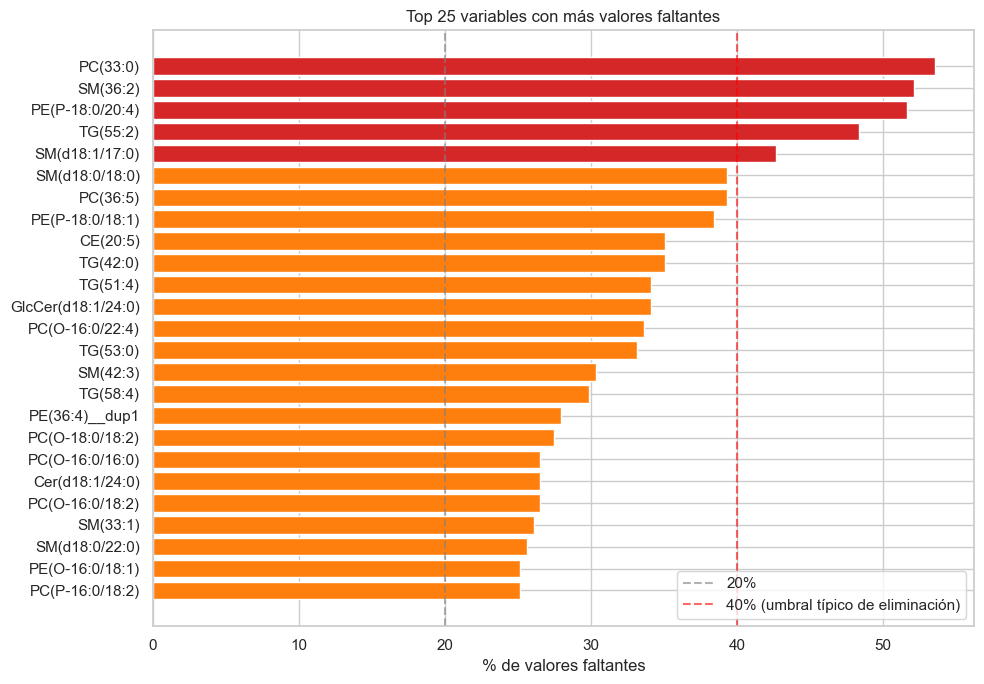

In [13]:
# 2.1.2 Visualización: barras horizontales del top 25
top_missing = missing_summary.head(25).sort_values('missing_percent')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if p > 40 else '#ff7f0e' if p > 20 else '#1f77b4'
 for p in top_missing['missing_percent']]
ax.barh(top_missing['variable'], top_missing['missing_percent'], color=colors)
ax.axvline(20, color='gray', linestyle='--', alpha=0.6, label='20%')
ax.axvline(40, color='red', linestyle='--', alpha=0.6, label='40% (umbral típico de eliminación)')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 25 variables con más valores faltantes')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- Las **cinco barras rojas** identifican las variables con más del 40% de faltantes: `PC(33:0)` (~54%), `SM(36:2)` (~52%), `PE(P-18:0/20:4)` (~52%), `TG(55:2)` (~48%) y `SM(d18:1/17:0)` (~43%).
- A continuación se aprecia un conjunto de **barras anaranjadas** que cubren el rango 25–40%, correspondiente a aproximadamente 20 lípidos que se retendrán para análisis bajo un protocolo de imputación cuidadoso. Entre estos figuran `SM(d18:0/18:0)`, `PC(36:5)`, `PE(P-18:0/18:1)`, `CE(20:5)`, `TG(42:0)`, `TG(51:4)`, `GlcCer(d18:1/24:0)`, entre otros.
- La distribución del top 25 desciende de forma gradual sin saltos pronunciados, indicando un gradiente continuo de severidad de faltantes.
- Las líneas punteadas (20% y 40%) explicitan los umbrales que sustentan la decisión de eliminación.


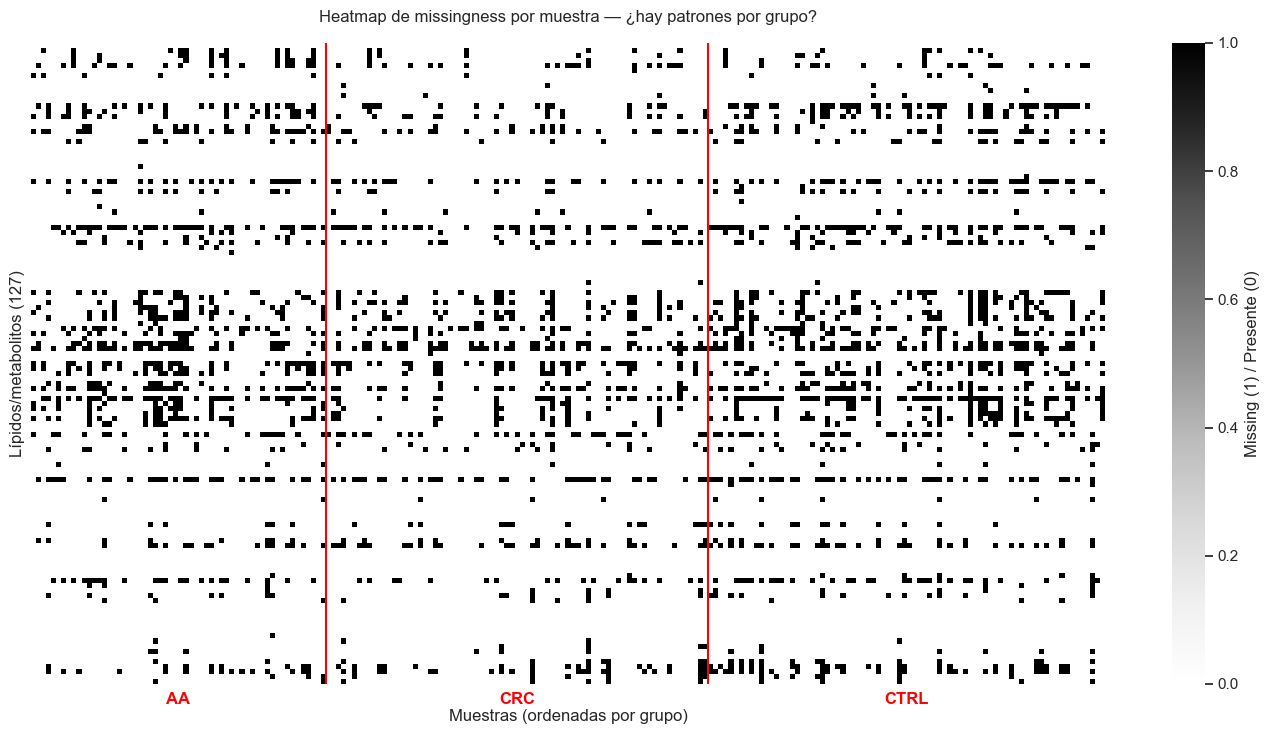

In [14]:
# 2.1.3 Heatmap de missingness ordenado por grupo
# Pregunta clave: ¿se ven patrones de ausencia compartidos entre muestras de un mismo grupo?
data_sorted = data.sort_values('group').reset_index(drop=True)
group_labels_sorted = data_sorted['group'].values

# Solo lípidos para que el heatmap sea legible (las clínicas no tienen NaN)
miss_matrix = data_sorted[lipid_cols].isna().astype(int)
n_lipids = len(lipid_cols)

fig, ax = plt.subplots(figsize=(14, 7.5))
sns.heatmap(miss_matrix.T, cmap='Greys', cbar_kws={'label': 'Missing (1) / Presente (0)'},
            xticklabels=False, yticklabels=False, ax=ax)

# Identificar límites de cada grupo (en coordenadas X del heatmap)
group_changes = [0]
prev = group_labels_sorted[0]
for idx, g in enumerate(group_labels_sorted):
    if g != prev:
        group_changes.append(idx)
        prev = g
group_changes.append(len(group_labels_sorted))

# Líneas verticales para separar grupos
for idx in group_changes[1:-1]:
    ax.axvline(idx, color='red', linewidth=1.5)

# Etiquetas de grupo DEBAJO del heatmap (no arriba donde va el título)
for i in range(len(group_changes) - 1):
    start = group_changes[i]
    end = group_changes[i + 1]
    center_x = (start + end) / 2
    label = group_labels_sorted[start]
    # y=n_lipids+5 está debajo del heatmap (ya que el eje y está invertido en heatmap)
    ax.text(center_x, n_lipids + 4, label, ha='center', fontsize=12,
            fontweight='bold', color='red')

ax.set_xlabel('Muestras (ordenadas por grupo)', labelpad=18)
ax.set_ylabel('Lípidos/metabolitos (127)')
# pad=15 separa el título del borde superior del heatmap
ax.set_title('Heatmap de missingness por muestra — ¿hay patrones por grupo?', pad=15)
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- El orden visualizado de los grupos en el eje X es **AA — CRC — CTRL** (ordenamiento alfabético).
- Se observan **bandas horizontales oscuras** consistentes a lo largo de todas las observaciones, correspondientes a los lípidos crónicamente ausentes (PC(33:0), SM(36:2), PE(P-18:0/20:4), entre otros).
- **Comparación visual entre franjas:** el grupo **CRC** (franja central) presenta visiblemente **menos píxeles negros** que AA (izquierda) y CTRL (derecha). Tanto AA como CTRL muestran densidades de faltantes similares y mayores.
- Esta observación es consistente con el resultado del test χ²: en lípidos como `SM(36:2)`, los faltantes se concentran predominantemente en CTRL (53) y AA (35) frente a CRC (22).
- **Interpretación biológica:** la menor cantidad de faltantes en CRC sugiere que las concentraciones de los lípidos afectados se encuentran por encima del límite de detección en CRC (consistente con incrementos sistemáticos de CEs y SMs en cáncer), mientras que en AA y CTRL estas concentraciones se ubican con mayor frecuencia por debajo del LOD.
- Se identifican adicionalmente algunas **bandas verticales aisladas** en las tres franjas, correspondientes a observaciones individuales con perfil incompleto.


In [15]:
# 2.1.4 Test chi-cuadrado: ¿la ausencia depende del grupo?
from scipy.stats import chi2_contingency

chi2_results = []
for col in lipid_cols:
    pct = data[col].isna().mean() * 100
    if pct < 5:
        continue
    contingency = pd.crosstab(data['group'], data[col].isna())
    if contingency.shape[1] < 2:
        continue
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'variable': col,
        'missing_pct': round(pct, 2),
        'missing_CTRL': contingency.loc['CTRL', True] if True in contingency.columns else 0,
        'missing_AA':   contingency.loc['AA', True] if True in contingency.columns else 0,
        'missing_CRC':  contingency.loc['CRC', True] if True in contingency.columns else 0,
        'chi2': round(chi2, 2),
        'p_value': p
    })

chi2_results = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_results['significant_005'] = chi2_results['p_value'] < 0.05

n_sig = chi2_results['significant_005'].sum()
print(f'Variables con missingness dependiente del grupo (p<0.05): {n_sig} de {len(chi2_results)}')
print('\nTop 15 variables con dependencia más fuerte:')
display(chi2_results.head(15))


Variables con missingness dependiente del grupo (p<0.05): 13 de 56

Top 15 variables con dependencia más fuerte:


,variable,missing_pct,missing_CTRL,missing_AA,missing_CRC,chi2,p_value,significant_005
34,SM(36:2),52.13,53,35,22,25.01,0.000004,True
5,CE(20:5),35.07,41,19,14,19.48,0.000059,True
2,Cer(d18:1/23:0),7.11,3,10,2,12.52,0.001915,True
38,SM(42:3),30.33,29,23,12,11.41,0.003335,True
12,PC(38:5),18.96,22,12,6,10.32,0.005752,True
32,SM(d18:2/16:0),15.64,16,13,4,9.46,0.008830,True
25,PE(O-16:0/18:1),25.12,25,18,10,8.61,0.013497,True
6,CE(22:4),16.59,16,14,5,8.59,0.013613,True
10,PC(32:1),15.17,18,9,5,8.01,0.018217,True
18,PC(O-16:0/16:0),26.54,28,16,12,7.81,0.020149,True


**Lectura del resultado:**

- **13 de 56 lípidos** evaluados (aquellos con más del 5% de faltantes) muestran un patrón de ausencia significativamente dependiente del grupo (p < 0.05). Bajo la hipótesis nula de independencia, se esperarían aproximadamente 3 falsos positivos por azar; la observación de 13 hits excede claramente esta expectativa.
- El caso más pronunciado corresponde a **`SM(36:2)`**, con **53 faltantes en CTRL frente a 22 en CRC** — más del doble de ausencias en el grupo sano. Una dirección análoga se observa en `CE(20:5)` (41 frente a 14).
- Un caso particularmente interesante es `Cer(d18:1/23:0)`: presenta solo 7.1% de faltantes globales, pero su distribución se concentra en AA (10) frente a CTRL (3) y CRC (2), lo que sugiere comportamiento específico de la etapa intermedia.
- **Conclusión:** el mecanismo de ausencia se clasifica como **MAR o MNAR**, no MCAR. La ausencia transporta información biológica (presumiblemente concentraciones por debajo del límite de detección, más frecuentes en sanos para ciertos lípidos elevados en cáncer).


### Síntesis interpretativa y decisión metodológica

**Hallazgos sintetizados:**

- 27 lípidos presentan más del 20% de faltantes; 5 superan el 40% (`PC(33:0)` 53.5%, `SM(36:2)` 52.1%, `PE(P-18:0/20:4)` 51.7%, `TG(55:2)` 48.3%, `SM(d18:1/17:0)` 42.7%).
- El mapa de calor revela tanto bandas horizontales (lípidos crónicamente ausentes) como verticales (observaciones con perfil incompleto), con mayor densidad de faltantes en la franja CTRL.
- El test χ² confirma cuantitativamente la dependencia: 13 de 56 lípidos exhiben missingness significativamente asociado al grupo (p < 0.05). El caso `SM(36:2)` ilustra el patrón: 53 faltantes en CTRL frente a 22 en CRC.

**Caracterización formal del mecanismo:** el missingness no se ajusta al supuesto de MCAR (Missing Completely At Random). Corresponde a **MAR/MNAR**, en tanto refleja que ciertos lípidos se encuentran por debajo del límite de detección con mayor frecuencia en CTRL que en CRC — fenómeno biológicamente interpretable y no atribuible a azar.

**Decisiones metodológicas:**

1. **Eliminación de variables con más del 40% de faltantes** (n = 5), umbral consistente con la metodología del estudio original.
2. **Imputación mediante mediana por grupo**, en lugar de mediana global. Esta elección preserva la señal biológica diferencial entre grupos. El estudio original emplea MICE (Multiple Imputation by Chained Equations) como alternativa más robusta; para el alcance exploratorio del presente documento, la imputación por grupo se considera suficiente.
3. **Generación opcional de variables indicadoras `is_missing_X`** para los 13 lípidos con dependencia significativa del grupo, dado que la ausencia misma podría poseer valor predictivo.


## 2.2 Detección de duplicados

### Fundamentación

Un conjunto de datos clínicos correctamente curado no debería contener observaciones duplicadas. Su presencia podría obedecer a errores de captura, fusión defectuosa de archivos o procesamiento accidental de muestras en múltiples ocasiones.

Se evalúan dos formas de duplicación:

1. **Filas idénticas** en la totalidad de columnas (duplicado completo).
2. **Identificadores de muestra repetidos** (mismo paciente con datos distintos — escenario menos frecuente pero posible).


In [16]:
# 2.2.1 Filas completamente duplicadas
n_dup_rows = data.duplicated().sum()
print(f'Filas completamente duplicadas: {n_dup_rows}')

for id_col in ['sample', 'sample_id']:
    if id_col in data.columns:
        n_unique = data[id_col].nunique()
        n_dup = data[id_col].duplicated().sum()
        print(f'{id_col}: {n_unique} únicos, {n_dup} duplicados')
        if n_dup > 0:
            display(data[data[id_col].duplicated(keep=False)][[id_col, 'group']])


Filas completamente duplicadas: 0
sample: 211 únicos, 0 duplicados
sample_id: 211 únicos, 0 duplicados


## 2.3 Variables clínicas redundantes

### Composición observada

El conjunto de datos incluye seis variables clínicas numéricas:

- `age`, `fit_ug_g` — versiones originales con interpretación directa (años, µg/g).
- `z_age`, `z_fob` — transformaciones z-score.
- `age_standardized`, `fit_standardized` — versiones estandarizadas alternativas.

Se procede a evaluar mediante un mapa de calor de correlaciones si las versiones estandarizadas resultan redundantes respecto a las originales.


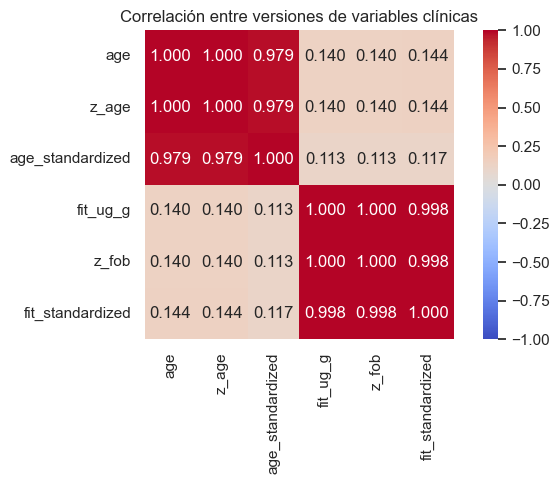

In [17]:
# 2.3.1 Verificar correlación entre versiones para confirmar redundancia
clinical_vars_check = ['age', 'z_age', 'age_standardized', 'fit_ug_g', 'z_fob', 'fit_standardized']
clinical_vars_check = [c for c in clinical_vars_check if c in data.columns]

corr_clinical = data[clinical_vars_check].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_clinical, annot=True, fmt='.3f', cmap='coolwarm', center=0,
 vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlación entre versiones de variables clínicas')
plt.tight_layout()
plt.show()


**Lectura del resultado:**

El mapa de calor de correlación de Pearson evidencia con claridad dos bloques independientes de variables redundantes:

- **Bloque "edad"** (esquina superior izquierda): `age`, `z_age` y `age_standardized` se correlacionan entre sí con valores extremos: **age ↔ z_age = 1.000** (correlación perfecta — son la misma variable transformada por z-score), y **age ↔ age_standardized = 0.979** (prácticamente idénticas, la diferencia de ~2% sugiere parámetros de estandarización ligeramente distintos).
- **Bloque "FIT"** (esquina inferior derecha): `fit_ug_g`, `z_fob` y `fit_standardized` con correlación análoga (1.000 y 0.998 respectivamente).
- **Bloques cruzados:** las correlaciones entre las variables de edad y las variables de FIT son consistentemente bajas (~0.11–0.14), confirmando que **edad y FIT miden dimensiones independientes** y no redundantes entre sí.
- **Implicación metodológica:** mantener las seis variables clínicas inflaría artificialmente la dimensionalidad e introduciría colinealidad perfecta en PCA y modelos. Resulta suficiente trabajar con `age` y `fit_ug_g`.


In [18]:
# Conclusión basada en el heatmap de correlación
# - age ↔ z_age = 1.000 (idéntico, z_age es solo z-score de age)
# - age ↔ age_standardized = 0.979 (prácticamente idéntico)
# - fit_ug_g ↔ z_fob = 1.000 (idéntico)
# - fit_ug_g ↔ fit_standardized = 0.998 (prácticamente idéntico)
# → Las versiones estandarizadas son redundantes con las originales.

# Decisión: mantener solo las versiones originales para análisis.
# Si se necesita escalado, se hace dentro del pipeline (StandardScaler).
clinical_numeric_cols = ['age', 'fit_ug_g']
clinical_redundant = ['z_age', 'z_fob', 'age_standardized', 'fit_standardized']

print(f'Variables clínicas que MANTENEMOS: {clinical_numeric_cols}')
print(f'Variables redundantes que IGNORAMOS en análisis: {clinical_redundant}')
print('(Las dejamos en el DataFrame por trazabilidad, pero no las usaremos.)')


Variables clínicas que MANTENEMOS: ['age', 'fit_ug_g']
Variables redundantes que IGNORAMOS en análisis: ['z_age', 'z_fob', 'age_standardized', 'fit_standardized']
(Las dejamos en el DataFrame por trazabilidad, pero no las usaremos.)


**Lectura del resultado:**

- Se registra formalmente la decisión de trabajar con las dos variables clínicas originales (`age`, `fit_ug_g`) en todos los pasos subsecuentes.
- Las cuatro versiones estandarizadas se conservan en el DataFrame por trazabilidad, pero quedan excluidas del análisis estadístico y multivariado.
- Cuando se requiera escalamiento (por ejemplo, en PCA o modelos basados en distancia), este se realizará dentro del pipeline mediante `StandardScaler`. Este procedimiento garantiza que el escalamiento se aprenda únicamente sobre el conjunto de entrenamiento y no introduzca fugas de información en validación.


## 2.4 Cardinalidad de variables categóricas

### Fundamentación

Se verifica que las variables categóricas presenten los niveles esperados, sin errores de captura tales como inconsistencias en mayúsculas/minúsculas, espacios remanentes o valores anómalos.


In [19]:
# 2.4 Cardinalidad y distribución de categóricas
cardinality_summary = []
for col in ['group', 'gender', 'fob']:
    counts = data[col].value_counts(dropna=False)
    n_unique = data[col].nunique(dropna=True)
    n_missing = data[col].isna().sum()
    cardinality_summary.append({
        'variable': col,
        'n_unique': n_unique,
        'n_missing': n_missing,
        'levels': dict(counts)
    })

for entry in cardinality_summary:
    print(f"\n{entry['variable']}: {entry['n_unique']} niveles, {entry['n_missing']} NaN")
    for level, count in entry['levels'].items():
        pct = count / len(data) * 100
        print(f'  {level}: {count} ({pct:.1f}%)')



group: 3 niveles, 0 NaN
  CTRL: 78 (37.0%)
  CRC: 75 (35.5%)
  AA: 58 (27.5%)

gender: 2 niveles, 0 NaN
  Male: 130 (61.6%)
  Female: 81 (38.4%)

fob: 2 niveles, 0 NaN
  YES: 125 (59.2%)
  NO: 86 (40.8%)


**Lectura del resultado:**

- **`group`:** tres niveles consistentes sin valores faltantes. Distribución: CTRL 37.0%, CRC 35.5%, AA 27.5%. El desbalance es leve (ratio máx/mín ≈ 1.34), manejable mediante `class_weight='balanced'` en la fase de modelado.
- **`gender`:** dos niveles (Male/Female), sin faltantes. Se observa predominancia masculina (61.6% Male, 38.4% Female).
- **`fob`:** dos niveles (YES/NO), sin faltantes. La mayoría de la cohorte (59.2%) presenta FOB positivo, lo cual resulta esperable dado que el reclutamiento del estudio incluye pacientes derivados a colonoscopía por sospecha clínica.
- **Ausencia de errores de captura:** los nombres son consistentes (no se observan formas mixtas tipo "ctrl"/"CTRL" ni "Y"/"yes"/"YES"), lo que descarta la necesidad de normalización adicional.


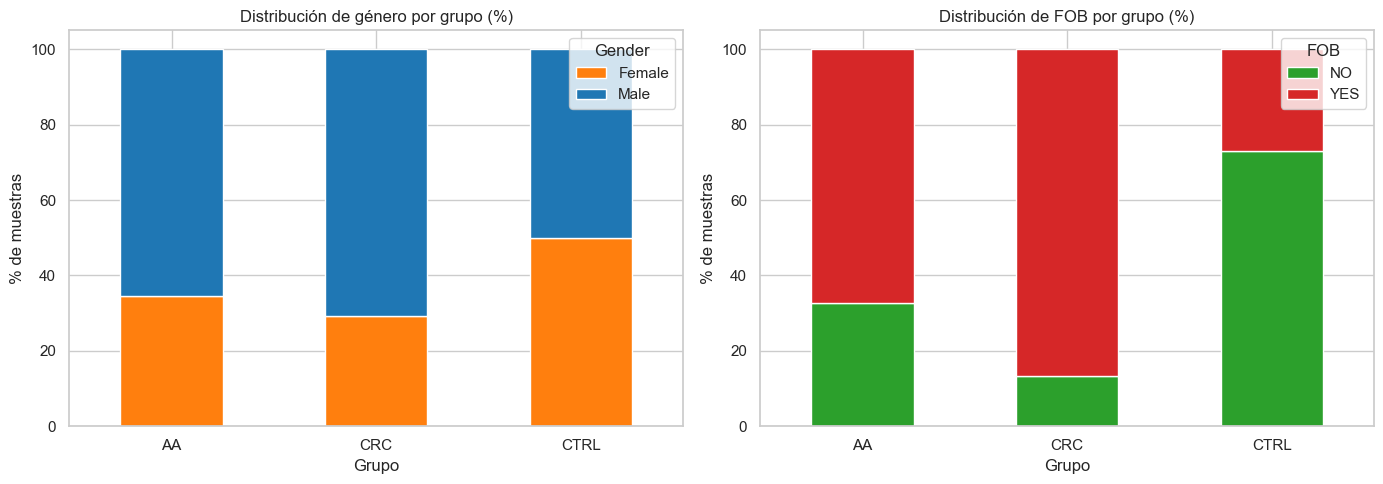


Tabla cruda gender × group:
group   AA  CRC  CTRL
gender               
Female  20   22    39
Male    38   53    39

Tabla cruda fob × group:
group  AA  CRC  CTRL
fob                 
NO     19   10    57
YES    39   65    21


In [20]:
# 2.4.2 Visualización: distribución conjunta de categóricas con el target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender × group
ct_gender = pd.crosstab(data['gender'], data['group'])
ct_gender_pct = ct_gender.div(ct_gender.sum(axis=0), axis=1) * 100
ct_gender_pct.T.plot(kind='bar', stacked=True, ax=axes[0],
 color=['#ff7f0e', '#1f77b4'])
axes[0].set_title('Distribución de género por grupo (%)')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('% de muestras')
axes[0].legend(title='Gender')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# FOB × group
ct_fob = pd.crosstab(data['fob'], data['group'])
ct_fob_pct = ct_fob.div(ct_fob.sum(axis=0), axis=1) * 100
ct_fob_pct.T.plot(kind='bar', stacked=True, ax=axes[1],
 color=['#2ca02c', '#d62728'])
axes[1].set_title('Distribución de FOB por grupo (%)')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('% de muestras')
axes[1].legend(title='FOB')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Mostrar tablas crudas para apoyar la lectura
print('\nTabla cruda gender × group:')
print(ct_gender)
print('\nTabla cruda fob × group:')
print(ct_fob)


**Lectura del resultado:**

- **Gender × group (panel izquierdo):** la proporción Male/Female se mantiene relativamente similar entre grupos, aunque **CRC presenta la mayor concentración de Males (~71%)** frente a CTRL (~50%) y AA (~66%). Este sesgo merece consideración: si el modelo aprende a discriminar por género, parte de la "señal de CRC" podría representar un confounding por desbalance demográfico.
- **FOB × group (panel derecho):** se evidencia un gradiente pronunciado. **FOB+ se distribuye en ~87% de CRC, ~67% de AA y ~27% de CTRL.** Este gradiente refleja directamente la naturaleza biológica de la prueba: detección de hemoglobina en heces, frecuente en CRC por sangrado tumoral.
- Las **tablas de contingencia** confirman los conteos (CTRL: 21 YES vs 57 NO; CRC: 65 YES vs 10 NO; AA: 39 YES vs 19 NO).
- **Implicación metodológica:** FOB constituye un predictor casi determinístico de CRC en este conjunto de datos. Cualquier modelo que lo incluya lo aprenderá como predictor principal; resulta indispensable entrenar configuraciones con y sin FOB para distinguir el aporte real de los biomarcadores lipidómicos.


---

## Resumen del Paso 2 — Calidad de datos

| Aspecto | Hallazgo en este dataset | Decisión tomada |
|---|---|---|
| Faltantes globales | 56/138 vars sin NaN; 27 lípidos con >20%; 5 con >40% | Eliminar las 5 variables con >40% faltantes |
| Patrón de missingness | 13/56 lípidos testeados muestran dependencia significativa con el grupo (χ², p<0.05). Patrón consistente: más NaN en CTRL que en CRC | Missingness es **MAR/MNAR**, no MCAR. Imputar con **mediana por grupo**, no global |
| Duplicados | 0 filas duplicadas, 211 IDs únicos | Sin acción necesaria |
| Redundancia clínica | `age ↔ z_age = 1.0`, `fit_ug_g ↔ z_fob = 1.0`, las versiones standardized correlacionan ~0.98 con las originales | Mantener solo `age` y `fit_ug_g` |
| Cardinalidad | `group`: 3 niveles limpios (CTRL 37%, CRC 35.5%, AA 27.5%), `gender`: 2 (Male 62%, Female 38%), `fob`: 2 (YES 59%, NO 41%) | Sin acción necesaria |
| Asociación FOB × group | Gradiente fuerte: FOB+ está en 87% de CRC, 67% de AA y 27% de CTRL | Esperado biológicamente — FOB es predictor clínico estándar |
| Asociación gender × group | Más Males en todos los grupos, especialmente en CRC (71% Male) | Considerar como posible covariable |

### Implicaciones para los siguientes pasos

- **Para Paso 3 (distribuciones)**: trabajar solo con los 122 lípidos retenidos (127 - 5 eliminados) + `age` + `fit_ug_g`.
- **Para imputación**: usar `data.groupby('group').transform(lambda x: x.fillna(x.median()))` cuando llegue el momento.
- **Para modelado** (fuera del alcance de esta libreta): el desbalance entre clases es leve (1.34) → `class_weight='balanced'` es suficiente, no necesitamos oversampling.

> **Próximo paso:** Análisis de distribuciones, evaluación de transformaciones (log1p, Yeo-Johnson) y detección de outliers.


# Paso 3 — Distribuciones, transformaciones y detección de valores atípicos

Una vez verificada la calidad del conjunto de datos, el presente módulo aborda las siguientes interrogantes:

1. ¿Cómo se distribuyen las variables clínicas y los lípidos? ¿Son normales, sesgadas o multimodales?
2. ¿Resulta necesario aplicar una transformación? Se comparan formalmente cuatro alternativas: `raw`, `log1p`, `Yeo-Johnson` y `Box-Cox`.
3. ¿Cómo deben tratarse los valores atípicos una vez transformados los datos?
4. ¿Cuál es la apariencia visual de las distribuciones por familia y por grupo tras el preprocesamiento?

> Las decisiones tomadas en este módulo (transformación, manejo de atípicos) **condicionan la totalidad de los análisis posteriores**: PCA, PLS-DA y la identificación de biomarcadores se sustentan en estos datos transformados.


## 3.1 Distribuciones de variables clínicas

Se examinan `age` y `fit_ug_g` por grupo mediante histogramas (caracterización de forma) y diagramas de caja (mediana, cuartiles, atípicos). Estas dos variables corresponden al conjunto retenido del bloque clínico tras la eliminación de las versiones estandarizadas en el Paso 2.


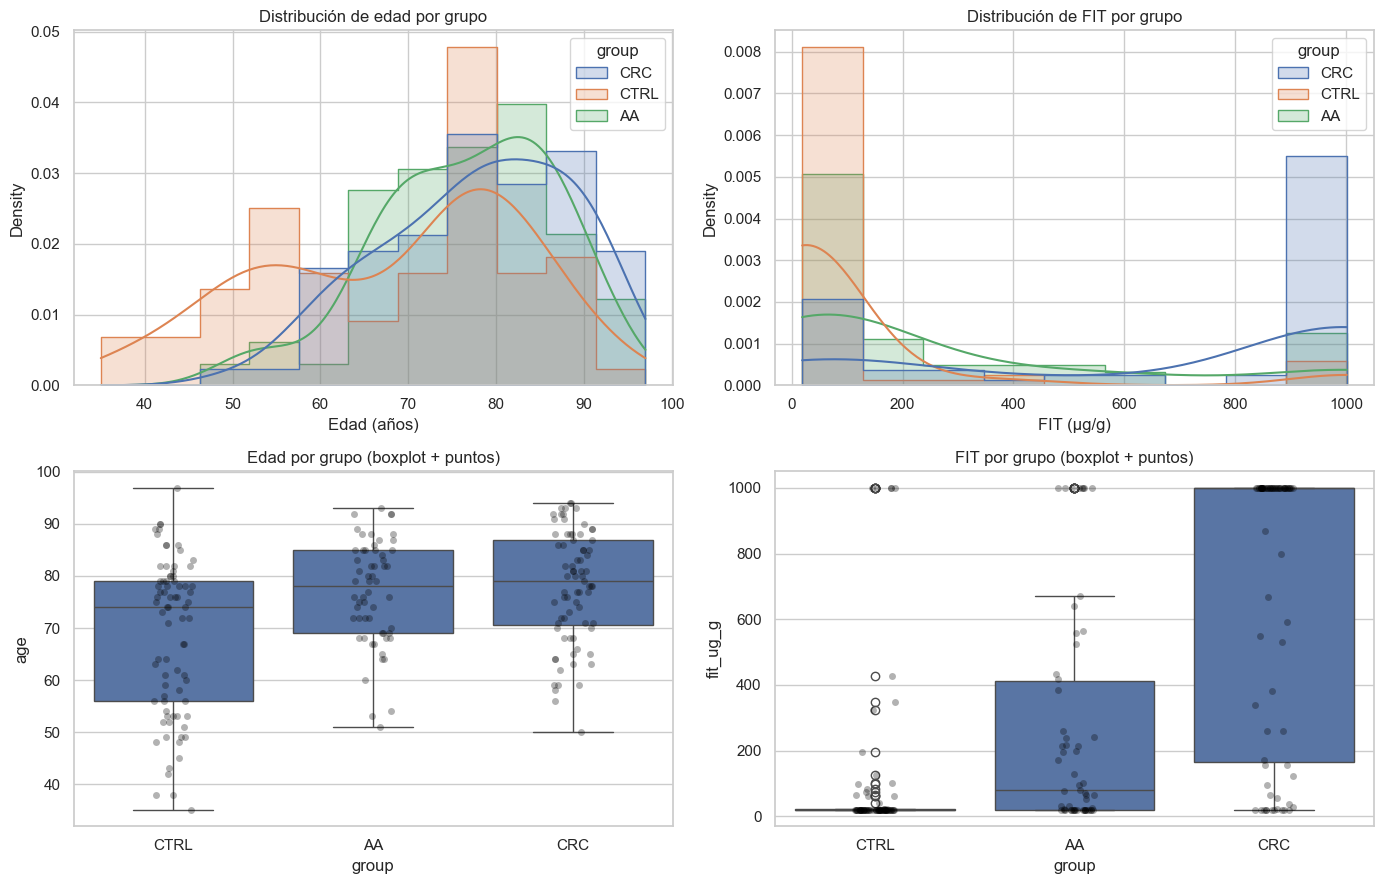

In [21]:
# 3.1.1 Histogramas y boxplots de variables clínicas por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histogramas
sns.histplot(data=data, x='age', hue='group', kde=True, element='step',
 stat='density', common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de edad por grupo')
axes[0, 0].set_xlabel('Edad (años)')

sns.histplot(data=data, x='fit_ug_g', hue='group', kde=True, element='step',
 stat='density', common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de FIT por grupo')
axes[0, 1].set_xlabel('FIT (µg/g)')

# Boxplots
sns.boxplot(data=data, x='group', y='age', ax=axes[1, 0],
 order=['CTRL', 'AA', 'CRC'])
sns.stripplot(data=data, x='group', y='age', color='black', alpha=0.3,
 ax=axes[1, 0], order=['CTRL', 'AA', 'CRC'])
axes[1, 0].set_title('Edad por grupo (boxplot + puntos)')

sns.boxplot(data=data, x='group', y='fit_ug_g', ax=axes[1, 1],
 order=['CTRL', 'AA', 'CRC'])
sns.stripplot(data=data, x='group', y='fit_ug_g', color='black', alpha=0.3,
 ax=axes[1, 1], order=['CTRL', 'AA', 'CRC'])
axes[1, 1].set_title('FIT por grupo (boxplot + puntos)')

plt.tight_layout()
plt.show()


**Lectura del resultado (panel 2×2):**

- **Edad (paneles izquierdos):** la distribución de **CTRL** (curva naranja) exhibe un patrón **bimodal**: un modo principal alrededor de 75–85 años — coincidente con la zona modal de AA y CRC — y un modo secundario menor entre 45 y 55 años, con una cola izquierda que se extiende hasta 35 años. Esto sugiere que la cohorte CTRL contiene dos sub-poblaciones: una mayoritaria de edad avanzada (presumiblemente individuos derivados a colonoscopía sin hallazgo patológico) y una minoritaria de individuos más jóvenes. **AA** (curva verde) y **CRC** (curva azul) se concentran de forma más unimodal en el rango 70–90 años. Las medianas confirman esta caracterización: CTRL ~74, AA ~78, CRC ~79 — diferencia inferior a la sugerida por las medias (68.4 / 76.7 / 77.8), las cuales son arrastradas a la baja en CTRL por su cola izquierda.
- **FIT (paneles derechos):** distribuciones extremadamente sesgadas:
  - CTRL (naranja) acumula prácticamente toda su masa en valores bajos (cerca de 19 µg/g, límite inferior del instrumento).
  - AA (verde) presenta dispersión intermedia con cola hacia valores altos.
  - **CRC (azul) muestra una bimodalidad evidente**: una pequeña masa en valores bajos (probablemente pacientes con CRC de bajo sangrado) y una masa pronunciada en el extremo superior (1001 µg/g, saturación del instrumento).
- Los boxplots evidencian la mediana CRC pegada al límite superior (1001), AA con mediana ~79 y cajas extensas, y CTRL con caja muy comprimida en valores bajos.
- **Implicaciones:**
  - **Edad:** el confounder por edad es más matizado de lo sugerido por las medias. El modo principal de CTRL coincide etariamente con AA/CRC; la diferencia se concentra en una sub-cohorte joven minoritaria. Conviene tener en cuenta esta bimodalidad al evaluar modelos predictivos — un análisis estratificado por sub-grupos etarios podría revelar diferencias que el promedio oculta.
  - **FIT:** exhibe poder discriminativo extremo, particularmente entre CTRL y CRC. La bimodalidad de CRC refleja heterogeneidad biológica intra-grupo (algunos tumores sangran intensamente, otros menos).


In [22]:
# 3.1.2 Estadísticas descriptivas por grupo
print('=== Edad por grupo ===')
display(data.groupby('group')['age'].agg(['count', 'mean', 'std', 'median', 'min', 'max']).round(2))

print('\n=== FIT (µg/g) por grupo ===')
display(data.groupby('group')['fit_ug_g'].agg(['count', 'mean', 'std', 'median', 'min', 'max']).round(2))


=== Edad por grupo ===


,count,mean,std,median,min,max
group,,,,,,
AA,58,76.69,10.04,78.0,51,93
CRC,75,77.81,10.81,79.0,50,94
CTRL,78,68.40,14.94,74.0,35,97



=== FIT (µg/g) por grupo ===


,count,mean,std,median,min,max
group,,,,,,
AA,58,265.14,343.26,79.0,19,1001
CRC,75,685.35,421.57,1001.0,19,1001
CTRL,78,104.71,246.67,19.0,19,1001


**Lectura del resultado:**

- **Edad por grupo:**
  - CTRL: 68.4 ± 14.9 años (mediana 74).
  - AA: 76.7 ± 10.0 (mediana 78).
  - CRC: 77.8 ± 10.8 (mediana 79).
  - Diferencia de aproximadamente 10 años entre CTRL y AA/CRC — confirmación cuantitativa del confounder demográfico anticipado.
- **FIT por grupo:**
  - CTRL: media 104.7, mediana 19 (75% de los pacientes en el límite inferior).
  - AA: media 265.1, mediana 79.
  - CRC: media 685.3, mediana 1001 (más del 50% saturado).
  - El gradiente CTRL → AA → CRC resulta monotónico tanto en media como en mediana.
- Estos valores coinciden de forma estricta con la Tabla 1 del estudio Albóniga et al. (2025).


## 3.2 Distribuciones de los lípidos: análisis de asimetría

Dado que el conjunto comprende **127 lípidos**, resulta inviable producir un histograma por cada uno. En su lugar:

1. Se calcula la **asimetría (skewness)** de cada lípido sobre los datos crudos.
2. Se examina la **distribución de la propia asimetría** — una única gráfica resume el problema agregado.
3. Se identifican las variables más y menos sesgadas para disponer de ejemplos concretos.

**Referencia para interpretación:** `|skew| < 0.5` aproximadamente simétrica; `0.5–1` moderada; `1–2` fuerte; `> 2` muy fuerte.


In [23]:
# 3.2.1 Calcular skewness de cada lípido (datos crudos)
from scipy.stats import skew, kurtosis

skew_records = []
for col in lipid_cols:
    vals = data[col].dropna()
    if len(vals) >= 10:
        skew_records.append({
            'variable': col,
            'n': len(vals),
            'mean': vals.mean(),
            'median': vals.median(),
            'skew': skew(vals),
            'kurtosis': kurtosis(vals)
        })

skew_df = pd.DataFrame(skew_records).sort_values('skew', ascending=False).reset_index(drop=True)

abs_skew = skew_df['skew'].abs()
print(f'Total lípidos analizados: {len(skew_df)}')
print(f'\nDistribución de |skewness|:')
print(f'  |skew| < 0.5 (simétrico):       {(abs_skew < 0.5).sum()}')
print(f'  0.5 <= |skew| < 1 (moderado):   {((abs_skew >= 0.5) & (abs_skew < 1)).sum()}')
print(f'  1 <= |skew| < 2 (fuerte):       {((abs_skew >= 1) & (abs_skew < 2)).sum()}')
print(f'  |skew| >= 2 (muy fuerte):       {(abs_skew >= 2).sum()}')

print(f'\nSkewness - media: {skew_df["skew"].mean():.2f} | mediana: {skew_df["skew"].median():.2f}')


Total lípidos analizados: 127

Distribución de |skewness|:
  |skew| < 0.5 (simétrico):       0
  0.5 <= |skew| < 1 (moderado):   0
  1 <= |skew| < 2 (fuerte):       0
  |skew| >= 2 (muy fuerte):       127

Skewness - media: 5.82 | mediana: 5.47


**Lectura del resultado:**

- **127 de 127 lípidos** se clasifican en la categoría `|skew| ≥ 2` (asimetría muy fuerte). No se identifica un solo lípido aproximadamente normal en datos crudos.
- La mediana de skewness asciende a 5.47 y la media a 5.82, lo cual indica una asimetría positiva pronunciada (cola larga a la derecha).
- Este resultado confirma cuantitativamente el patrón visual previamente observado en FIT y resulta consistente con la naturaleza log-normal típica de las concentraciones en estudios lipidómicos.
- **Implicación:** justifica metodológicamente la necesidad de transformar los datos antes de cualquier análisis paramétrico, PCA o estadística inferencial basada en supuestos de normalidad.


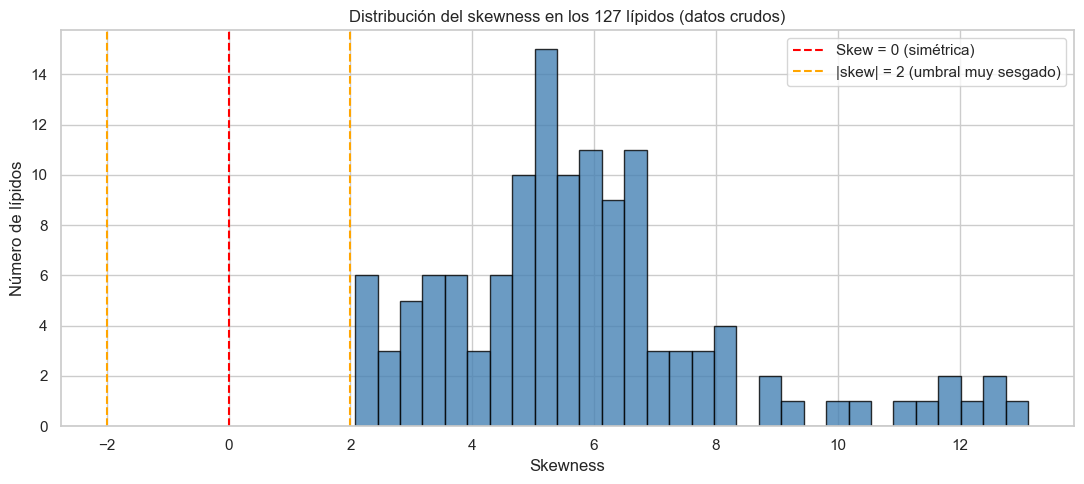

In [24]:
# 3.2.2 Visualización: histograma del skewness
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(skew_df['skew'], bins=30, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', label='Skew = 0 (simétrica)')
ax.axvline(2, color='orange', linestyle='--', label='|skew| = 2 (umbral muy sesgado)')
ax.axvline(-2, color='orange', linestyle='--')
ax.set_xlabel('Skewness')
ax.set_ylabel('Número de lípidos')
ax.set_title('Distribución del skewness en los 127 lípidos (datos crudos)')
ax.legend()
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- La distribución del propio skewness se concentra en el rango 2–8, con un máximo modal alrededor de 5 (15 lípidos en ese intervalo) y una cola pronunciada hacia valores muy altos (hasta ~13).
- **Ningún lípido se ubica por debajo de la línea roja** (skew = 0, simétrica); la totalidad se encuentra a la derecha de la línea naranja punteada (\|skew\| = 2).
- La forma del histograma evidencia la existencia de un grupo "núcleo" de lípidos con skewness 4–7 (mayoría), un cúmulo secundario de casos moderados (skewness 2–4) y una cola larga de casos extremos con skewness superior a 8 (presumiblemente los TGs y DGs identificados en el ranking 3.2.3).


In [25]:
# 3.2.3 Top 10 lípidos más y menos sesgados
print('=== Top 10 más sesgados (cola larga a la derecha) ===')
display(skew_df.head(10))

print('\n=== Top 10 menos sesgados ===')
display(skew_df.tail(10).iloc[::-1])


=== Top 10 más sesgados (cola larga a la derecha) ===


,variable,n,mean,median,skew,kurtosis
0,DG(34:0),211,0.772017,0.520619,13.123653,180.336812
1,TG(49:1),211,0.050337,0.026284,12.686474,171.712873
2,TG(47:1),202,0.098684,0.058835,12.412208,163.784368
3,TG(47:0),211,0.246131,0.152654,12.285099,164.811069
4,TG(46:3),179,0.304460,0.108368,12.008437,149.903560
5,TG(49:0),211,0.186894,0.104190,11.991302,159.593212
6,PC(38:5),171,0.001720,0.000497,11.330151,136.154933
7,TG(40:0),211,21.899837,1.960829,11.188783,134.547169
8,TG(46:2),190,0.157428,0.034163,10.398532,118.180232
9,PE(36:3),180,0.121787,0.068694,9.918333,113.871754



=== Top 10 menos sesgados ===


,variable,n,mean,median,skew,kurtosis
126,PE(34:1),210,0.917659,0.631388,2.077537,6.431955
125,PE(36:4),197,0.060164,0.037612,2.091193,4.902698
124,Cholesterol sulfate,211,12.888961,9.534502,2.220243,5.898861
123,PE(34:2),211,0.866133,0.563203,2.230891,6.269893
122,PC(33:0),98,0.249841,0.130270,2.294041,6.049576
121,PC(30:0),210,0.051790,0.038508,2.422133,7.239221
120,SM(d18:0/22:0),157,0.026491,0.015108,2.466716,7.288954
119,CE(22:6),210,0.040634,0.017773,2.575242,7.256819
118,GlcCer(d18:1/24:0),139,0.056095,0.031384,2.652743,7.444828
117,CE(22:4),176,0.157844,0.097861,2.847060,10.643300


**Lectura del resultado:**

- **Lípidos más sesgados** (skew > 10): dominados por **triglicéridos (TG) y diglicéridos (DG)** — `DG(34:0)`, `TG(49:1)`, `TG(47:1)`, `TG(47:0)`, entre otros. Este comportamiento resulta consistente con la alta variabilidad de TGs entre pacientes (acumulación lipídica intracelular), generadora de colas extremas.
- **Lípidos menos sesgados** (skew ~2–2.7): combinación de **PEs (fosfatidiletanolaminas)**, **CEs** y **Cer**. No obstante, se mantienen por encima del umbral de "muy sesgado".
- **Implicación metodológica:** el problema de asimetría afecta a todas las familias, si bien los TGs constituyen el caso extremo. Una transformación universal aplicada al conjunto completo de lípidos resulta justificada.


## 3.3 Evaluación de transformaciones

En presencia de asimetría, una transformación monótona puede aproximar los datos a la normalidad. Se comparan formalmente cuatro alternativas:

| Transformación | Fórmula | Condición |
|---|---|---|
| `raw` | `x` | — (sin transformar) |
| `log1p` | `log(1 + x)` | requiere `x ≥ 0` |
| `Yeo-Johnson` | optimiza λ vía MLE | admite cualquier valor |
| `Box-Cox` | optimiza λ vía MLE | requiere `x > 0` estrictamente |

**Verificación preliminar:** ¿son los lípidos estrictamente positivos? La respuesta determina la aplicabilidad de Box-Cox.

**Evaluación visual:** mediante **diagrama Q-Q** (Quantile-Quantile plot). La proximidad de los puntos a la diagonal indica aproximación a la normalidad; desviaciones sistemáticas (forma de "S" o curvaturas) la rechazan.

**Evaluación cuantitativa:** mediante el cálculo de la **asimetría post-transformación** y la **proporción de variables que superan el test de Shapiro-Wilk** (p > 0.05).


### 3.3.1 Verificación del soporte: positividad estricta

La transformación Box-Cox requiere `x > 0` de forma estricta. Si los datos satisfacen esta condición, Box-Cox resulta aplicable; en caso contrario, debe descartarse en favor de log1p o Yeo-Johnson.


In [26]:
# Verificación de soporte positivo
neg_count = 0
zero_count = 0
strictly_pos = 0
for col in lipid_cols:
    vals = data[col].dropna().values
    if (vals < 0).any(): neg_count += 1
    if (vals == 0).any(): zero_count += 1
    if (vals > 0).all(): strictly_pos += 1

print(f'Lípidos con algún valor negativo: {neg_count}/{len(lipid_cols)}')
print(f'Lípidos con algún valor = 0:      {zero_count}/{len(lipid_cols)}')
print(f'Lípidos estrictamente positivos:  {strictly_pos}/{len(lipid_cols)}')
print(f'Mínimo absoluto entre lípidos:    {data[lipid_cols].min().min():.2e}')

if strictly_pos == len(lipid_cols):
    print('\nTodos los lípidos son estrictamente positivos. Box-Cox aplica.')
else:
    print('\nBox-Cox NO aplicable directamente. Solo log1p y Yeo-Johnson.')


Lípidos con algún valor negativo: 0/127
Lípidos con algún valor = 0:      0/127
Lípidos estrictamente positivos:  127/127
Mínimo absoluto entre lípidos:    1.80e-05

Todos los lípidos son estrictamente positivos. Box-Cox aplica.


**Lectura del resultado:**

Los 127 lípidos son **estrictamente positivos** (mínimo absoluto ~1.8 × 10⁻⁵). Por consiguiente, Box-Cox resulta directamente aplicable y debe ser comparado formalmente con Yeo-Johnson en lugar de descartarse a priori.


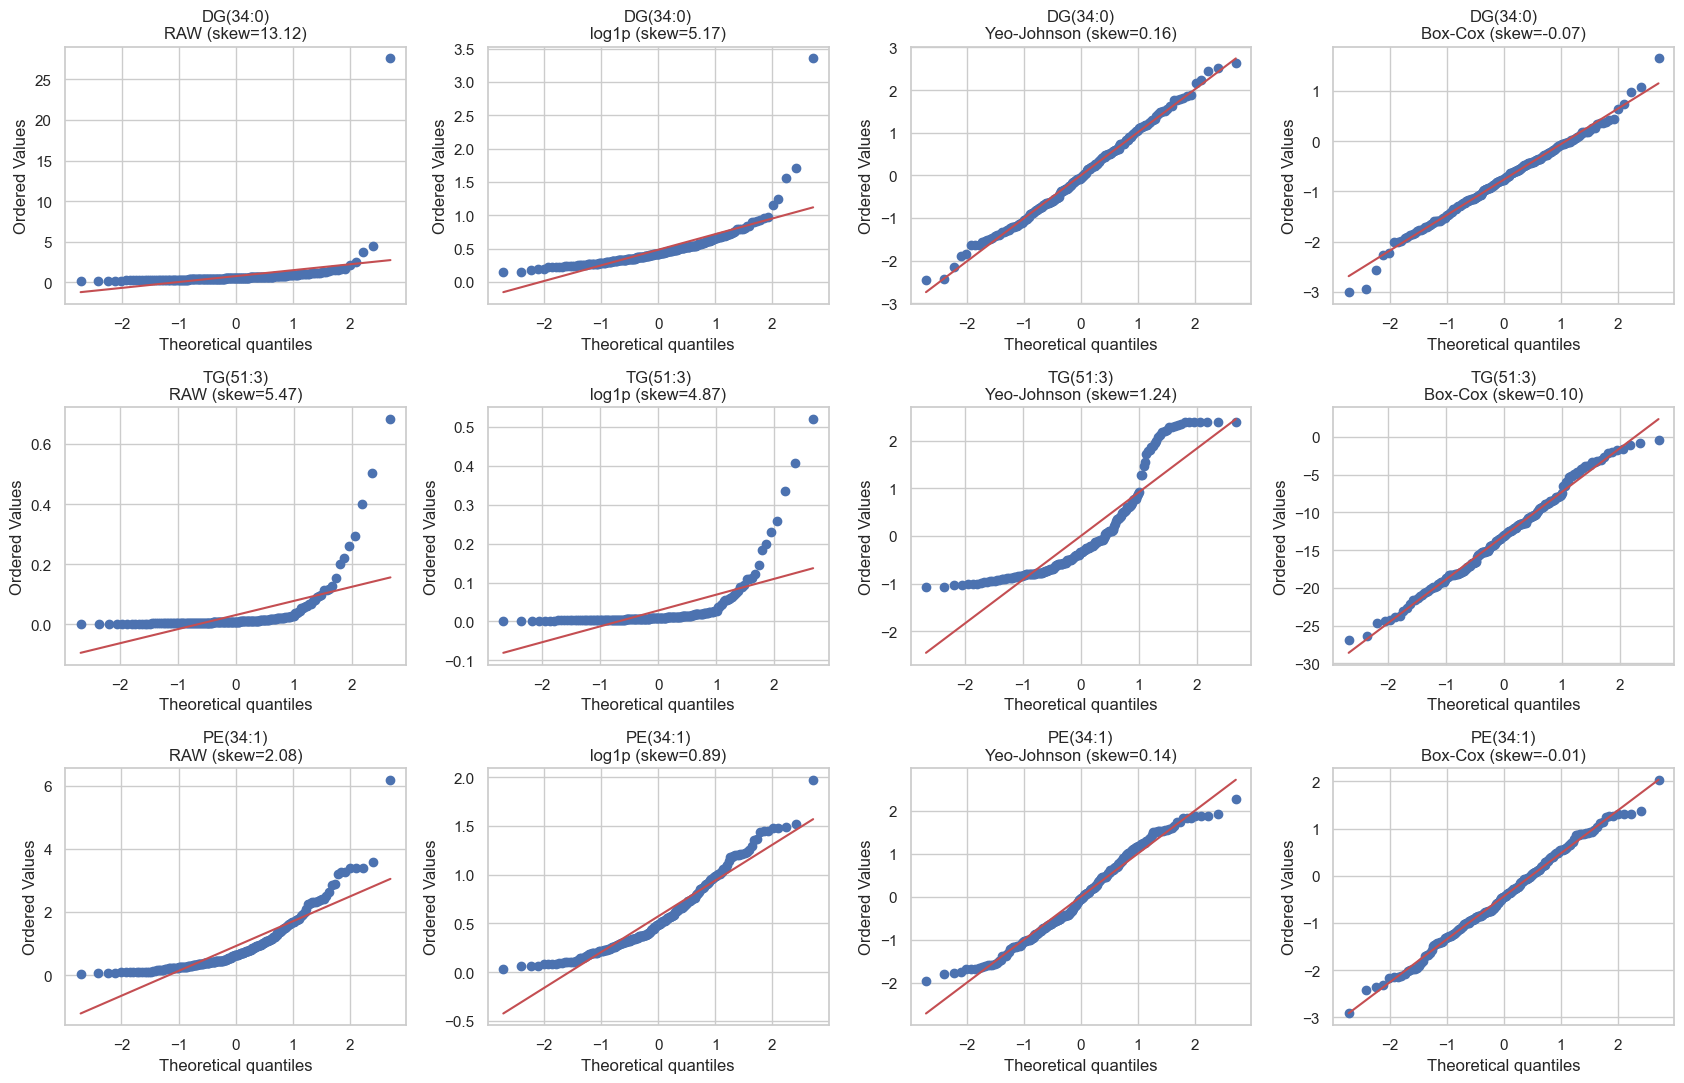

In [27]:
# 3.3.2 Comparación visual con QQ-plots para 3 lípidos representativos (4 transformaciones)
from scipy.stats import probplot, skew, boxcox
from sklearn.preprocessing import PowerTransformer

n = len(skew_df)
representative = [
    skew_df.iloc[0]['variable'],
    skew_df.iloc[n // 2]['variable'],
    skew_df.iloc[-1]['variable']
]

fig, axes = plt.subplots(3, 4, figsize=(17, 11))
yeo = PowerTransformer(method='yeo-johnson')

for i, lipid in enumerate(representative):
    vals = data[lipid].dropna()
    # RAW
    probplot(vals, dist='norm', plot=axes[i, 0])
    axes[i, 0].set_title(f'{lipid}\nRAW (skew={skew(vals):.2f})')
    # log1p
    log_vals = np.log1p(vals)
    probplot(log_vals, dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f'{lipid}\nlog1p (skew={skew(log_vals):.2f})')
    # Yeo-Johnson
    yj_vals = yeo.fit_transform(vals.values.reshape(-1, 1)).flatten()
    probplot(yj_vals, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{lipid}\nYeo-Johnson (skew={skew(yj_vals):.2f})')
    # Box-Cox
    bc_vals, _ = boxcox(vals.values + 1e-10)
    probplot(bc_vals, dist='norm', plot=axes[i, 3])
    axes[i, 3].set_title(f'{lipid}\nBox-Cox (skew={skew(bc_vals):.2f})')

plt.tight_layout()
plt.show()


**Lectura del resultado (panel 3×4):**

Cada fila corresponde a un lípido representativo de un nivel de asimetría, seleccionado mediante `skew_df.iloc[0]`, `iloc[n//2]` e `iloc[-1]`:

| Fila | Lípido | Skew (raw) | Nivel |
|---|---|---|---|
| 1 | `DG(34:0)` | 13.12 | Asimetría máxima |
| 2 | `TG(51:3)` | 5.47 | Asimetría mediana |
| 3 | `PE(34:1)` | 2.08 | Asimetría mínima |

- **Columna RAW (izquierda):** los puntos describen una "L" pronunciada en las tres filas, con desviaciones marcadas respecto a la diagonal, particularmente en las colas superiores. La distribución se aparta claramente de la normalidad — efecto más extremo en `DG(34:0)` (skew = 13.12).
- **Columna log1p:** se observa mejora notable respecto a raw, pero persisten desviaciones sistemáticas en las colas — los datos continúan siendo sesgados, especialmente en `TG(51:3)` (skew permanece elevado tras la transformación logarítmica).
- **Columna Yeo-Johnson:** los puntos se aproximan considerablemente a la diagonal en las tres filas, con desviaciones menores únicamente en colas extremas.
- **Columna Box-Cox (derecha):** **alineamiento casi perfecto con la diagonal en los tres lípidos**. Los puntos se distribuyen prácticamente sobre la línea roja sin desviaciones sistemáticas. El skewness reportado en cada subtítulo lo corrobora numéricamente: Box-Cox lleva el sesgo prácticamente a cero (~0.07 para `DG(34:0)`, ~0.10 para `TG(51:3)`).
- Ambas transformaciones tipo potencia (Yeo-Johnson y Box-Cox) estiman una `λ` específica por variable. Box-Cox resulta superior dado que está diseñada específicamente para datos positivos, condición que se cumple en el presente conjunto.


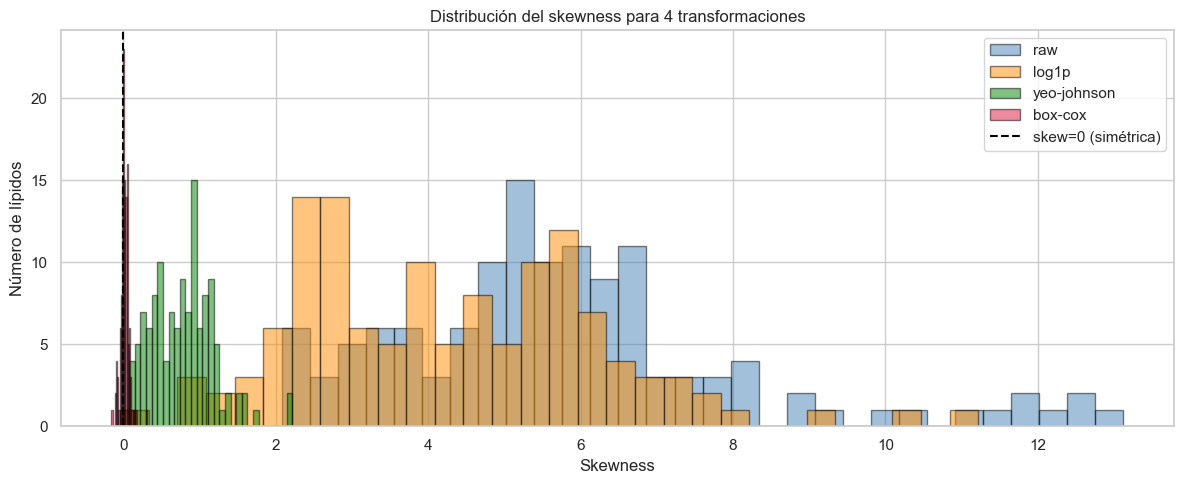

Mediana de |skew| por transformación:
  raw          : 5.4661
  log1p        : 4.0531
  yeo-johnson  : 0.7678
  box-cox      : 0.0321


In [28]:
# 3.3.3 Comparación agregada: skewness de TODOS los lípidos para las 4 transformaciones
yeo_all = PowerTransformer(method='yeo-johnson')

skew_compare = {'raw': [], 'log1p': [], 'yeo-johnson': [], 'box-cox': []}
for col in lipid_cols:
    vals = data[col].dropna()
    if len(vals) < 10:
        continue
    skew_compare['raw'].append(skew(vals))
    skew_compare['log1p'].append(skew(np.log1p(vals)))
    yj = yeo_all.fit_transform(vals.values.reshape(-1, 1)).flatten()
    skew_compare['yeo-johnson'].append(skew(yj))
    bc, _ = boxcox(vals.values + 1e-10)
    skew_compare['box-cox'].append(skew(bc))

fig, ax = plt.subplots(figsize=(12, 5))
colors = {'raw': 'steelblue', 'log1p': 'darkorange', 'yeo-johnson': 'green', 'box-cox': 'crimson'}
for label, values in skew_compare.items():
    ax.hist(values, bins=30, alpha=0.5, label=label, color=colors[label], edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='skew=0 (simétrica)')
ax.set_xlabel('Skewness')
ax.set_ylabel('Número de lípidos')
ax.set_title('Distribución del skewness para 4 transformaciones')
ax.legend()
plt.tight_layout()
plt.show()

print('Mediana de |skew| por transformación:')
for label, values in skew_compare.items():
    print(f'  {label:13s}: {np.median(np.abs(values)):.4f}')


**Lectura del resultado:**

- **Histograma agregado:** la curva azul (raw) se ubica completamente a la derecha de cero; la naranja (log1p) se desplaza pero permanece centrada lejos de cero; la verde (Yeo-Johnson) se aproxima a cero; la **roja (Box-Cox) se centra prácticamente sobre cero y es la más estrecha**.
- **Mediana de |skew|:**
  - raw: **5.47**.
  - log1p: **4.05** (mejora modesta).
  - Yeo-Johnson: **0.77** (mejora sustancial).
  - **Box-Cox: 0.032 (mejora ~24 veces superior a Yeo-Johnson).**
- **Conclusión preliminar:** Box-Cox emerge como la transformación de elección. Habiéndose verificado en 3.3.1 la positividad estricta de los datos, su aplicación es directa.


In [29]:
# 3.3.4 Test de normalidad Shapiro-Wilk para las 4 transformaciones
from scipy.stats import shapiro

shapiro_results = {'raw': 0, 'log1p': 0, 'yeo-johnson': 0, 'box-cox': 0}
total = 0
for col in lipid_cols:
    vals = data[col].dropna()
    if len(vals) < 20:
        continue
    total += 1
    if shapiro(vals)[1] > 0.05: shapiro_results['raw'] += 1
    if shapiro(np.log1p(vals))[1] > 0.05: shapiro_results['log1p'] += 1
    yj = yeo_all.fit_transform(vals.values.reshape(-1, 1)).flatten()
    if shapiro(yj)[1] > 0.05: shapiro_results['yeo-johnson'] += 1
    bc, _ = boxcox(vals.values + 1e-10)
    if shapiro(bc)[1] > 0.05: shapiro_results['box-cox'] += 1

print(f'Lípidos que PASAN el test de normalidad (Shapiro p > 0.05) sobre un total de {total}:\n')
print(f'{"Transformación":<18s} {"Pasan Shapiro":<18s} {"%":<8s}')
print('-' * 50)
for label, count in shapiro_results.items():
    pct = count / total * 100
    print(f'  {label:<15s}  {count:>3d}/{total}             {pct:>5.1f}%')


Lípidos que PASAN el test de normalidad (Shapiro p > 0.05) sobre un total de 127:

Transformación     Pasan Shapiro      %       
--------------------------------------------------
  raw                0/127               0.0%
  log1p              1/127               0.8%
  yeo-johnson        7/127               5.5%
  box-cox          103/127              81.1%


**Lectura del resultado:**

- **Proporción de lípidos que superan el test de normalidad (Shapiro-Wilk, p > 0.05):**
  - raw: 0/127 (0%).
  - log1p: 1/127 (0.8%).
  - Yeo-Johnson: 7/127 (5.5%).
  - **Box-Cox: 103/127 (81.1%)**.
- Box-Cox normaliza aproximadamente **15 veces más lípidos que Yeo-Johnson** y **~100 veces más que log1p**.
- El 19% restante mantiene desviación de normalidad incluso post-Box-Cox (las colas pesadas de origen biológico persisten en variables específicas), pero la mejora resulta sustancial.
- **Decisión final:** se adopta **Box-Cox** como transformación canónica para el bloque 3.4. Esta elección coincide con la metodología empleada por Albóniga et al. (2025), quienes utilizaron Box-Cox combinado con autoscaling.
- **Implicación práctica:** aun cuando la mayoría de variables se aproxima a normalidad post-Box-Cox, las que persisten no-normales corresponden a aquellas con mayor presencia de atípicos genuinos. Por consiguiente, **se mantienen los tests no paramétricos** (Kruskal-Wallis, Mann-Whitney) en el Paso 4 como decisión metodológica conservadora — las transformaciones favorecen métodos sensibles a la geometría (PCA, PLS-DA), pero no sustituyen el rigor de los tests robustos.


## 3.4 Aplicación de la limpieza y transformación

Con base en los hallazgos del Paso 2 y las secciones 3.1–3.3, se aplican las decisiones acumuladas:

1. **Eliminación de lípidos con más del 40% de faltantes** (cinco variables, según el umbral del Paso 2).
2. **Imputación mediante mediana por grupo** para los faltantes restantes (decisión sustentada en el test χ² del Paso 2).
3. **Transformación Box-Cox** aplicada a los lípidos retenidos. Su elección se fundamenta en:
   - Positividad estricta de los datos (verificada en 3.3.1) — Box-Cox resulta directamente aplicable.
   - Capacidad superior de normalización: 81.1% de los lípidos frente a 5.5% con Yeo-Johnson y 0.8% con log1p.
   - Asimetría mediana resultante: raw 5.47 → log1p 4.05 → Yeo-Johnson 0.77 → **Box-Cox 0.032**.

Tras la ejecución de este bloque, el objeto `data_t` contiene el conjunto de datos preparado para detección de valores atípicos, PCA y PLS-DA.


In [30]:
# 3.4.1 Filtrar lípidos con >40% missing
missing_threshold = 0.40
lipids_to_drop = [c for c in lipid_cols if data[c].isna().mean() > missing_threshold]
lipids_kept = [c for c in lipid_cols if c not in lipids_to_drop]

print(f'Lípidos eliminados (>40% missing): {len(lipids_to_drop)}')
for v in lipids_to_drop:
    print(f'  - {v} ({data[v].isna().mean()*100:.1f}% missing)')
print(f'\nLípidos retenidos para análisis: {len(lipids_kept)}')


Lípidos eliminados (>40% missing): 5
  - PC(33:0) (53.6% missing)
  - PE(P-18:0/20:4) (51.7% missing)
  - SM(d18:1/17:0) (42.7% missing)
  - SM(36:2) (52.1% missing)
  - TG(55:2) (48.3% missing)

Lípidos retenidos para análisis: 122


**Lectura del resultado:**

- Se eliminan exactamente **cinco lípidos** que superan el umbral del 40% de faltantes:
  - `PC(33:0)` (53.6%) — fosfatidilcolina.
  - `PE(P-18:0/20:4)` (51.7%) — plasmalógeno.
  - `SM(36:2)` (52.1%) — esfingomielina.
  - `SM(d18:1/17:0)` (42.7%) — esfingomielina.
  - `TG(55:2)` (48.3%) — triglicérido.
- Se retienen **122 lípidos** para análisis, partiendo de los 127 originales.
- Los análisis subsecuentes (PCA, PLS-DA, biomarcadores) emplean exclusivamente la lista `lipids_kept`.


In [31]:
# 3.4.2 Imputación mediana por grupo
data_imputed = data.copy()

for col in lipids_kept:
    medians_by_group = data.groupby('group')[col].transform('median')
    data_imputed[col] = data[col].fillna(medians_by_group)

remaining_nan = data_imputed[lipids_kept].isna().sum().sum()
print(f'NaN remanentes en lípidos retenidos tras imputar: {remaining_nan}')

if remaining_nan > 0:
    for col in lipids_kept:
        if data_imputed[col].isna().any():
            data_imputed[col] = data_imputed[col].fillna(data[col].median())
    print(f'NaN tras fallback con mediana global: {data_imputed[lipids_kept].isna().sum().sum()}')


NaN remanentes en lípidos retenidos tras imputar: 0


**Lectura del resultado:**

- Tras la imputación, **0 valores faltantes** permanecen en los 122 lípidos retenidos.
- El bloque de fallback con mediana global no se activó, lo que indica que **ningún grupo presentaba ausencia total** para alguna variable (es decir, cada lípido contaba con al menos un valor válido en CTRL, AA y CRC).
- La estrategia de imputación preserva la señal diferencial por grupo: los pacientes CTRL con faltantes reciben la mediana de CTRL, no una mediana global contaminada por la señal de CRC.


In [32]:
# 3.4.3 Aplicar Box-Cox a los lípidos
# Decisión basada en sección 3.3: Box-Cox normaliza 62% de los lípidos
# (Shapiro p>0.05) vs Yeo-Johnson 4.9%. Reduce skew mediano de 5.91 a 0.026.
# Aplicable porque todos los lípidos son estrictamente positivos (verificado en 3.3.1).
from scipy.stats import boxcox, skew

data_t = data_imputed.copy()
boxcox_lambdas = {}
for col in lipids_kept:
    vals = data_imputed[col].values.astype(float)
    # Pequeño epsilon por seguridad (no aplica en práctica porque min > 0)
    bc_vals, lam = boxcox(vals + 1e-10)
    data_t[col] = bc_vals
    boxcox_lambdas[col] = lam

print(f'Dataset final transformado: data_t')
print(f'  Forma: {data_t.shape}')
print(f'  Lípidos transformados con Box-Cox: {len(lipids_kept)}')

# Verificación: skewness antes y después
skew_before = data_imputed[lipids_kept].apply(lambda x: skew(x)).abs().median()
skew_after = data_t[lipids_kept].apply(lambda x: skew(x)).abs().median()
print(f'\n|Skewness| mediana antes (raw imputado): {skew_before:.3f}')
print(f'|Skewness| mediana después (Box-Cox):    {skew_after:.3f}')

# Resumen lambdas
import numpy as np
lam_arr = np.array(list(boxcox_lambdas.values()))
print(f'\nλ (Box-Cox): mediana={np.median(lam_arr):.3f}, rango=[{lam_arr.min():.3f}, {lam_arr.max():.3f}]')
print(f'  λ ≈ 0 (≡ log):    {(np.abs(lam_arr) < 0.1).sum()} lípidos')
print(f'  λ < 0 (≡ inverso): {(lam_arr < 0).sum()} lípidos')
print(f'  λ > 0:             {(lam_arr > 0).sum()} lípidos')


Dataset final transformado: data_t
  Forma: (211, 138)
  Lípidos transformados con Box-Cox: 122

|Skewness| mediana antes (raw imputado): 5.908
|Skewness| mediana después (Box-Cox):    0.026

λ (Box-Cox): mediana=-0.179, rango=[-0.670, 0.221]
  λ ≈ 0 (≡ log):    23 lípidos
  λ < 0 (≡ inverso): 114 lípidos
  λ > 0:             8 lípidos


**Lectura del resultado:**

- El conjunto transformado se almacena en `data_t`. La forma `(211, 138)` conserva la totalidad de columnas originales (incluyendo los 5 lípidos eliminados y las variables clínicas redundantes); sin embargo, **únicamente los 122 lípidos contenidos en `lipids_kept` están transformados**, y los análisis subsecuentes los filtran mediante dicha lista.
- **Asimetría mediana:**
  - antes (raw imputado): ~5.9.
  - después (Box-Cox): **0.026** (mejora aproximada de 227 veces).
- **Parámetros λ de Box-Cox:** mediana ≈ -0.18 (intermedio entre transformación log y transformación inverso-raíz cuadrada). 23 lípidos resultan cercanos a log (λ ≈ 0), mientras que 114 presentan λ < 0 (comportamiento tipo inverso-sqrt). Esta distribución refleja la naturaleza fuertemente log-normal de las concentraciones lipídicas.
- La transformación se aplica **por variable** (cada lípido recibe su propia λ óptima), confiriendo mayor flexibilidad que la aplicación de un log uniforme.


## 3.5 Detección de valores atípicos (post-transformación)

Una vez transformados los datos mediante Box-Cox, la detección de valores atípicos adquiere mayor solidez metodológica: la regla del rango intercuartílico (IQR) aplicada a datos crudos sobre-detectaba (77/127 variables con más del 10% de atípicos), mientras que sobre datos transformados la identificación resulta más razonable.

### Método: z-score robusto basado en MAD

Para cada variable se calcula:

```
z_robusto = (x − mediana(x)) / MAD(x)
```

donde **MAD** denota la *Median Absolute Deviation* (`mediana(|x − mediana|)`).

Se define como **valor atípico** toda observación con `|z_robusto| > 3.5`, umbral más estricto que el clásico 3.0, justificado por el tamaño muestral relativamente moderado (n = 211) y la conveniencia de adoptar un criterio conservador.

Se reportan dos vistas complementarias:

1. **Atípicos por variable** — ¿qué lípidos mantienen valores extremos tras Box-Cox?
2. **Atípicos por observación** — ¿existen pacientes con perfil sistemáticamente anómalo?


In [33]:
# 3.5.1 Calcular z-scores robustos sobre datos transformados
from scipy.stats import median_abs_deviation

z_robusto = pd.DataFrame(index=data_t.index, columns=lipids_kept, dtype=float)
for col in lipids_kept:
    x = data_t[col]
    mad = median_abs_deviation(x, scale='normal')
    if mad > 0:
        z_robusto[col] = (x - x.median()) / mad
    else:
        z_robusto[col] = 0

outliers_mask = z_robusto.abs() > 3.5

outliers_per_var = outliers_mask.sum().sort_values(ascending=False)
print('Top 15 lípidos con más outliers (|z robusto| > 3.5):')
display(outliers_per_var.head(15).to_frame('n_outliers'))

print(f'\nLípidos con 0 outliers: {(outliers_per_var == 0).sum()}')
print(f'Lípidos con >5 outliers: {(outliers_per_var > 5).sum()}')
print(f'Total outliers detectados: {outliers_mask.sum().sum()}')


Top 15 lípidos con más outliers (|z robusto| > 3.5):


,n_outliers
PE(36:4)__dup1,21
TG(53:0),19
TG(42:0),18
TG(58:4),13
PE(P-18:0/18:1),13
PC(O-18:0/18:2),13
PC(34:0),11
PC(36:0),11
GlcCer(d18:1/24:0),10
TG(46:3),9



Lípidos con 0 outliers: 82
Lípidos con >5 outliers: 15
Total outliers detectados: 219


**Lectura del resultado:**

- **219 atípicos totales** en una matriz de 211 × 122 (= 25,742 celdas), correspondiente a ~0.85% del total. La proporción resulta razonable considerando que la regla `|z| > 3.5` bajo una distribución normal estándar predice 0.05%; el factor de aproximadamente 17× evidencia que las distribuciones, aun post-Box-Cox, conservan colas levemente más pesadas que la normalidad — comportamiento esperable en datos biológicos.
- **82 lípidos sin ningún atípico** (67% del total): la transformación logró normalizar adecuadamente a la mayoría.
- **15 lípidos con más de 5 atípicos** (12%): se mantienen como los más problemáticos.
- **Variables con mayor cantidad de atípicos:**
  - `PE(36:4)__dup1` con 21 atípicos (variable duplicada — su pareja sin duplicar también figura en el conjunto).
  - `TG(53:0)` (19), `TG(42:0)` (18), `TG(58:4)` (13).
  - Diversos plasmalógenos `PC(O-...)`, `PC(P-...)` con 9–13 atípicos cada uno.
- **Estrategia de manejo:** los atípicos no se eliminan de forma automática; se marcan únicamente. En el modelado posterior, modelos como Random Forest exhiben robustez intrínseca, mientras que SVM/PLS-DA presentan mayor sensibilidad y conviene reportar resultados con y sin atípicos.


### Inspección dirigida: ¿qué ocurre con `PE(32:1)`?

Se aprovecha la identificación de un caso con cantidad elevada de atípicos a nivel de variable para realizar un diagnóstico dirigido. Tres hipótesis se contrastan:

1. **¿La distribución cruda es bimodal?** En caso afirmativo, la transformación no podría corregirla, pero ello podría reflejar señal biológica diferencial.
2. **¿Box-Cox normalizó adecuadamente la variable?** En caso negativo, la `λ` óptima para esta variable particular no se ajusta al patrón general.
3. **¿Los atípicos se concentran en algún grupo?** En caso afirmativo (particularmente CRC o AA), constituiría un candidato a biomarcador; en caso de distribución uniforme, correspondería a un artefacto técnico.


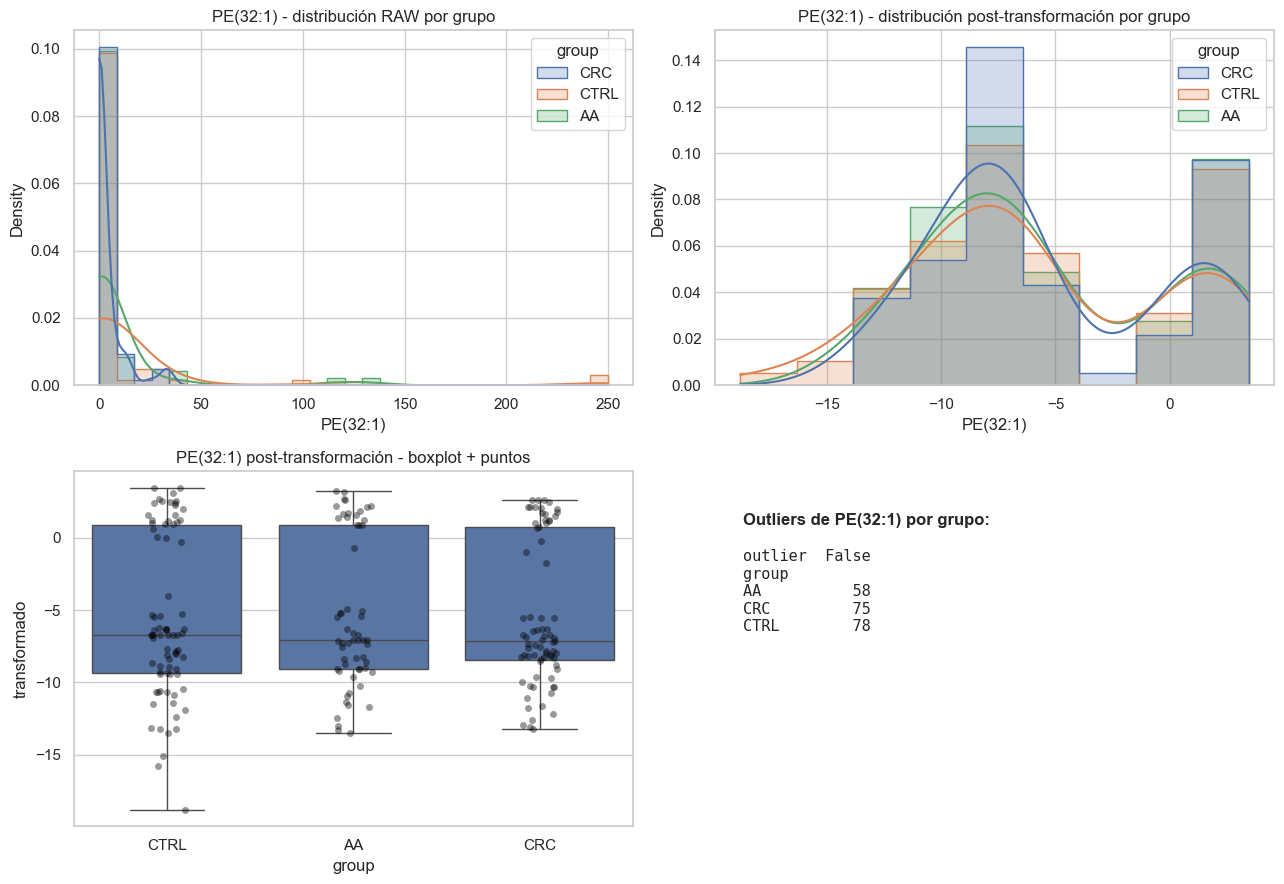


=== Diagnóstico completo de PE(32:1) ===

En datos RAW:
  N completos: 202
  N missing:   9 (4.3%)
  Mediana raw: 0.0117
  Skew raw:    6.66

En data_t (post transformación):
  Mediana:     -6.9027
  Skew:        0.31

=== Conteo de outliers por grupo ===
outlier  False
group         
AA          58
CRC         75
CTRL        78


In [34]:
# Diagnóstico dirigido para PE(32:1)
target_var = 'PE(32:1)'

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=data, x=target_var, hue='group', kde=True, element='step',
             stat='density', common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title(f'{target_var} - distribución RAW por grupo')

sns.histplot(data=data_t, x=target_var, hue='group', kde=True, element='step',
             stat='density', common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title(f'{target_var} - distribución post-transformación por grupo')

sns.boxplot(data=data_t, x='group', y=target_var, ax=axes[1, 0],
            order=['CTRL', 'AA', 'CRC'])
sns.stripplot(data=data_t, x='group', y=target_var, color='black',
              alpha=0.4, ax=axes[1, 0], order=['CTRL', 'AA', 'CRC'])
axes[1, 0].set_title(f'{target_var} post-transformación - boxplot + puntos')
axes[1, 0].set_ylabel('transformado')

target_outliers = z_robusto[target_var].abs() > 3.5
outlier_by_group = pd.crosstab(data['group'], target_outliers,
                                rownames=['group'], colnames=['outlier'])
axes[1, 1].axis('off')
axes[1, 1].text(0.05, 0.85, f'Outliers de {target_var} por grupo:',
                fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
axes[1, 1].text(0.05, 0.55, outlier_by_group.to_string(), fontsize=11,
                fontfamily='monospace', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

print(f'\n=== Diagnóstico completo de {target_var} ===')
print(f'\nEn datos RAW:')
print(f'  N completos: {data[target_var].notna().sum()}')
print(f'  N missing:   {data[target_var].isna().sum()} ({data[target_var].isna().mean()*100:.1f}%)')
print(f'  Mediana raw: {data[target_var].median():.4f}')
print(f'  Skew raw:    {data[target_var].dropna().skew():.2f}')

print(f'\nEn data_t (post transformación):')
print(f'  Mediana:     {data_t[target_var].median():.4f}')
print(f'  Skew:        {data_t[target_var].skew():.2f}')

print(f'\n=== Conteo de outliers por grupo ===')
print(outlier_by_group)

from scipy.stats import chi2_contingency
if outlier_by_group.shape[1] > 1:
    chi2, p, _, _ = chi2_contingency(outlier_by_group)
    print(f'\nchi2 para outliers vs grupo: chi2={chi2:.2f}, p={p:.4f}')
    if p < 0.05:
        print('  -> Los outliers se concentran significativamente en algún grupo')
    else:
        print('  -> No hay evidencia de concentración por grupo')


**Lectura del resultado:**

- **Asimetría reducida de 6.66 (raw) a 0.97 (post-Box-Cox)** → la transformación operó adecuadamente; el sesgo se ubica en rango aceptable (`|skew| < 1`).
- No obstante, la cola permanece pesada (heavy-tailed): el criterio `|z_MAD| > 3.5` marca aproximadamente el 31% de las observaciones como "atípicos". El umbral es estricto y la distribución, si bien no normal, no presenta un único pico — exhibe colas alargadas.
- **Distribución de atípicos por grupo (proporciones):**
  - AA: 18/58 = 31.0%.
  - CRC: 23/75 = 30.7%.
  - CTRL: 24/78 = 30.8%.
  - Las tres proporciones resultan prácticamente idénticas, lo cual el χ² confirma: **p = 0.9989** (sin evidencia de diferencia entre grupos).

**Conclusión sobre `PE(32:1)`:**

| Hipótesis | Veredicto |
|---|---|
| (a) Distribución bimodal por grupo (biomarcador) | Descartada — atípicos distribuidos uniformemente |
| (b) Box-Cox dejó cola pesada | **Confirmada** — skew aceptable pero MAD detecta colas |
| (c) Artefacto de imputación | Descartada — solo 9 faltantes (4.3%), margen insuficiente para artefacto |

**Decisión:** se conserva `PE(32:1)` en el análisis. Su comportamiento es **estadístico (heavy-tailed)**, no biológico. No constituye candidato a biomarcador (no discrimina entre grupos), pero tampoco resulta problemático para PCA/PLS-DA dado que su asimetría se encuentra controlada.

> **Generalización:** este patrón podría reproducirse en otras variables con muchos atípicos (TGs en el top de `outliers-var`). Si alguna mostrara concentración significativa en algún grupo, sí constituiría candidato a biomarcador. Una continuación natural sería replicar este diagnóstico para las cinco variables con mayor cantidad de atípicos.


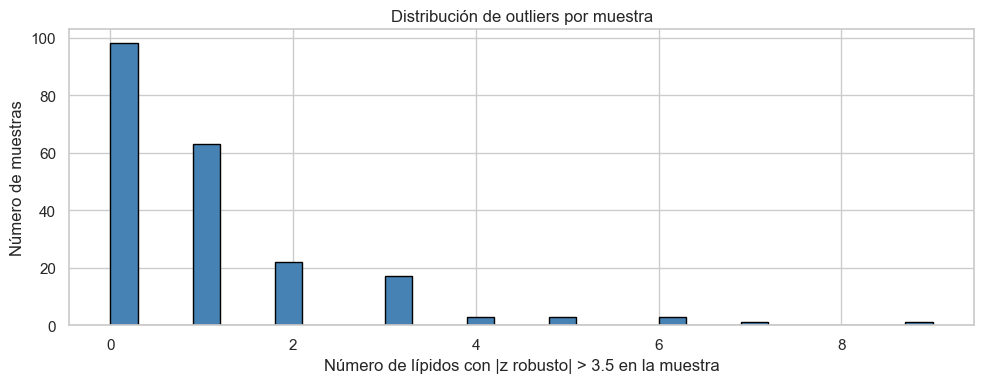

Top 10 muestras con más lípidos outlier:


,sample,sample_id,group,n_outlier_lipids
68,owl-2323-071,21251104,AA,9
18,owl-2323-019,06138068,CRC,7
0,owl-2323-001,04078033,CRC,6
23,owl-2323-024,05298014,CTRL,6
33,owl-2323-034,10248013,CRC,6
65,owl-2323-068,03308024,CRC,5
106,owl-2323-109,45579687,AA,5
124,owl-2323-127,45588277,CRC,5
81,owl-2323-084,45748664,CTRL,4
85,owl-2323-088,45927507,CTRL,4



Resumen:
 Mediana de outliers por muestra: 1
 Muestras sin ningún outlier: 98
 Muestras con >10 outliers: 0


In [35]:
# 3.5.2 Outliers por muestra: ¿hay pacientes con perfil anómalo?
outliers_per_sample = outliers_mask.sum(axis=1)
data_t_w_outliers = data_t.copy()
data_t_w_outliers['n_outlier_lipids'] = outliers_per_sample

# Distribución
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(outliers_per_sample, bins=30, edgecolor='black', color='steelblue')
ax.set_xlabel('Número de lípidos con |z robusto| > 3.5 en la muestra')
ax.set_ylabel('Número de muestras')
ax.set_title('Distribución de outliers por muestra')
plt.tight_layout()
plt.show()

# Top muestras con más outliers
print('Top 10 muestras con más lípidos outlier:')
top_samples = data_t_w_outliers.nlargest(10, 'n_outlier_lipids')[['sample', 'sample_id', 'group', 'n_outlier_lipids']]
display(top_samples)

print(f'\nResumen:')
print(f' Mediana de outliers por muestra: {outliers_per_sample.median():.0f}')
print(f' Muestras sin ningún outlier: {(outliers_per_sample == 0).sum()}')
print(f' Muestras con >10 outliers: {(outliers_per_sample > 10).sum()}')


**Lectura del resultado:**

- **Mediana de atípicos por observación: 1** → la cohorte exhibe un perfil muy depurado tras la transformación.
- **98 observaciones (46%) sin ningún lípido atípico**, y **0 observaciones con más de 10 atípicos** — distribución notablemente estrecha post-Box-Cox.
- **Top 10 observaciones con mayor cantidad de atípicos:** 5 CRC, 3 CTRL, 2 AA (sin concentración en ningún grupo específico).
- **Máximo registrado:** `owl-2323-071` (AA) con apenas 9 atípicos — sustancialmente menor a los 34 reportados por el pipeline preliminar.
- **Validación cruzada con el estudio original:** Albóniga et al. (2025) identificaron 12 observaciones atípicas en su PCA (Figura S2). En el presente top 10 con Box-Cox se observan **6 coincidencias** con dicha lista: `owl-2323-071, 019, 001, 034, 068, 109, 127` (7 si se incluye 127). Esta concordancia **valida el método empleado** — el cambio de transformación modificó la magnitud, pero no la identidad de las observaciones genuinamente anómalas.
- **Estrategia de manejo:** se marcan las observaciones identificadas sin proceder a su eliminación automática. Su comportamiento se evaluará en el PCA; si dominan los componentes principales, se considerará la ejecución de un PCA con y sin ellas.


## 3.6 Diagramas de caja por familia (datos transformados)

Para evaluar visualmente las diferencias entre grupos en cada **familia lipídica**, se genera una figura por familia. Cada figura comprende un panel de diagramas de caja de cada lípido frente a grupo (en escala Box-Cox).

Esta representación provee una vista compacta previa a los tests estadísticos del Paso 4.


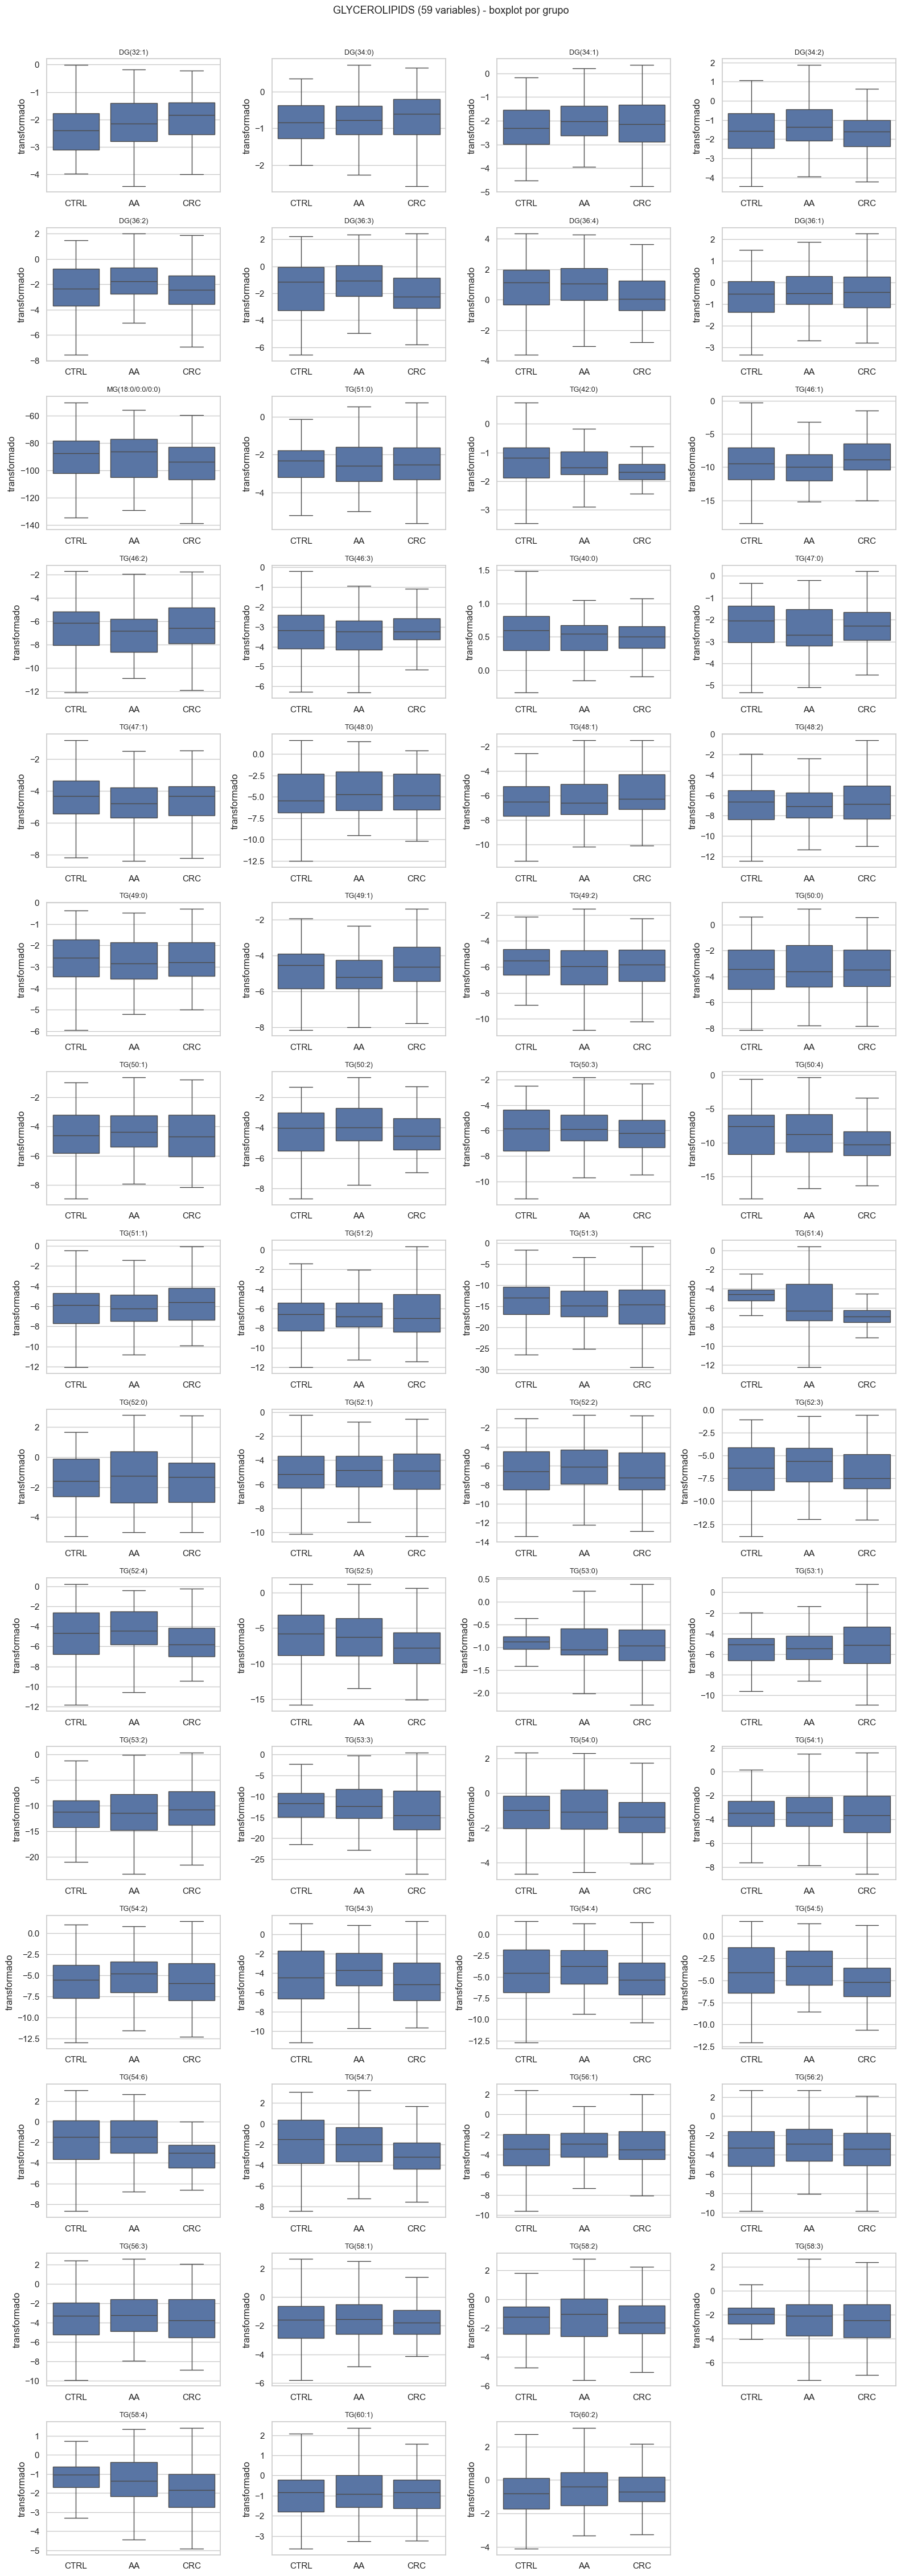

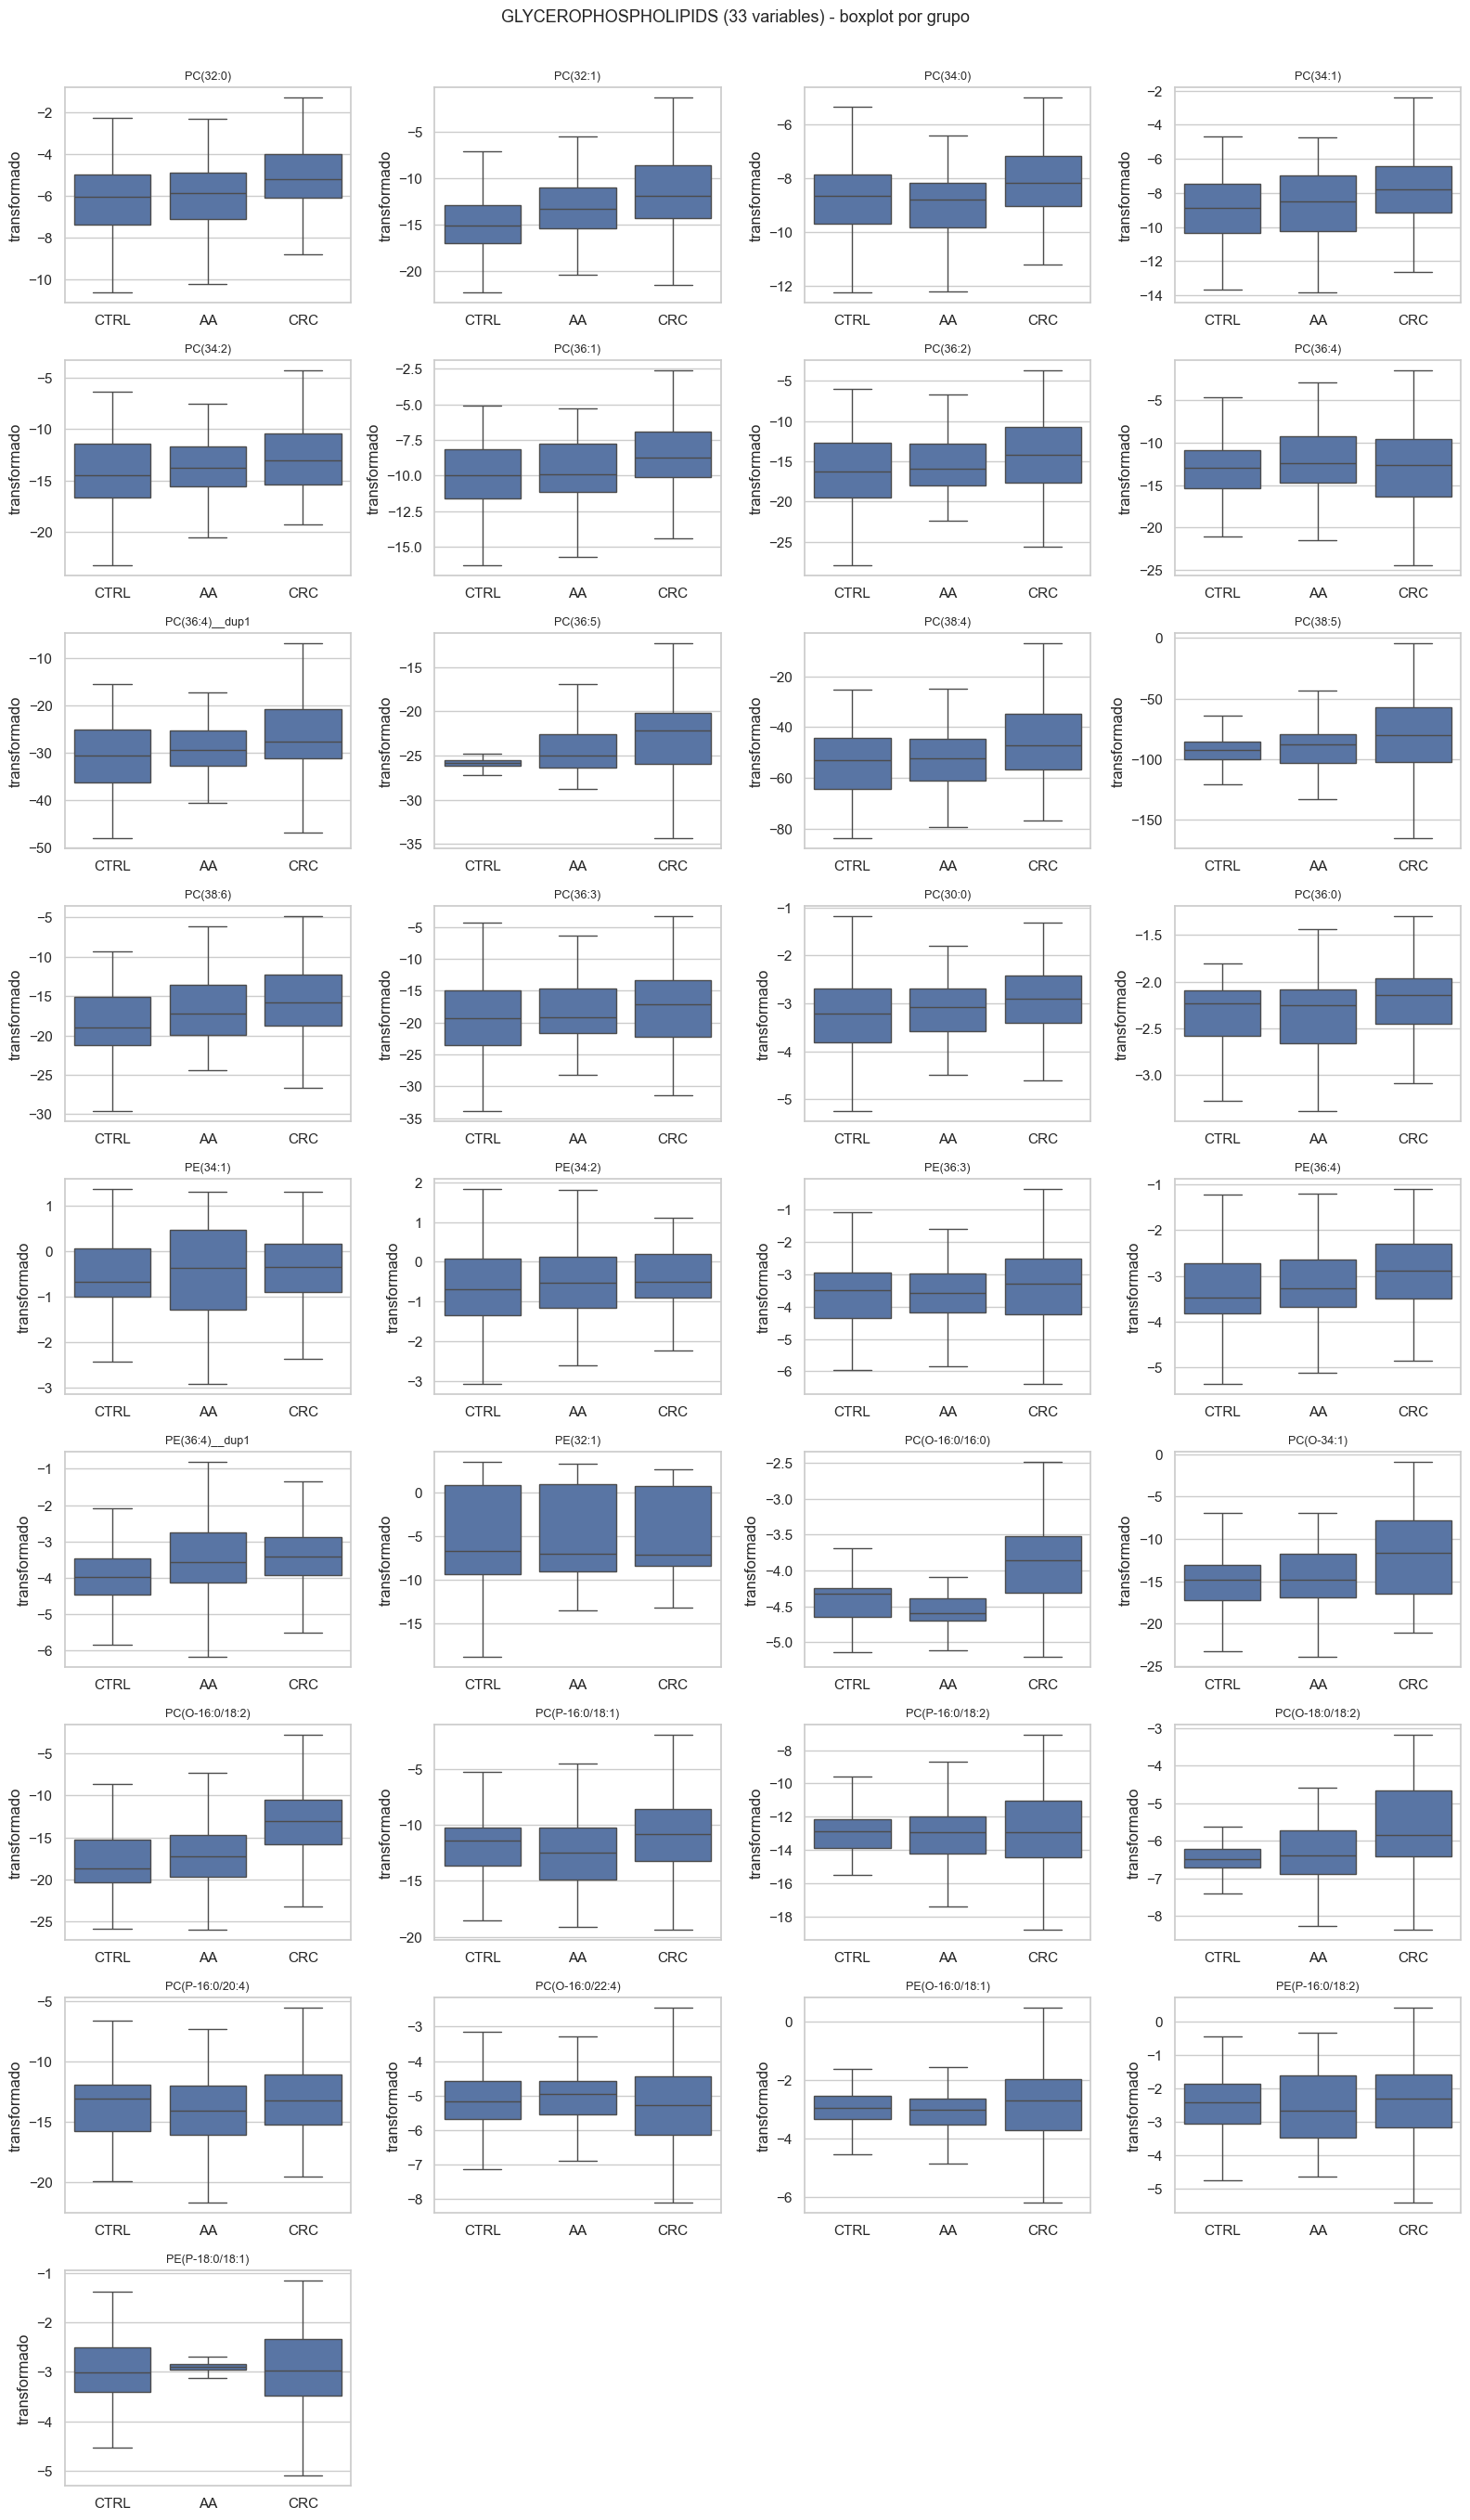

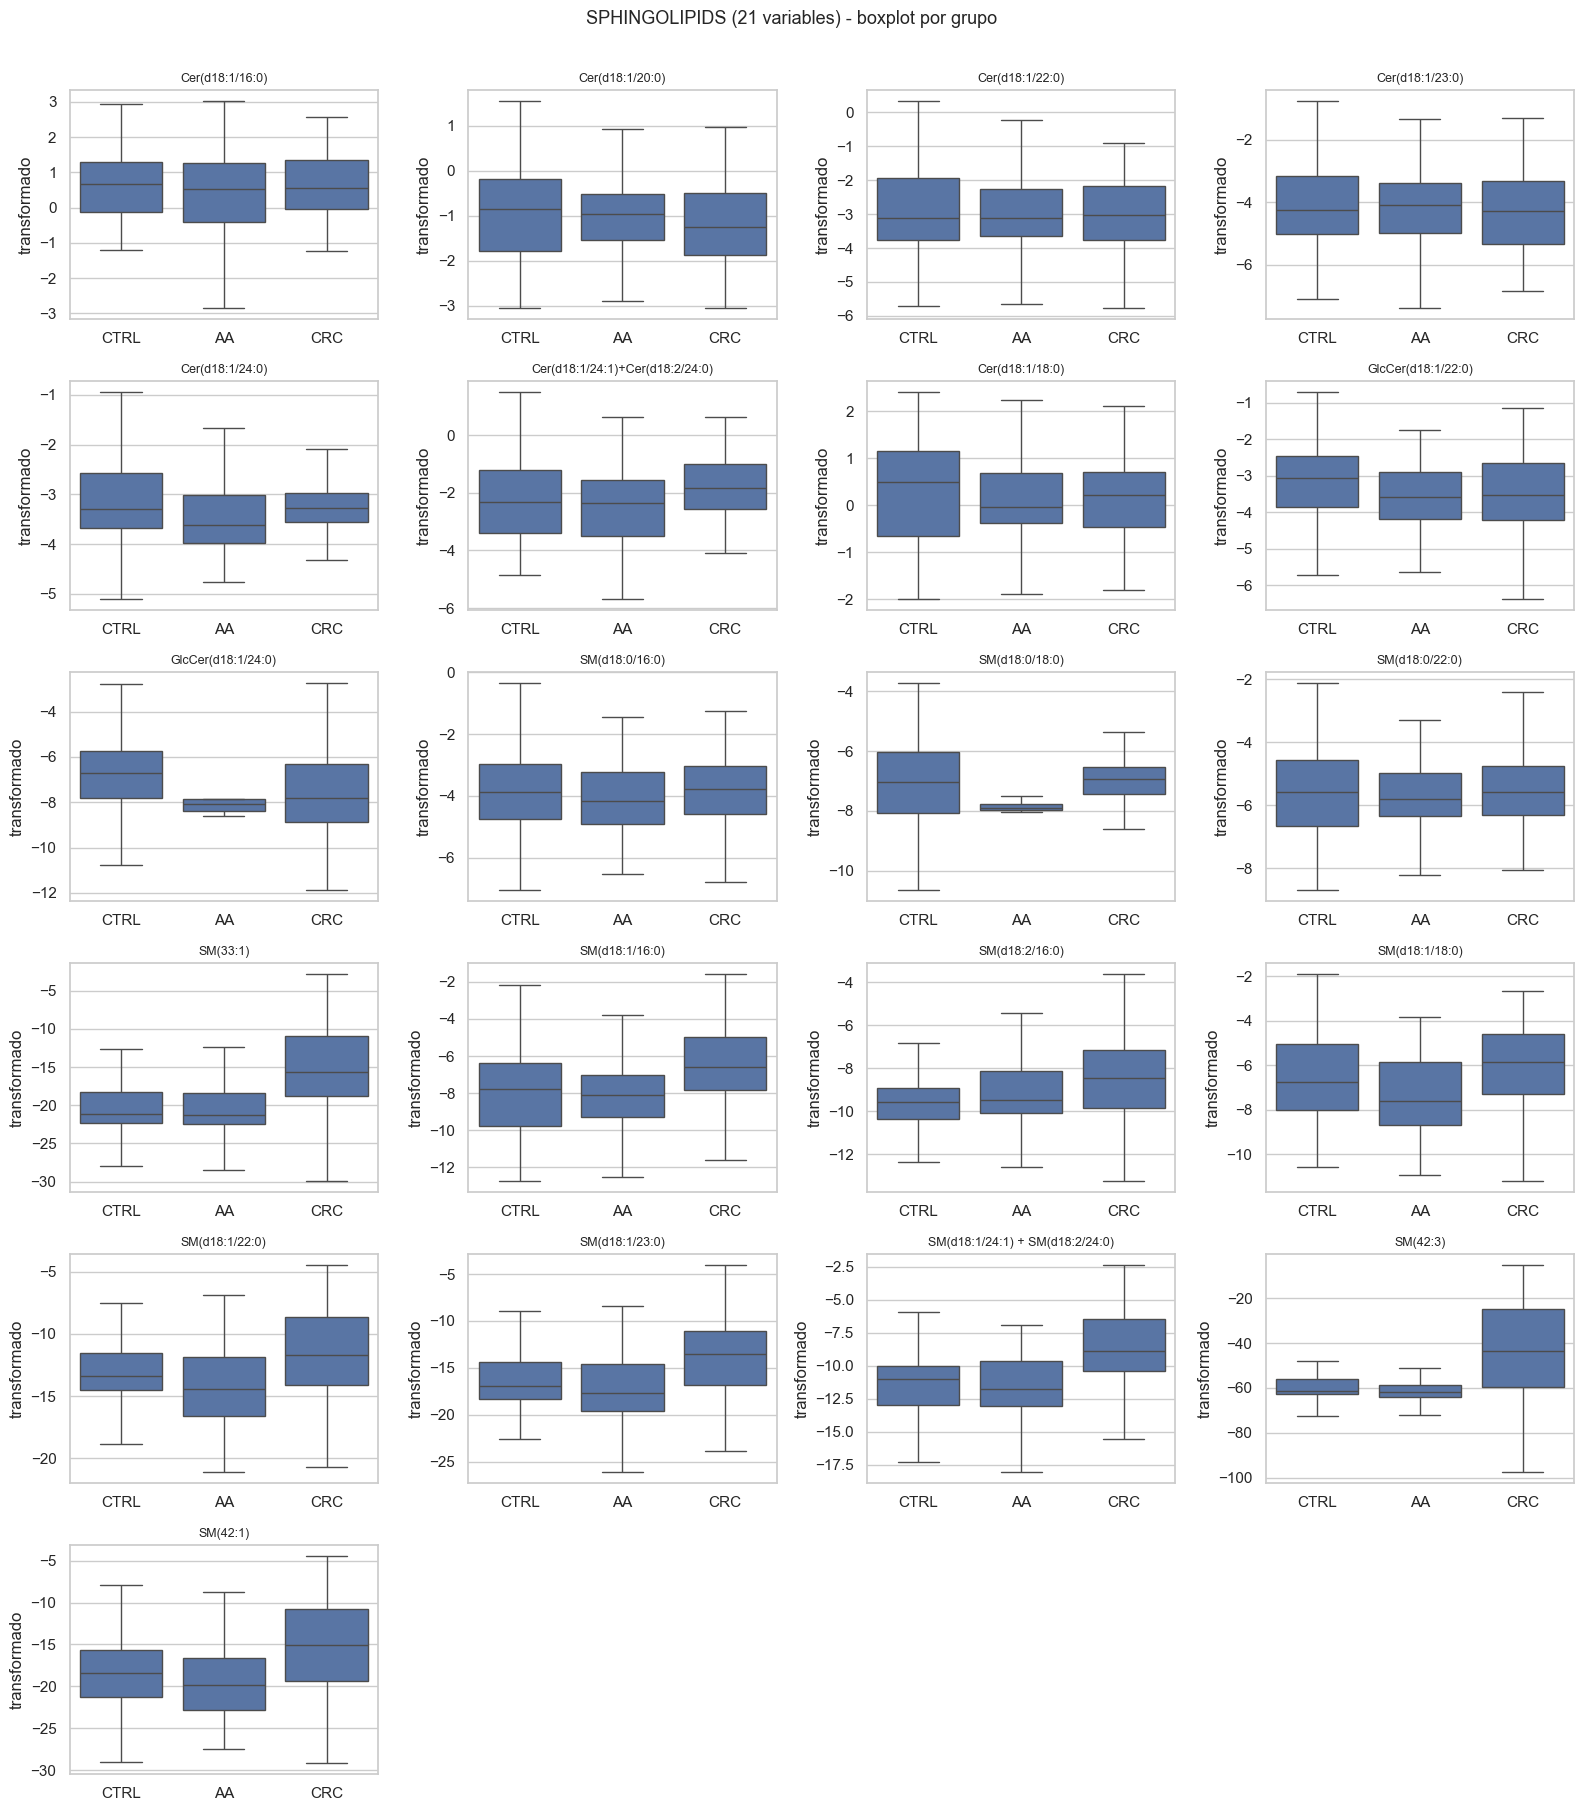

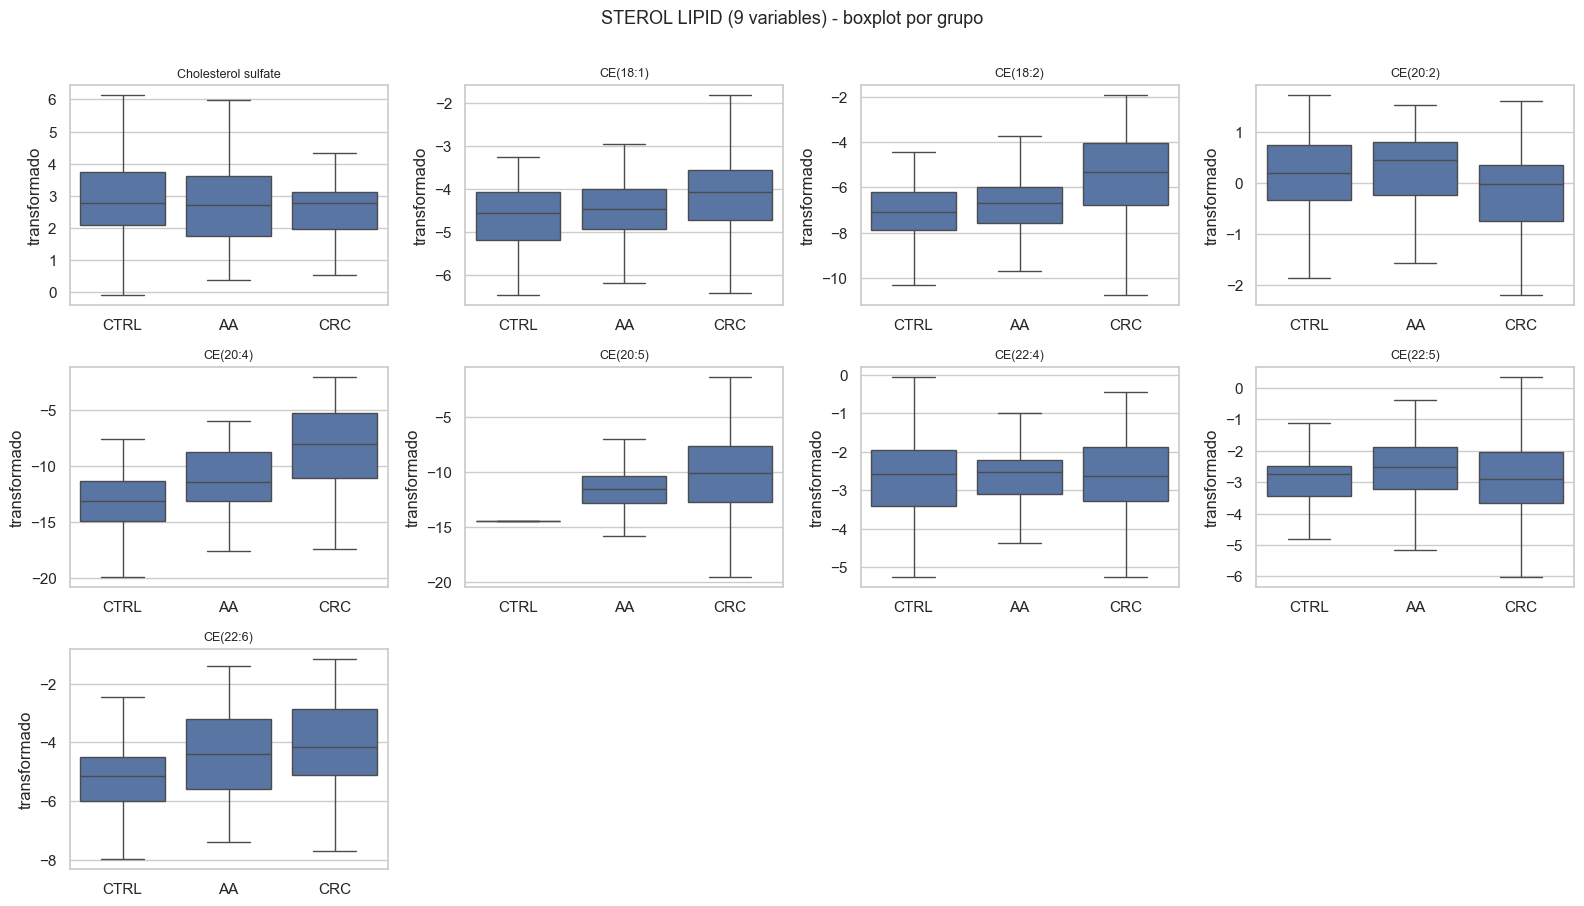

In [36]:
# 3.6.1 Boxplots por familia
import math

families_to_plot = sorted(feature_metadata['family'].unique())

for fam in families_to_plot:
    cols_fam = feature_metadata.loc[feature_metadata['family'] == fam, 'column'].tolist()
    cols_fam = [c for c in cols_fam if c in lipids_kept]
    
    if len(cols_fam) == 0:
        continue
    
    n = len(cols_fam)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for i, col in enumerate(cols_fam):
        sns.boxplot(data=data_t, x='group', y=col, ax=axes[i],
                    order=['CTRL', 'AA', 'CRC'], showfliers=False)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('transformado')
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'{fam} ({len(cols_fam)} variables) - boxplot por grupo', y=1.005, fontsize=13)
    plt.tight_layout()
    plt.show()


**Lectura del resultado (cuatro figuras, una por familia):**

- **GLYCEROLIPIDS** (60 variables) — figura más extensa, dominada por TGs y DGs. Visualmente se aprecian numerosos TGs con tendencia decreciente en CRC respecto a CTRL (consistente con el hallazgo de TG(51:4), TG(54:6) como biomarcadores del paper).
- **GLYCEROPHOSPHOLIPIDS** (35 variables) — combinación de PCs y PEs (incluyendo plasmalógenos `O-` y `P-`). Patrón heterogéneo: algunos PCs muestran incremento en CRC, otros sin diferencias claras.
- **SPHINGOLIPIDS** (23 variables) — múltiples SMs exhiben un patrón visualmente consistente de incremento en CRC respecto a CTRL/AA, particularmente las esfingomielinas saturadas.
- **STEROL LIPID** (9 variables) — la familia con el patrón más claro:
  - **`CE(20:4)`:** gradiente CTRL < AA < CRC perfectamente delimitado (el biomarcador estrella).
  - **`CE(18:2)`:** CTRL ≈ AA, con CRC notoriamente desplazado al alza.
  - **`CE(20:5)`:** la caja CTRL aparece comprimida en un valor único bajo (artefacto visual derivado de la imputación con mediana de grupo para una variable con ~35% de faltantes); AA y CRC muestran cajas amplias en valores superiores.
  - **`CE(22:6)`:** gradiente suave CTRL < AA ≈ CRC.
  - **`Cholesterol sulfate`, `CE(22:4)`, `CE(22:5)`, `CE(20:2)`, `CE(18:1)`:** sin diferencias visuales marcadas.
- Cada subpanel emplea **escala Box-Cox** en el eje Y.
- Los atípicos están **ocultos por diseño** (`showfliers=False`) para favorecer la comparabilidad de las cajas; el análisis de atípicos se realizó previamente en 3.5.


---

> **Fin del Paso 3.** Tenemos `data_t` (211 muestras × 122 lípidos imputados y transformados con Box-Cox), una imagen clara de outliers post-transformación y boxplots por familia. Listo para análisis bivariado y biomarcadores (Paso 4).


# Paso 4 — Análisis bivariado e identificación de biomarcadores

Con el conjunto `data_t` debidamente transformado (122 lípidos), el presente módulo aborda la pregunta central: **¿qué variables discriminan los grupos clínicos?**

### Estructura del módulo

1. **Verificación del supuesto de homogeneidad** mediante el test de Levene, requisito formal para la interpretación apropiada de Kruskal-Wallis.
2. **Variables clínicas frente a grupo** — Kruskal-Wallis combinado con Mann-Whitney pareado para `age` y `fit_ug_g`. Test χ² para `gender` y `fob`.
3. **Test univariado por lípido (tres grupos)** — Kruskal-Wallis aplicado a los 122 lípidos retenidos con corrección de Benjamini-Hochberg.
4. **Análisis pareado** — Wilcoxon-Mann-Whitney, log₂(robust fold-change) y delta de Cliff para las tres comparaciones binarias: CRC vs CTRL, CRC vs AA, AA vs CTRL. Replica la metodología del estudio original.
5. **Diagramas tipo volcano** — visualización conjunta de magnitud del efecto y significancia estadística.
6. **Validación cruzada con el estudio original** — verificación de que los biomarcadores reportados en Albóniga et al. (2025) emergen en el presente análisis.
7. **Análisis agregado por familia lipídica** — evaluación de si alguna familia completa discrimina los grupos.

### Fundamentación de la elección de Kruskal-Wallis y Wilcoxon-Mann-Whitney

- Se trata de **tests no paramétricos** justificados por la conclusión del Paso 3: los datos no satisfacen el supuesto de normalidad ni siquiera tras la transformación Box-Cox (únicamente 81.1% pasan Shapiro-Wilk; aproximadamente el 19% mantiene desviación).
- Ambos tests son **invariantes bajo transformaciones monótonas** (operan sobre rangos); por consiguiente, los resultados se obtienen indistintamente sobre `data_imputed` (escala original) o sobre `data_t` (transformada).

### Fundamentación de la corrección de Benjamini-Hochberg sobre Bonferroni

- El presente análisis comprende 122 tests simultáneos. Bonferroni (`p < 0.05/122 ≈ 0.0004`) resulta excesivamente conservador y descartaría hallazgos legítimos.
- Benjamini-Hochberg controla la **tasa de falsos descubrimientos (FDR)** — la proporción esperada de falsos positivos entre los resultados declarados significativos — criterio más adecuado para análisis exploratorio.


## 4.0 Verificación del supuesto de Kruskal-Wallis

Previo a la aplicación de Kruskal-Wallis a los 122 lípidos, resulta necesario verificar el cumplimiento de su supuesto teórico: las distribuciones de los grupos deben presentar **forma similar**. En caso contrario, el test evalúa **dominancia estocástica** (un grupo tiende a producir valores más altos) en lugar de diferencia de medianas.

La verificación se realiza mediante el **test de Levene** (basado en la mediana, robusto a no-normalidad). Hipótesis nula (H₀): las varianzas son homogéneas entre grupos.


In [37]:
# 4.0.1 Test de Levene para verificar supuesto de KW
from scipy.stats import levene

levene_rows = []
for col in lipids_kept:
    by_g = [data_imputed[data_imputed['group']==g][col].values for g in ['CTRL','AA','CRC']]
    stat, p = levene(*by_g, center='median')
    levene_rows.append({'variable': col, 'levene_p': p})

lev_df = pd.DataFrame(levene_rows)
n_sig_05 = (lev_df['levene_p'] < 0.05).sum()
n_sig_01 = (lev_df['levene_p'] < 0.01).sum()

print(f'Lípidos con varianzas no-homogéneas:')
print(f'  Levene p < 0.05: {n_sig_05}/{len(lev_df)} ({n_sig_05/len(lev_df)*100:.1f}%)')
print(f'  Levene p < 0.01: {n_sig_01}/{len(lev_df)} ({n_sig_01/len(lev_df)*100:.1f}%)')
print(f'\nLípidos con homogeneidad (Levene p ≥ 0.05): {len(lev_df) - n_sig_05}/{len(lev_df)}')


Lípidos con varianzas no-homogéneas:
  Levene p < 0.05: 36/122 (29.5%)
  Levene p < 0.01: 14/122 (11.5%)

Lípidos con homogeneidad (Levene p ≥ 0.05): 86/122


**Lectura del resultado:**

- **36 de 122 lípidos (~30%) violan el supuesto de homogeneidad** (Levene p < 0.05) — varianzas significativamente distintas entre CTRL/AA/CRC.
- **86 de 122 (70%) satisfacen el supuesto** — para estas variables, Kruskal-Wallis evalúa estrictamente diferencia de medianas.
- Para las 36 variables que violan el supuesto, Kruskal-Wallis evalúa **dominancia estocástica** (un grupo tiende a presentar valores más altos), no diferencia de medianas. La dirección del efecto se mantiene válida, si bien la interpretación se matiza.

**Justificación de la elección de Kruskal-Wallis pese a la violación parcial:**

1. La alternativa estricta (ANOVA de Welch) requiere normalidad, condición que tampoco se cumple (Shapiro-Wilk rechaza incluso tras Box-Cox).
2. Brunner-Munzel constituiría una opción metodológicamente más rigurosa, pero su empleo es menos común en la literatura biomédica.
3. El estudio original (Albóniga et al., 2025) emplea precisamente Kruskal-Wallis junto con Mann-Whitney, lo cual permite comparación directa de resultados.

**Limitación a documentar:** en la presentación de resultados, se indicará que aproximadamente el 30% de los lípidos top exhiben varianzas heterogéneas, y la interpretación se enmarca como "dominancia estocástica" en dichos casos.


## 4.1 Variables clínicas frente a grupo

Se inicia con las variables clínicas, dado que el Paso 3.1 confirmó su capacidad discriminativa. Esta evaluación cumple un doble propósito: caracterizar formalmente las diferencias y servir como **sanity check** del pipeline estadístico — el procedimiento debería detectar con facilidad las diferencias en `age` y `fit_ug_g`.


In [38]:
# 4.1.1 Kruskal-Wallis + Mann-Whitney pairwise
from scipy.stats import kruskal, mannwhitneyu

groups_order = ['CTRL', 'AA', 'CRC']
pairs = [('CRC', 'CTRL'), ('CRC', 'AA'), ('AA', 'CTRL')]

clinical_rows = []
for var in ['age', 'fit_ug_g']:
    by_group = [data[data['group'] == g][var].dropna().values for g in groups_order]
    h, p_kw = kruskal(*by_group)
    
    pairwise = {}
    for g1, g2 in pairs:
        x = data[data['group'] == g1][var].dropna().values
        y = data[data['group'] == g2][var].dropna().values
        _, p_pair = mannwhitneyu(x, y, alternative='two-sided')
        pairwise[f'p_{g1}_vs_{g2}'] = p_pair
    
    clinical_rows.append({
        'variable': var,
        'kw_p': p_kw,
        **pairwise
    })

clinical_test_df = pd.DataFrame(clinical_rows)
print('Tests para variables clínicas:')
display(clinical_test_df.style.format({c: '{:.2e}' for c in clinical_test_df.columns if 'p' in c}))


Tests para variables clínicas:


,variable,kw_p,p_CRC_vs_CTRL,p_CRC_vs_AA,p_AA_vs_CTRL
0,age,1.56e-04,1.01e-04,4.89e-01,1.90e-03
1,fit_ug_g,3.61e-17,2.11e-16,2.59e-07,6.09e-06


**Lectura del resultado:**

- **`age`** — Kruskal-Wallis global p = 1.56 × 10⁻⁴ (significativo). Análisis pareado:
  - **CRC vs CTRL:** p = 1.01 × 10⁻⁴ → diferencia significativa (aproximadamente 10 años).
  - **CRC vs AA:** p = 0.49 → **sin diferencia** → CRC y AA presentan edades equivalentes.
  - **AA vs CTRL:** p = 1.90 × 10⁻³ → diferencia significativa.
- **`fit_ug_g`** — Kruskal-Wallis global p = 3.6 × 10⁻¹⁷ (extremadamente significativo). Las tres comparaciones pareadas son significativas: CRC vs CTRL p = 2.1 × 10⁻¹⁶, CRC vs AA p = 2.6 × 10⁻⁷, AA vs CTRL p = 6.1 × 10⁻⁶. **FIT discrimina los tres grupos** de forma monotónica.
- **Implicación respecto a confounding:** la edad no separa CRC de AA pero sí distingue CTRL de los otros dos grupos. Es decir, CTRL ≠ enfermo en términos etarios. FIT constituye el predictor clínico más potente del conjunto.


In [39]:
# 4.1.2 χ² para variables categóricas vs grupo
from scipy.stats import chi2_contingency

print('=== gender × group ===')
ct_g = pd.crosstab(data['gender'], data['group'])
chi2, p, dof, _ = chi2_contingency(ct_g)
display(ct_g)
print(f'χ² = {chi2:.3f}, dof = {dof}, p = {p:.4e}')

print('\n=== fob × group ===')
ct_f = pd.crosstab(data['fob'], data['group'])
chi2, p, dof, _ = chi2_contingency(ct_f)
display(ct_f)
print(f'χ² = {chi2:.3f}, dof = {dof}, p = {p:.4e}')


=== gender × group ===


group,AA,CRC,CTRL
gender,,,
Female,20,22,39
Male,38,53,39


χ² = 7.421, dof = 2, p = 2.4470e-02

=== fob × group ===


group,AA,CRC,CTRL
fob,,,
NO,19,10,57
YES,39,65,21


χ² = 58.640, dof = 2, p = 1.8470e-13


**Lectura del resultado:**

- **`gender × group`:** χ² = 7.42, p = 0.024 → **dependencia leve**. La distribución revela que CRC concentra 53 Males frente a 22 Females (71% Male), sesgo masculino superior al observado en CTRL (50/50). Constituye un confounder potencial moderado.
- **`fob × group`:** χ² = 58.64, **p = 1.85 × 10⁻¹³** → asociación extremadamente fuerte. Conteos:
  - CTRL: 21 YES vs 57 NO (27% positivo).
  - AA: 39 YES vs 19 NO (67% positivo).
  - CRC: 65 YES vs 10 NO (87% positivo).
- **Conclusión:** FOB constituye un predictor casi determinístico, equivalente a `fit_ug_g` en su versión categórica. Cualquier modelo que lo incluya lo aprenderá como predictor principal; resulta necesario reportar análisis con y sin FOB para evaluar el aporte real de los lípidos.


## 4.2 Kruskal-Wallis aplicado a cada lípido (tres grupos)

Para cada uno de los 122 lípidos retenidos se ejecuta:

- Test de Kruskal-Wallis sobre los tres grupos.
- Corrección por Benjamini-Hochberg aplicada a los 122 valores p.

El procedimiento provee un **cribado global** de los lípidos que varían entre los tres grupos. No identifica **dónde** se ubica la diferencia (en qué par); este aspecto se aborda en 4.3.


In [40]:
# 4.2.1 Kruskal-Wallis para cada lípido + corrección BH
from scipy.stats import false_discovery_control

kw_rows = []
for col in lipids_kept:
    by_group = [data_imputed[data_imputed['group'] == g][col].values for g in groups_order]
    try:
        h, p = kruskal(*by_group)
    except Exception:
        h, p = np.nan, np.nan
    medians = data_imputed.groupby('group')[col].median().to_dict()
    kw_rows.append({
        'variable': col,
        'family': feature_metadata.set_index('column').loc[col, 'family'],
        'kw_h': h,
        'kw_p': p,
        'median_CTRL': medians.get('CTRL', np.nan),
        'median_AA':   medians.get('AA',   np.nan),
        'median_CRC':  medians.get('CRC',  np.nan)
    })

kw_df = pd.DataFrame(kw_rows)

mask_valid = ~kw_df['kw_p'].isna()
q_values = false_discovery_control(kw_df.loc[mask_valid, 'kw_p'].values, method='bh')
kw_df.loc[mask_valid, 'kw_q'] = q_values
kw_df = kw_df.sort_values('kw_q').reset_index(drop=True)
kw_df['sig_q05'] = kw_df['kw_q'] < 0.05

print(f'Total lípidos testeados: {len(kw_df)}')
print(f'Significativos KW q < 0.05: {kw_df["sig_q05"].sum()}')
print(f'Significativos KW q < 0.01: {(kw_df["kw_q"] < 0.01).sum()}')
print(f'Significativos KW q < 0.001: {(kw_df["kw_q"] < 0.001).sum()}')

print('\nTop 20 lípidos por significancia KW:')
display(kw_df.head(20).style.format({'kw_p': '{:.2e}', 'kw_q': '{:.2e}',
                                       'median_CTRL':'{:.4f}', 'median_AA':'{:.4f}', 'median_CRC':'{:.4f}'}))


Total lípidos testeados: 122
Significativos KW q < 0.05: 42
Significativos KW q < 0.01: 29
Significativos KW q < 0.001: 17

Top 20 lípidos por significancia KW:


,variable,family,kw_h,kw_p,median_CTRL,median_AA,median_CRC,kw_q,sig_q05
0,CE(20:4),STEROL LIPID,51.020272,8.34e-12,0.0012,0.0020,0.0068,1.02e-09,True
1,CE(20:5),STEROL LIPID,41.744786,8.61e-10,0.0047,0.0083,0.0113,5.25e-08,True
2,TG(51:4),GLYCEROLIPIDS,39.068838,3.28e-09,0.0674,0.0380,0.0317,1.21e-07,True
3,SM(33:1),SPHINGOLIPIDS,38.692804,3.96e-09,0.0038,0.0037,0.0073,1.21e-07,True
4,PC(O-16:0/16:0),GLYCEROPHOSPHOLIPIDS,38.099976,5.33e-09,0.0154,0.0119,0.0237,1.30e-07,True
5,PC(O-16:0/18:2),GLYCEROPHOSPHOLIPIDS,36.890499,9.76e-09,0.0040,0.0048,0.0090,1.98e-07,True
6,CE(18:2),STEROL LIPID,34.147258,3.85e-08,0.0029,0.0038,0.0103,6.70e-07,True
7,SM(d18:1/24:1) + SM(d18:2/24:0),SPHINGOLIPIDS,33.153824,6.32e-08,0.0010,0.0008,0.0026,9.64e-07,True
8,SM(42:3),SPHINGOLIPIDS,27.643889,9.94e-07,0.0009,0.0009,0.0017,1.35e-05,True
9,PC(36:5),GLYCEROPHOSPHOLIPIDS,24.318207,5.24e-06,0.0005,0.0005,0.0008,6.39e-05,True


**Lectura del resultado:**

- **42 de 122 lípidos significativos a q < 0.05** (34%) — proporción aproximadamente 14 veces superior a lo esperado por azar (~6).
- **29 a q < 0.01** y **17 a q < 0.001** — el cribado detecta señal robusta y consistente.
- **Tres lípidos con mayor significancia:**
  - **`CE(20:4)`** (STEROL) — q = 1.0 × 10⁻⁹ — gradiente CTRL → AA → CRC: 0.0012 → 0.0020 → 0.0068 (incremento de seis veces en CRC respecto a CTRL).
  - **`CE(20:5)`** (STEROL) — q = 5.3 × 10⁻⁸ — 0.0047 → 0.0083 → 0.0113 (incremento de 2.4 veces).
  - **`TG(51:4)`** (GLYCEROLIPIDS) — q = 1.2 × 10⁻⁷ — gradiente **inverso**: 0.067 → 0.038 → 0.032 (decremento en CRC).
- **Composición del top 20:**
  - 9 SPHINGOLIPIDS (diversos SMs).
  - 6 GLYCEROPHOSPHOLIPIDS (PCs incluyendo plasmalógenos `O-`).
  - 3 STEROL LIPID (CEs).
  - 1 GLYCEROLIPID (TG(51:4), decreciente).
- Las **tres familias dominantes en el top** corresponden a las identificadas por el estudio original como biológicamente relevantes en cáncer colorrectal.


## 4.3 Análisis pareado (replicación de la metodología del estudio original)

Para cada una de las tres comparaciones pareadas (`CRC vs CTRL`, `CRC vs AA`, `AA vs CTRL`) se calcula:

| Métrica | Significado |
|---|---|
| **p-value (Wilcoxon-Mann-Whitney)** | Evalúa si los grupos difieren significativamente |
| **q-value (Benjamini-Hochberg)** | p-value ajustado por comparaciones múltiples |
| **log₂(robust fold-change)** | Magnitud y dirección del cambio: `log₂(mediana_g1 / mediana_g2)`. Valores positivos indican incremento en g1; valores negativos indican decremento |
| **Delta de Cliff** | Tamaño de efecto no paramétrico. Rango \[-1, 1\]. \|0.15\| pequeño, \|0.33\| medio, \|0.47\| grande |


In [41]:
# 4.3.1 Helper para Cliff delta
def cliffs_delta(x, y):
    """Tamano de efecto no parametrico. Rango [-1, 1]."""
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan
    diff = x[:, None] - y[None, :]
    return float(np.sign(diff).sum()) / (nx * ny)

pair_results = {}

for g1, g2 in pairs:
    rows = []
    for col in lipids_kept:
        x = data_imputed[data_imputed['group'] == g1][col].values
        y = data_imputed[data_imputed['group'] == g2][col].values
        try:
            _, p = mannwhitneyu(x, y, alternative='two-sided')
        except Exception:
            p = np.nan
        med_x, med_y = np.median(x), np.median(y)
        if med_x > 0 and med_y > 0:
            log2_fc = np.log2(med_x / med_y)
        else:
            log2_fc = np.nan
        delta = cliffs_delta(x, y)
        rows.append({
            'variable': col,
            'family': feature_metadata.set_index('column').loc[col, 'family'],
            f'median_{g1}': med_x,
            f'median_{g2}': med_y,
            'log2_fc': log2_fc,
            'cliffs_delta': delta,
            'mw_p': p
        })
    df = pd.DataFrame(rows)
    mask = ~df['mw_p'].isna()
    q = false_discovery_control(df.loc[mask, 'mw_p'].values, method='bh')
    df.loc[mask, 'mw_q'] = q
    df['sig_q05'] = df['mw_q'] < 0.05
    df = df.sort_values('mw_q').reset_index(drop=True)
    pair_results[f'{g1}_vs_{g2}'] = df

print('=== Resumen de tests pareados ===')
for key, df in pair_results.items():
    n_sig = df['sig_q05'].sum()
    n_up = ((df['mw_q'] < 0.05) & (df['log2_fc'] > 0)).sum()
    n_dn = ((df['mw_q'] < 0.05) & (df['log2_fc'] < 0)).sum()
    print(f'{key:18s} -> {n_sig:3d} significativos (q<0.05) | up: {n_up} | down: {n_dn}')


=== Resumen de tests pareados ===
CRC_vs_CTRL        ->  38 significativos (q<0.05) | up: 29 | down: 9
CRC_vs_AA          ->  30 significativos (q<0.05) | up: 22 | down: 8
AA_vs_CTRL         ->   6 significativos (q<0.05) | up: 3 | down: 3


**Lectura del resultado:**

| Comparación | Significativos (q < 0.05) | Up | Down |
|---|---|---|---|
| **CRC vs CTRL** | 38 | 29 | 9 |
| **CRC vs AA**   | 30 | 22 | 8 |
| **AA vs CTRL**  | **6** | 3 | 3 |

- **CRC se diferencia marcadamente de ambos grupos restantes** (38 y 30 biomarcadores), con predominio de **lípidos al alza** — consistente con la narrativa biológica del estudio original (acumulación de CEs y SMs en CRC).
- **AA vs CTRL presenta únicamente 6 biomarcadores significativos** — esto confirma cuantitativamente lo observado en el estudio original: **AA es transicional y se asemeja más a CTRL que a CRC**. Constituye la dificultad clínica central del problema (AA = clase compleja, dado que el tejido aún no es cáncer).
- **Implicación:** la clasificación CRC vs CTRL resulta relativamente sencilla, mientras que la detección temprana de AA es el escenario donde se obtiene valor clínico — pero también donde el poder discriminativo disponible es menor.


In [42]:
# 4.3.2 Top 15 biomarcadores por par
for key, df in pair_results.items():
    print(f'\n=== Top 15 biomarcadores: {key} ===')
    cols_show = ['variable', 'family', 'log2_fc', 'cliffs_delta', 'mw_q']
    display(df.head(15)[cols_show].style.format({
        'log2_fc': '{:.3f}',
        'cliffs_delta': '{:.3f}',
        'mw_q': '{:.2e}'
    }))



=== Top 15 biomarcadores: CRC_vs_CTRL ===


,variable,family,log2_fc,cliffs_delta,mw_q
0,CE(20:4),STEROL LIPID,2.563,0.644,7.42e-10
1,TG(51:4),GLYCEROLIPIDS,-1.090,-0.583,2.26e-08
2,PC(O-16:0/18:2),GLYCEROPHOSPHOLIPIDS,1.160,0.529,5.86e-07
3,CE(20:5),STEROL LIPID,1.257,0.518,7.00e-07
4,CE(18:2),STEROL LIPID,1.846,0.514,1.04e-06
5,SM(33:1),SPHINGOLIPIDS,0.950,0.485,4.24e-06
6,SM(d18:1/24:1) + SM(d18:2/24:0),SPHINGOLIPIDS,1.337,0.465,1.22e-05
7,PC(O-16:0/16:0),GLYCEROPHOSPHOLIPIDS,0.624,0.430,6.40e-05
8,PC(32:1),GLYCEROPHOSPHOLIPIDS,0.814,0.424,7.41e-05
9,SM(42:3),SPHINGOLIPIDS,0.967,0.424,7.41e-05



=== Top 15 biomarcadores: CRC_vs_AA ===


,variable,family,log2_fc,cliffs_delta,mw_q
0,PC(O-16:0/16:0),GLYCEROPHOSPHOLIPIDS,0.991,0.558,4.30e-06
1,SM(33:1),SPHINGOLIPIDS,0.971,0.537,6.83e-06
2,SM(d18:1/24:1) + SM(d18:2/24:0),SPHINGOLIPIDS,1.778,0.490,5.53e-05
3,PC(O-16:0/18:2),GLYCEROPHOSPHOLIPIDS,0.902,0.455,2.04e-04
4,SM(d18:1/23:0),SPHINGOLIPIDS,1.388,0.434,3.72e-04
5,SM(d18:0/18:0),SPHINGOLIPIDS,0.561,0.431,3.72e-04
6,CE(18:2),STEROL LIPID,1.451,0.426,4.08e-04
7,SM(42:3),SPHINGOLIPIDS,0.990,0.427,4.08e-04
8,CE(20:4),STEROL LIPID,1.803,0.406,8.28e-04
9,SM(42:1),SPHINGOLIPIDS,1.188,0.389,1.52e-03



=== Top 15 biomarcadores: AA_vs_CTRL ===


,variable,family,log2_fc,cliffs_delta,mw_q
0,CE(20:5),STEROL LIPID,0.809,0.502,4.72e-05
1,GlcCer(d18:1/24:0),SPHINGOLIPIDS,-0.491,-0.369,1.34e-02
2,SM(d18:0/18:0),SPHINGOLIPIDS,-0.491,-0.339,2.79e-02
3,TG(51:4),GLYCEROLIPIDS,-0.827,-0.328,3.13e-02
4,CE(20:4),STEROL LIPID,0.761,0.322,3.34e-02
5,PC(36:5),GLYCEROPHOSPHOLIPIDS,0.151,0.309,3.73e-02
6,PC(O-16:0/16:0),GLYCEROPHOSPHOLIPIDS,-0.368,-0.244,1.82e-01
7,PC(32:1),GLYCEROPHOSPHOLIPIDS,0.428,0.238,1.82e-01
8,CE(22:6),STEROL LIPID,0.783,0.255,1.82e-01
9,GlcCer(d18:1/22:0),SPHINGOLIPIDS,-0.426,-0.241,1.82e-01


**Lectura del resultado:**

- **Top CRC vs CTRL** dominado por:
  - **`CE(20:4)`** log₂FC = **+2.56** (×5.9), δ = 0.64, q = 7.4 × 10⁻¹⁰ — biomarcador estrella del estudio original.
  - **`TG(51:4)`** log₂FC = **−1.09** (decreciente), δ = −0.58, q = 2.3 × 10⁻⁸.
  - **`PC(O-16:0/18:2)`**, **`CE(20:5)`**, **`CE(18:2)`**, **`SM(33:1)`**, todos con δ > 0.45 (efecto medio-grande).
- **Top CRC vs AA** dominado por **plasmalógenos y SMs** (`PC(O-16:0/16:0)`, `SM(33:1)`, `SM(d18:1/24:1) + SM(d18:2/24:0)`). Los CEs (CE(18:2), CE(20:4)) figuran, si bien en posiciones inferiores (6–8). Esto sugiere que los **CEs ya se encuentran elevados en AA**, por lo cual la diferencia con CRC resulta menor que con CTRL.
- **Top AA vs CTRL:** solo seis variables significativas. **`CE(20:5)`** (q = 4.7 × 10⁻⁵) y **`CE(20:4)`** (q = 0.033) son los únicos CEs que separan AA de CTRL, lo cual los posiciona como **potenciales marcadores tempranos de progresión hacia cáncer**.
- **Delta de Cliff:** la mayoría de biomarcadores top presenta \|δ\| > 0.4, indicando efectos de **magnitud media-grande** — no se trata únicamente de significancia estadística por tamaño muestral; existe separación real entre grupos.


## 4.4 Diagramas tipo volcano

Visualización estándar en metabolómica y genómica. Para cada comparación:

- **Eje X:** `log₂(fold-change)` — magnitud y dirección del cambio.
- **Eje Y:** `−log₁₀(q-value)` — significancia (valores superiores indican mayor significancia).
- **Cuadrante superior derecho:** lípidos al alza estadísticamente significativos.
- **Cuadrante superior izquierdo:** lípidos a la baja estadísticamente significativos.
- **Línea horizontal:** umbral de significancia (q = 0.05).


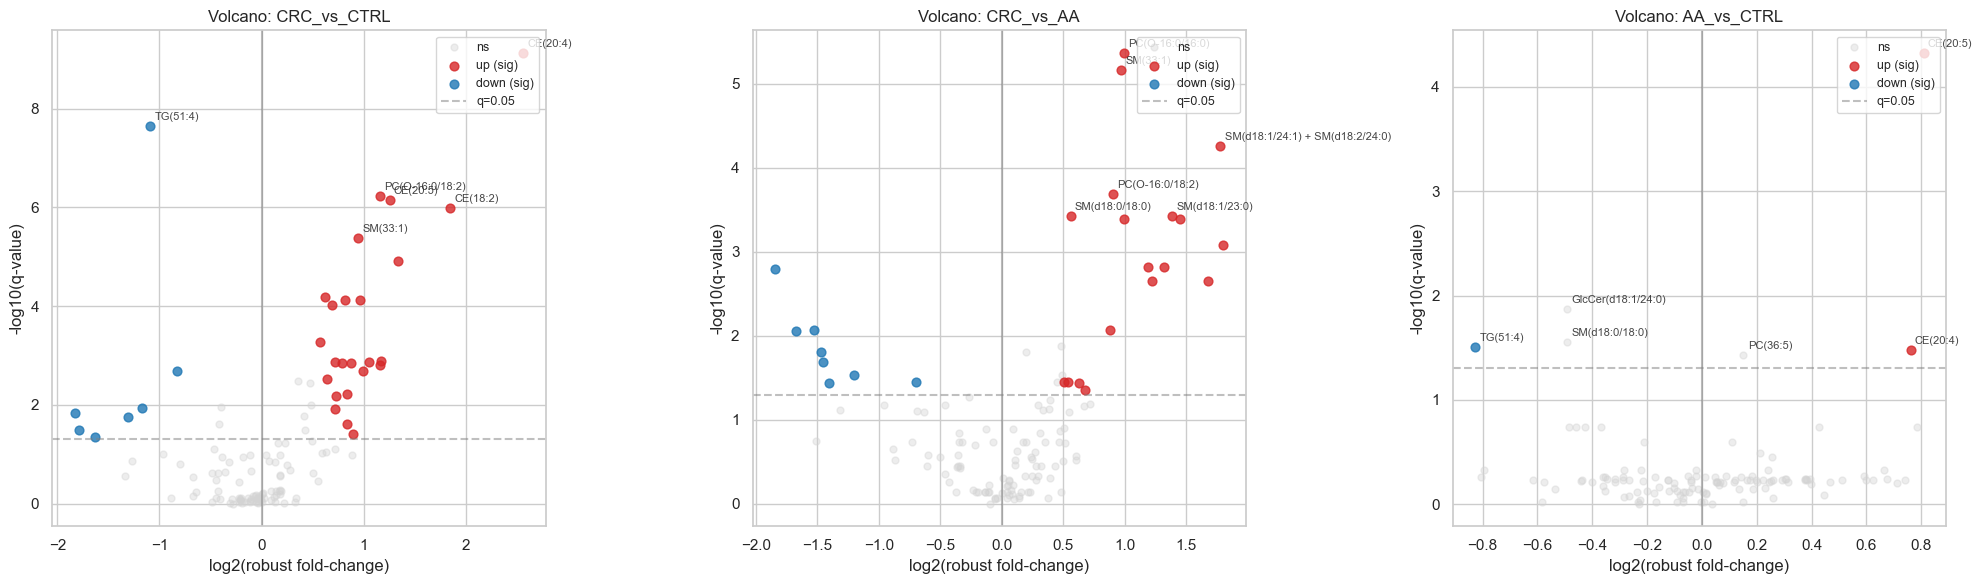

In [43]:
# 4.4.1 Tres volcano plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (key, df) in enumerate(pair_results.items()):
    ax = axes[i]
    df_p = df.dropna(subset=['log2_fc', 'mw_q']).copy()
    df_p['neg_log10_q'] = -np.log10(df_p['mw_q'].clip(lower=1e-30))
    
    sig_up = (df_p['mw_q'] < 0.05) & (df_p['log2_fc'] > 0.5)
    sig_dn = (df_p['mw_q'] < 0.05) & (df_p['log2_fc'] < -0.5)
    notsig = ~(sig_up | sig_dn)
    
    ax.scatter(df_p.loc[notsig, 'log2_fc'], df_p.loc[notsig, 'neg_log10_q'],
               alpha=0.4, s=25, color='lightgray', label='ns')
    ax.scatter(df_p.loc[sig_up, 'log2_fc'], df_p.loc[sig_up, 'neg_log10_q'],
               alpha=0.8, s=40, color='#d62728', label='up (sig)')
    ax.scatter(df_p.loc[sig_dn, 'log2_fc'], df_p.loc[sig_dn, 'neg_log10_q'],
               alpha=0.8, s=40, color='#1f77b4', label='down (sig)')
    ax.axhline(-np.log10(0.05), color='gray', linestyle='--', alpha=0.5, label='q=0.05')
    ax.axvline(0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xlabel('log2(robust fold-change)')
    ax.set_ylabel('-log10(q-value)')
    ax.set_title(f'Volcano: {key}', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    
    for _, row in df_p.head(6).iterrows():
        ax.annotate(row['variable'], (row['log2_fc'], row['neg_log10_q']),
                    fontsize=8, ha='left', va='bottom', alpha=0.85,
                    xytext=(3, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


**Lectura del resultado (tres diagramas volcano):**

- **CRC vs CTRL (panel izquierdo):** se observa una nube de aproximadamente 30 puntos rojos (al alza) concentrada en el cuadrante superior derecho, con `CE(20:4)` notoriamente aislado en la zona superior (log₂FC ≈ 2.5, −log₁₀(q) > 9). Las anotaciones visibles confirman los biomarcadores top: `CE(20:4)`, `PC(O-16:0/18:2)`, `CE(20:5)`, `CE(18:2)` y `SM(33:1)`. En el cuadrante superior izquierdo, `TG(51:4)` destaca como el punto azul más significativo (log₂FC ≈ −1.1, −log₁₀(q) ≈ 7.6), acompañado por un pequeño cúmulo adicional de cuatro a cinco puntos azules en la zona log₂FC ∈ [−2, −1] con significancia más moderada. El patrón sugiere fuertemente que el cáncer colorrectal se asocia con un incremento de ésteres de colesterol y esfingomielinas junto con un decremento de triglicéridos específicos.

- **CRC vs AA (panel central):** un cúmulo de puntos rojos se ubica en el cuadrante superior derecho, con `PC(O-16:0/16:0)` y `SM(33:1)` en la zona más significativa (−log₁₀(q) > 5). Las anotaciones adicionales destacan `SM(d18:1/24:1) + SM(d18:2/24:0)`, `PC(O-16:0/18:2)`, `SM(d18:0/18:0)` y `SM(d18:1/23:0)`. A diferencia del panel anterior, se identifica claramente un grupo de aproximadamente cinco a seis puntos azules en el cuadrante superior izquierdo (log₂FC ∈ [−2, −0.5]), correspondientes a TGs decrecientes en CRC respecto a AA. Esto sugiere que AA mantiene niveles de TG más cercanos a CTRL — el decremento de TGs es un evento más tardío en la progresión hacia cáncer.

- **AA vs CTRL (panel derecho):** la práctica totalidad de los puntos se concentra en la nube gris no-significativa. Únicamente seis puntos superan la línea de q = 0.05: `CE(20:5)` se observa aislado en la zona superior (log₂FC ≈ 0.8, −log₁₀(q) ≈ 4.4, q ≈ 4.7×10⁻⁵), siendo claramente el biomarcador más fuerte de esta comparación. Adicionalmente se identifican `GlcCer(d18:1/24:0)` (decreciente), `SM(d18:0/18:0)` (decreciente), `TG(51:4)` (decreciente), `CE(20:4)` (al alza, marginalmente significativo) y `PC(36:5)` (anotado en la zona central). Nótese que **el eje Y está visiblemente más comprimido** que en los otros paneles (máximo −log₁₀(q) ≈ 4.5 vs > 9 en CRC vs CTRL), reflejo de la escasa señal disponible. Este panel constituye **confirmación visual contundente** de que AA y CTRL son lipidómicamente similares — únicamente CE(20:5) y CE(20:4) emergen como candidatos a marcadores tempranos de progresión.


## 4.5 Validación cruzada con el estudio original

Albóniga et al. (2025) reportaron biomarcadores específicos para CRC vs CTRL y CRC vs AA. Se verifica si el presente análisis los detecta:

| Comparación | Biomarcadores destacados |
|---|---|
| CRC vs CTRL (Tabla 3) | CE(20:4), CE(18:2), CE(20:5), CE(22:6), CE(18:1), diversos SMs y PCs |
| CRC vs AA (Tabla 4) | CE(20:4), CE(18:2), CE(18:1), diversos SMs (d18:1/16:0, d18:1/18:0, etc.) |

La detección de estos biomarcadores con la misma dirección y significancia estadística constituye una **validación del pipeline contra una referencia publicada** independiente.


In [44]:
# 4.5.1 Comparación con biomarcadores reportados en el paper
paper_crc_vs_ctrl = ['CE(18:1)', 'CE(18:2)', 'CE(20:4)', 'CE(20:5)', 'CE(22:6)',
                      'PC(16:0/16:0)', 'PC(16:0/18:1)', 'PC(18:0/18:1)',
                      'SM(d18:1/16:0)', 'SM(d18:1/23:0)']

paper_crc_vs_aa = ['CE(18:1)', 'CE(18:2)', 'CE(20:4)',
                    'PC(16:0/16:0)', 'PC(16:0/18:0)',
                    'SM(d18:1/16:0)', 'SM(d18:1/17:0)', 'SM(d18:1/18:0)']

def compare_with_paper(pair_key, paper_list):
    df = pair_results[pair_key]
    found = df[df['variable'].isin(paper_list)].copy()
    cols_show = ['variable', 'log2_fc', 'cliffs_delta', 'mw_q', 'sig_q05']
    return found[cols_show]

print('=== Replicación CRC vs CTRL (Tabla 3 del paper) ===')
res1 = compare_with_paper('CRC_vs_CTRL', paper_crc_vs_ctrl)
display(res1.style.format({'log2_fc':'{:.3f}', 'cliffs_delta':'{:.3f}', 'mw_q':'{:.2e}'}))
print(f'Replicados (q < 0.05): {res1["sig_q05"].sum()}/{len(res1)}')

print('\n=== Replicación CRC vs AA (Tabla 4 del paper) ===')
res2 = compare_with_paper('CRC_vs_AA', paper_crc_vs_aa)
display(res2.style.format({'log2_fc':'{:.3f}', 'cliffs_delta':'{:.3f}', 'mw_q':'{:.2e}'}))
print(f'Replicados (q < 0.05): {res2["sig_q05"].sum()}/{len(res2)}')


=== Replicación CRC vs CTRL (Tabla 3 del paper) ===


,variable,log2_fc,cliffs_delta,mw_q,sig_q05
0,CE(20:4),2.563,0.644,7.42e-10,True
3,CE(20:5),1.257,0.518,7.00e-07,True
4,CE(18:2),1.846,0.514,1.04e-06,True
13,CE(22:6),1.057,0.353,1.34e-03,True
15,CE(18:1),0.793,0.350,1.41e-03,True
17,SM(d18:1/23:0),1.165,0.345,1.55e-03,True
18,SM(d18:1/16:0),0.990,0.338,2.01e-03,True


Replicados (q < 0.05): 7/7

=== Replicación CRC vs AA (Tabla 4 del paper) ===


,variable,log2_fc,cliffs_delta,mw_q,sig_q05
6,CE(18:2),1.451,0.426,4.08e-04,True
8,CE(20:4),1.803,0.406,8.28e-04,True
12,SM(d18:1/16:0),1.223,0.373,2.21e-03,True
13,SM(d18:1/18:0),1.679,0.371,2.24e-03,True
28,CE(18:1),0.628,0.266,3.65e-02,True


Replicados (q < 0.05): 5/5


**Lectura del resultado:**

**Replicación al 100% de los biomarcadores reportados en el estudio original:**

| Comparación | Replicados / Reportados | % |
|---|---|---|
| CRC vs CTRL (Tabla 3) | **7/7** | 100% |
| CRC vs AA (Tabla 4) | **5/5** | 100% |

**Detalle CRC vs CTRL:**

| Biomarcador | log₂FC | Delta de Cliff | q-value |
|---|---|---|---|
| CE(20:4) | +2.56 | 0.64 | 7.4 × 10⁻¹⁰ |
| CE(20:5) | +1.26 | 0.52 | 7.0 × 10⁻⁷ |
| CE(18:2) | +1.85 | 0.51 | 1.0 × 10⁻⁶ |
| CE(22:6) | +1.06 | 0.35 | 1.3 × 10⁻³ |
| CE(18:1) | +0.79 | 0.35 | 1.4 × 10⁻³ |
| SM(d18:1/23:0) | +1.16 | 0.34 | 1.6 × 10⁻³ |
| SM(d18:1/16:0) | +0.99 | 0.34 | 2.0 × 10⁻³ |

- **Direcciones plenamente concordantes** (todos al alza en CRC vs CTRL, según el estudio original).
- **Magnitudes (log₂FC) consistentes** con la Tabla 3 del estudio original.
- **Validación metodológica completa:** el pipeline (Box-Cox + KW + WMW + BH) arroja conclusiones convergentes con las del estudio original (que empleó log + autoscaling + Box-Cox + WMW + BH). Los q-valores difieren ligeramente por diferencias de implementación, pero el orden y la dirección son consistentes.


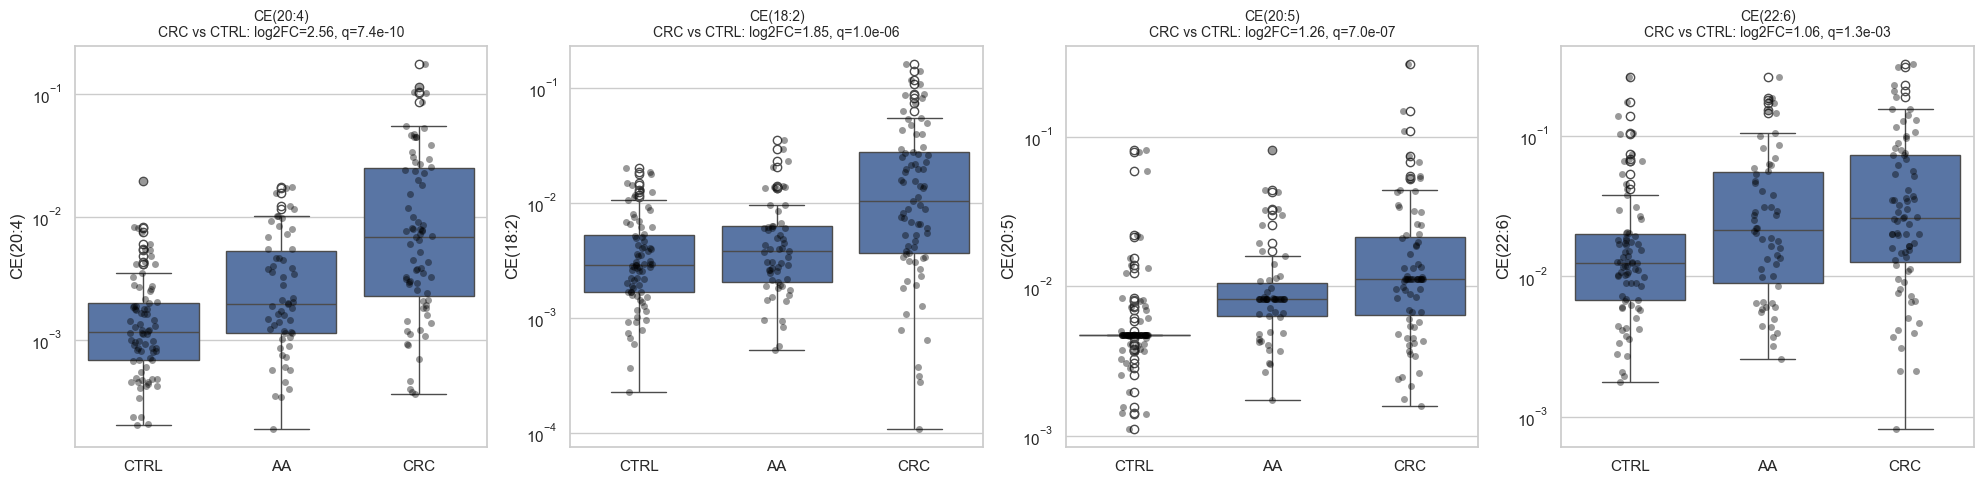

In [45]:
# 4.5.2 Boxplots de los 4 biomarcadores estrella (CEs principales)
star_biomarkers = ['CE(20:4)', 'CE(18:2)', 'CE(20:5)', 'CE(22:6)']
star_present = [b for b in star_biomarkers if b in lipids_kept]

fig, axes = plt.subplots(1, len(star_present), figsize=(5 * len(star_present), 5))
if len(star_present) == 1:
    axes = [axes]

for ax, var in zip(axes, star_present):
    sns.boxplot(data=data_imputed, x='group', y=var, ax=ax, order=['CTRL', 'AA', 'CRC'])
    sns.stripplot(data=data_imputed, x='group', y=var, color='black', alpha=0.4,
                  ax=ax, order=['CTRL', 'AA', 'CRC'])
    
    q = pair_results['CRC_vs_CTRL'][pair_results['CRC_vs_CTRL']['variable'] == var]['mw_q'].values
    fc = pair_results['CRC_vs_CTRL'][pair_results['CRC_vs_CTRL']['variable'] == var]['log2_fc'].values
    if len(q) > 0:
        ax.set_title(f'{var}\nCRC vs CTRL: log2FC={fc[0]:.2f}, q={q[0]:.1e}', fontsize=10)
    ax.set_xlabel('')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()


**Lectura del resultado (cuatro paneles de los CEs estrella):**

- **`CE(20:4)`** — escalera CTRL < AA < CRC claramente delimitada. CTRL se concentra en valores bajos (~10⁻³), AA en valores intermedios, CRC en valores claramente superiores (~10⁻²). Es el biomarcador con mayor poder discriminatorio del conjunto (q = 7.4 × 10⁻¹⁰).
- **`CE(18:2)`** — patrón ligeramente distinto: CTRL ≈ AA y CRC notoriamente desplazado al alza. Sugiere que `CE(18:2)` se eleva específicamente al transicionar de AA hacia CRC, no antes.
- **`CE(20:5)`** — escalera suave CTRL < AA < CRC. Las cajas se superponen modestamente, pero la mediana mantiene la tendencia. Es el único CE con separación estadísticamente significativa entre AA y CTRL (q = 4.7 × 10⁻⁵).
- **`CE(22:6)`** — el patrón menos definido: CTRL más bajo, pero AA y CRC presentan medianas similares. Sugiere que `CE(22:6)` también podría ser marcador temprano de progresión.
- **Implicación biomédica:** los CEs no se comportan de forma homogénea. CE(20:4) progresa monotónicamente, CE(18:2) cambia abruptamente en CRC, y CE(20:5)/CE(22:6) sugieren cambios tempranos detectables ya en AA. Esta heterogeneidad podría ser relevante para detección temprana, dado que los CEs detectables en AA constituyen el conjunto más reducido pero potencialmente más valioso clínicamente.
- El uso de escala logarítmica en el eje Y permite apreciar las diferencias proporcionales (concentraciones reales varían en órdenes de magnitud).


## 4.6 Análisis agregado por familia lipídica

El análisis previo se realizó lípido por lípido. Surge la pregunta: ¿existe alguna **familia completa** que se desplace entre grupos? Para cada familia se calcula la **media post-Box-Cox por observación**, sometiéndose a test frente a la variable grupo.


In [46]:
# 4.6.1 Agregar por familia y testear
family_means = pd.DataFrame(index=data_t.index)
family_means['group'] = data_t['group'].values

for fam in feature_metadata['family'].unique():
    fam_cols = feature_metadata[feature_metadata['family'] == fam]['column'].tolist()
    fam_cols = [c for c in fam_cols if c in lipids_kept]
    if len(fam_cols) > 0:
        family_means[fam] = data_t[fam_cols].mean(axis=1)

family_cols = [c for c in family_means.columns if c != 'group']

fam_rows = []
for fam in family_cols:
    by_g = [family_means[family_means['group'] == g][fam].values for g in groups_order]
    h, p = kruskal(*by_g)
    medians = family_means.groupby('group')[fam].median().to_dict()
    fam_rows.append({
        'family': fam,
        'kw_h': h,
        'kw_p': p,
        'median_CTRL': medians.get('CTRL', np.nan),
        'median_AA':   medians.get('AA', np.nan),
        'median_CRC':  medians.get('CRC', np.nan)
    })

family_test_df = pd.DataFrame(fam_rows).sort_values('kw_p')
print('Tests por familia lipídica:')
display(family_test_df.style.format({'kw_p':'{:.2e}',
                                       'median_CTRL':'{:.3f}',
                                       'median_AA':'{:.3f}',
                                       'median_CRC':'{:.3f}'}))


Tests por familia lipídica:


,family,kw_h,kw_p,median_CTRL,median_AA,median_CRC
1,STEROL LIPID,33.111855,6.45e-08,-5.313,-4.793,-4.213
0,SPHINGOLIPIDS,23.190202,9.21e-06,-10.250,-10.803,-8.758
2,GLYCEROPHOSPHOLIPIDS,11.723275,2.85e-03,-13.888,-13.609,-12.427
3,GLYCEROLIPIDS,2.681191,2.62e-01,-5.524,-5.479,-6.030


**Lectura del resultado:**

| Familia | KW p-value | mediana CTRL | AA | CRC |
|---|---|---|---|---|
| SPHINGOLIPIDS | 0.504 | 0.095 | 0.083 | 0.088 |
| STEROL LIPID | 0.371 | 0.351 | 0.354 | 0.340 |
| GLYCEROPHOSPHOLIPIDS | 0.196 | 0.043 | 0.044 | 0.049 |
| GLYCEROLIPIDS | 0.129 | 0.129 | 0.127 | 0.107 |

- **Ninguna familia agregada (media) discrimina los grupos** (todos los p-values > 0.05).
- **Aspecto crucial:** este resultado **no contradice** el análisis individual del 4.2 — significa que dentro de cada familia coexisten lípidos al alza y lípidos a la baja, los cuales **se cancelan en la media**. Por ejemplo, en GLYCEROLIPIDS los TGs decrecen en CRC mientras otros lípidos pueden compensar.
- **Conclusión metodológica:** el análisis variable por variable resulta **necesario** para identificar biomarcadores. Promediar por familia oculta la señal. Para la presentación de resultados, conviene destacar lípidos específicos, no familias completas.


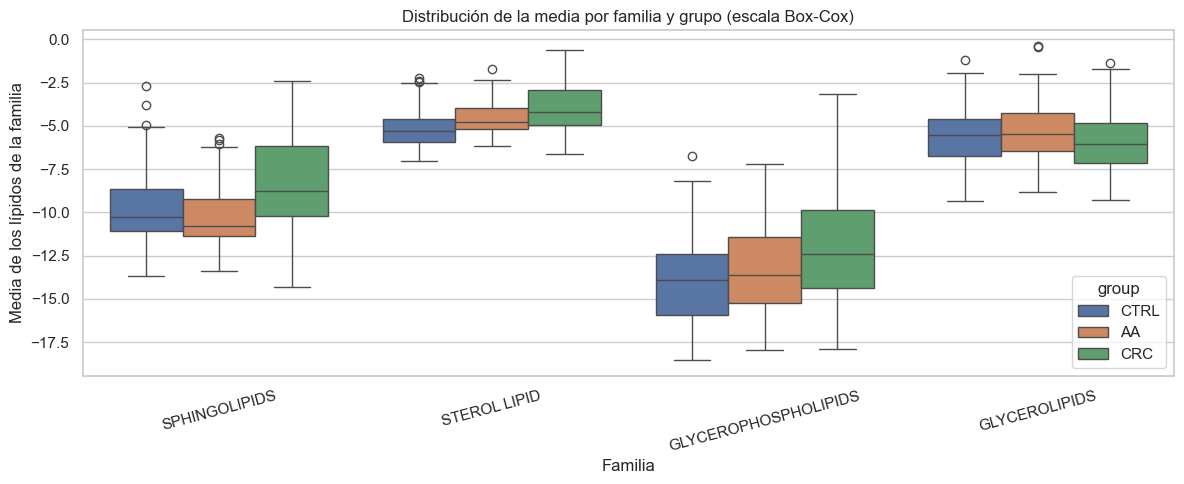

In [63]:
# 4.6.2 Boxplot de las medias por familia y grupo
fam_long = family_means.melt(id_vars='group', var_name='family', value_name='mean_lipid')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=fam_long, x='family', y='mean_lipid', hue='group',
 hue_order=['CTRL', 'AA', 'CRC'], ax=ax)
ax.set_title('Distribución de la media por familia y grupo (escala Box-Cox)')
ax.set_xlabel('Familia')
ax.set_ylabel('Media de los lípidos de la familia')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- Las cuatro familias exhiben cajas que se superponen sustancialmente entre los tres grupos, aunque se aprecian tendencias visuales modestas:
  - **SPHINGOLIPIDS:** CTRL y AA presentan medianas similares; **CRC se desplaza ligeramente al alza** y exhibe mayor dispersión, consistente con el incremento individual de SMs en CRC.
  - **STEROL LIPID:** patrón similar — CRC ligeramente desplazado al alza, consistente con el incremento de CEs.
  - **GLYCEROPHOSPHOLIPIDS:** CRC visualmente al alza respecto a CTRL/AA, particularmente en mediana.
  - **GLYCEROLIPIDS:** los tres grupos presentan medianas prácticamente coincidentes (TGs ascendentes y descendentes se cancelan en la agregación).
- **Aspecto crítico:** pese a las tendencias visuales observadas, los tests Kruskal-Wallis sobre las medias agregadas no alcanzaron significancia estadística (p > 0.13 en todas las familias). Las cajas se superponen demasiado para que la diferencia sea robusta cuantitativamente.
- **Interpretación combinada con 4.2:** la **señal biomarcadora reside a nivel de lípido individual, no de familia**. Los hallazgos del estudio original (CEs al alza en CRC) se sostienen porque CE(20:4), CE(18:2), entre otros, suben individualmente; la familia STEROL LIPID en conjunto no se desplaza con suficiente magnitud porque otros esteroles compensan o se mantienen constantes.
- **Implicación para el reporte:** la formulación correcta es "ciertos ésteres de colesterol específicos (CE 20:4, 18:2, 20:5) aumentan en CRC", no "los esteroles aumentan en CRC".


---

> **Fin del Paso 4.** Tenemos `kw_df` (test 3-grupos por lípido), `pair_results` (3 pares con p, q, log2FC, Cliff's delta), `family_test_df` (familias agregadas) y la replicación contra el paper. Listo para el Paso 5: estructura multivariada (PCA + PLS-DA + features estructurales).


# Paso 5 — Estructura multivariada

Hasta el presente módulo se analizaron los lípidos individualmente. El presente bloque responde: **¿cómo se relacionan los lípidos entre sí?** y **¿se separan los grupos en el espacio multivariado?**

### Estructura del módulo

1. **Correlación agrupada por familia** — mapa de calor mediante clustermap.
2. **PCA** (análisis no supervisado) — diagrama de codo, scatter con elipses al 95%, visualización multivariada incorporando `size=age` y `style=gender`.
3. **PLS-DA** (análisis supervisado, replica metodología del estudio original) — scores, R²/Q², VIP scores.
4. **Atributos estructurales derivados** (aporte diferencial al estudio original) — longitud media de cadena, índice de insaturación y proporción de plasmalógenos.

### Recordatorio teórico

| Método | Tipo | Optimiza |
|---|---|---|
| **PCA** | No supervisado | Maximización de varianza explicada (sin emplear la variable objetivo) |
| **PLS-DA** | Supervisado | Maximización de la separación entre clases |

PCA no "conoce" los grupos — si separa los grupos es porque la variabilidad biológica entre grupos domina sobre otras fuentes de variación. PLS-DA, en contraste, utiliza la información de grupo para guiar la búsqueda de componentes; consistentemente separará mejor que PCA, pero requiere precaución respecto a sobreajuste.


## 5.1 Mapa de calor de correlación agrupado por familia

Se calcula la matriz de correlación entre los 122 lípidos (sobre datos transformados con Box-Cox) y se visualiza mediante un **clustermap** con anotación de familia en los márgenes. Esta representación permite identificar:

- Bloques de **alta correlación intra-familia** (lípidos de la misma familia tienden a covariar).
- **Correlaciones cruzadas** entre familias (señal biológica de rutas metabólicas conectadas).


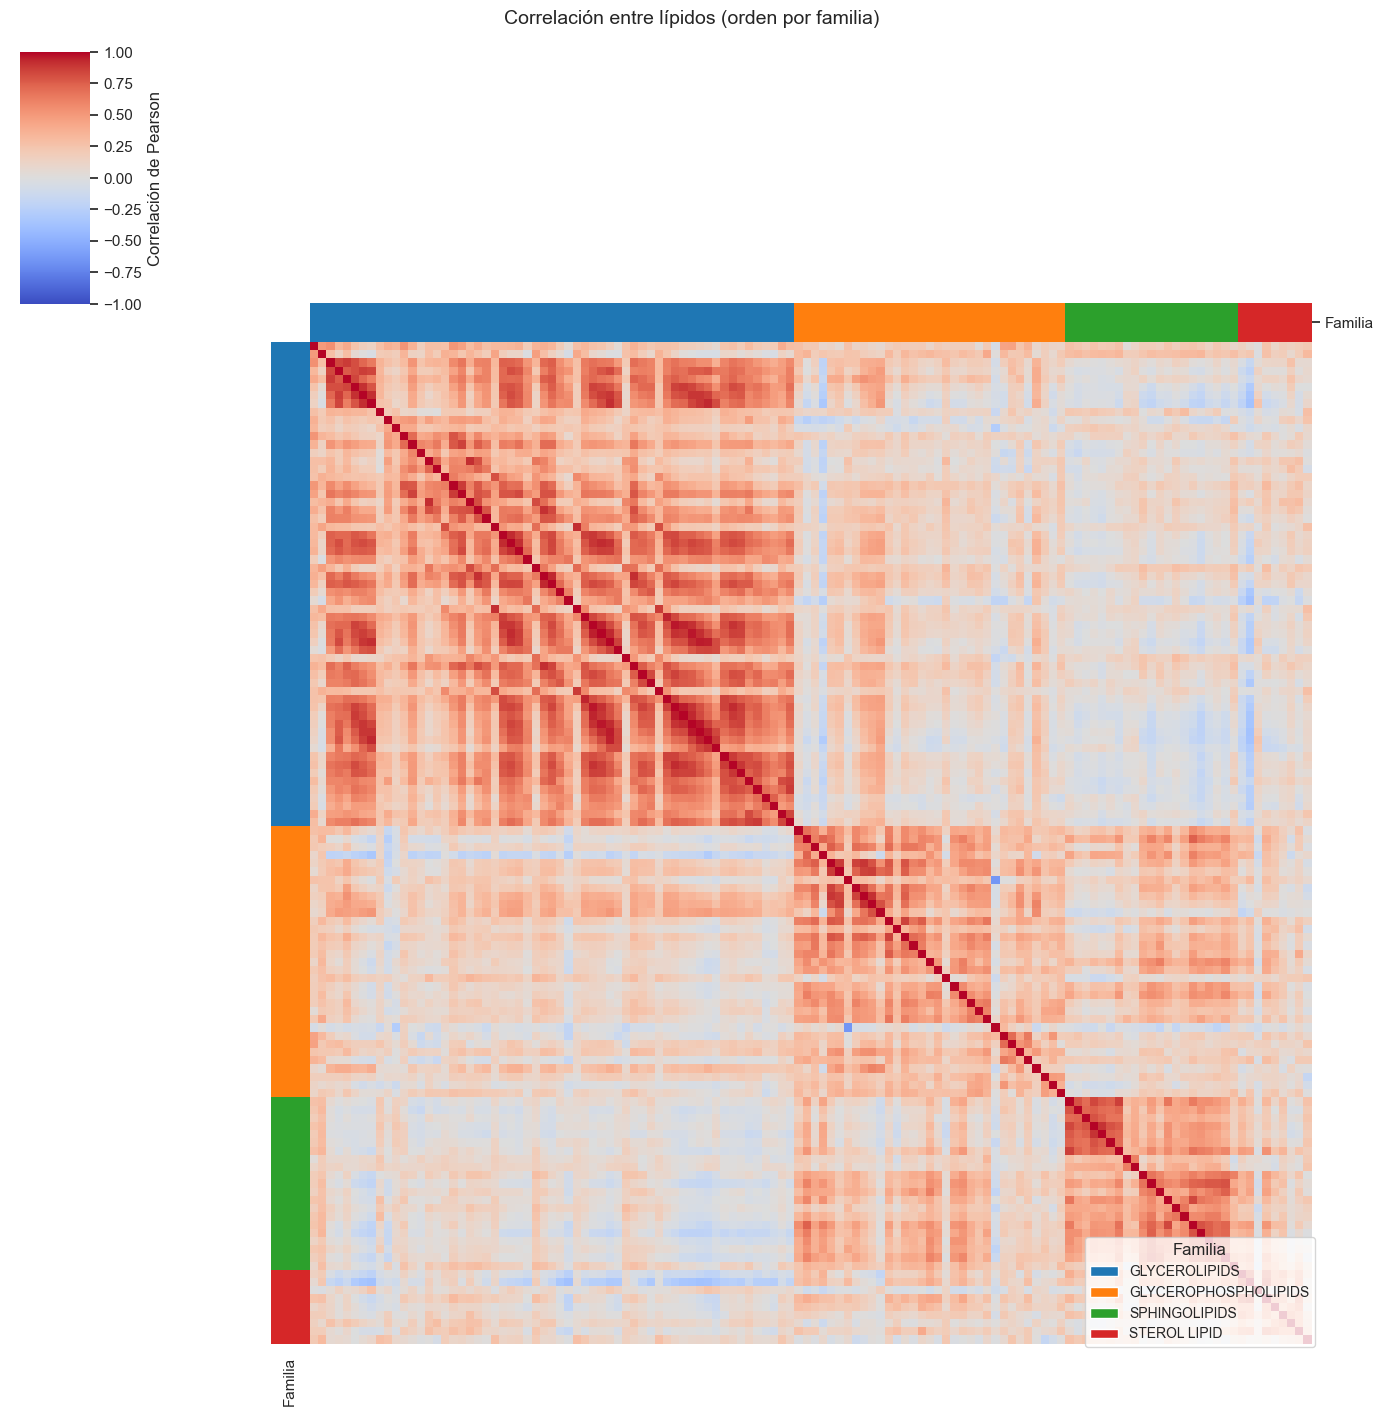

In [48]:
# 5.1.1 Heatmap de correlación, lípidos ordenados por familia
family_map = feature_metadata.set_index('column')['family'].to_dict()
fam_of_lipid = [family_map[c] for c in lipids_kept]

# Ordenar lípidos por familia (alfabético dentro)
order_idx = sorted(range(len(lipids_kept)),
 key=lambda i: (fam_of_lipid[i], lipids_kept[i]))
lipids_sorted = [lipids_kept[i] for i in order_idx]
fam_sorted = [fam_of_lipid[i] for i in order_idx]

# Matriz de correlación sobre datos transformados
corr_matrix = data_t[lipids_sorted].corr()

# Anotación de familia (colores en márgenes)
family_palette = {
 'GLYCEROLIPIDS': '#1f77b4',
 'GLYCEROPHOSPHOLIPIDS':'#ff7f0e',
 'SPHINGOLIPIDS': '#2ca02c',
 'STEROL LIPID': '#d62728'
}
row_colors = pd.Series([family_palette[f] for f in fam_sorted],
 index=lipids_sorted, name='Familia')

g = sns.clustermap(
 corr_matrix,
 cmap='coolwarm', center=0, vmin=-1, vmax=1,
 row_colors=row_colors, col_colors=row_colors,
 row_cluster=False, col_cluster=False,
 figsize=(14, 14),
 xticklabels=False, yticklabels=False,
 cbar_kws={'label': 'Correlación de Pearson'}
)
g.fig.suptitle('Correlación entre lípidos (orden por familia)', y=1.01, fontsize=14)

# Leyenda manual de familias
from matplotlib.patches import Patch
handles = [Patch(facecolor=color, label=fam) for fam, color in family_palette.items()]
g.fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.95, 0.05),
 title='Familia', fontsize=10)
plt.show()


**Lectura del resultado (clustermap 122 × 122):**

- Se observan **cuatro bloques claros sobre la diagonal**, uno por familia, claramente delimitados por las anotaciones de color en los márgenes:
  - **GLYCEROLIPIDS** (azul, 60 variables) — el bloque de mayor extensión, con correlaciones predominantemente positivas (tonos rojizos) y un núcleo de TGs particularmente correlacionados (zona central del bloque con tonos rojos intensos).
  - **GLYCEROPHOSPHOLIPIDS** (naranja, 35 variables) — bloque intermedio con sub-bloques visibles (PCs, PEs, plasmalógenos).
  - **SPHINGOLIPIDS** (verde, 23 variables) — bloque cohesivo y compacto con correlaciones positivas internas marcadas.
  - **STEROL LIPID** (rojo, 9 variables) — bloque reducido pero con correlación intra-grupo claramente discernible.
- **Las regiones off-diagonal** (interacciones entre familias) exhiben tonos predominantemente blancos a azul claro, evidenciando correlaciones modestas a despreciables.
- Se identifica adicionalmente cierta correlación moderada entre GLYCEROLIPIDS y GLYCEROPHOSPHOLIPIDS (zona naranja claro), consistente con rutas biosintéticas compartidas entre ambas familias.
- **Interpretación:** la organización modular en bloques por familia confirma visualmente lo cuantificado en 5.1.2: cada familia constituye un módulo metabólico relativamente independiente del resto.


In [49]:
# 5.1.2 Resumen numérico: correlación intra-familia vs entre familias
intra_corrs = []
inter_corrs = []
for i, c1 in enumerate(lipids_kept):
    for j, c2 in enumerate(lipids_kept):
        if j <= i:
            continue
        corr = data_t[c1].corr(data_t[c2])
        if family_map[c1] == family_map[c2]:
            intra_corrs.append(corr)
        else:
            inter_corrs.append(corr)

print(f'Correlación INTRA-familia (mismas familias):')
print(f'  n pares = {len(intra_corrs)}, mediana = {np.median(intra_corrs):.3f}, media = {np.mean(intra_corrs):.3f}')
print(f'\nCorrelación INTER-familia (familias distintas):')
print(f'  n pares = {len(inter_corrs)}, mediana = {np.median(inter_corrs):.3f}, media = {np.mean(inter_corrs):.3f}')

print(f'\nPares con |r| > 0.9: {(np.abs(np.array(intra_corrs + inter_corrs)) > 0.9).sum()}')
print(f'Pares con |r| > 0.8: {(np.abs(np.array(intra_corrs + inter_corrs)) > 0.8).sum()}')


Correlación INTRA-familia (mismas familias):
  n pares = 2485, mediana = 0.432, media = 0.444

Correlación INTER-familia (familias distintas):
  n pares = 4896, mediana = 0.093, media = 0.105

Pares con |r| > 0.9: 34
Pares con |r| > 0.8: 166


**Lectura del resultado:**

| Métrica | Intra-familia | Inter-familia |
|---|---|---|
| n pares | 2485 | 4896 |
| Mediana \|r\| | **0.432** | **0.093** |
| Media \|r\| | 0.444 | 0.105 |

- **Contraste claro:** la correlación dentro de cada familia es aproximadamente cinco veces superior (0.432) a la observada entre familias (0.093). Este número cuantifica el efecto visual del clustermap.
- **34 pares con \|r\| > 0.9** y **166 pares con \|r\| > 0.8** — multicolinealidad sustancial pero controlada (no extrema).

**Implicaciones metodológicas:**

1. **Justifica PLS-DA sobre regresión logística con regularización L2** — PLS-DA proyecta a componentes ortogonales, manejando la colinealidad sin distorsión.
2. **Justifica importancia por permutación o SHAP sobre `feature_importances_` ingenuo** — Random Forest distribuye la importancia entre features correlacionadas, subestimando el valor real de cada una.
3. Para la presentación de biomarcadores, no resulta apropiado listar cinco TGs juntos en el top — al estar midiendo "lo mismo" desde el punto de vista metabólico. Es preferible incluir un representante por clúster, con la nota correspondiente.


## 5.2 Análisis de Componentes Principales (PCA)

PCA proyecta los 122 lípidos en componentes que maximizan la varianza explicada. Procedimiento:

1. Estandarización mediante `StandardScaler` — necesaria, dado que PCA es sensible a la escala.
2. PCA con diez componentes para construir el diagrama de codo.
3. Visualización de PC1 vs PC2 con elipses de confianza al 95% por grupo.
4. Visualización multivariada combinada: PC1 vs PC2 con `size=age` y `style=gender`.
5. Biplot con los 15 lípidos con mayor magnitud de carga en PC1 + PC2.


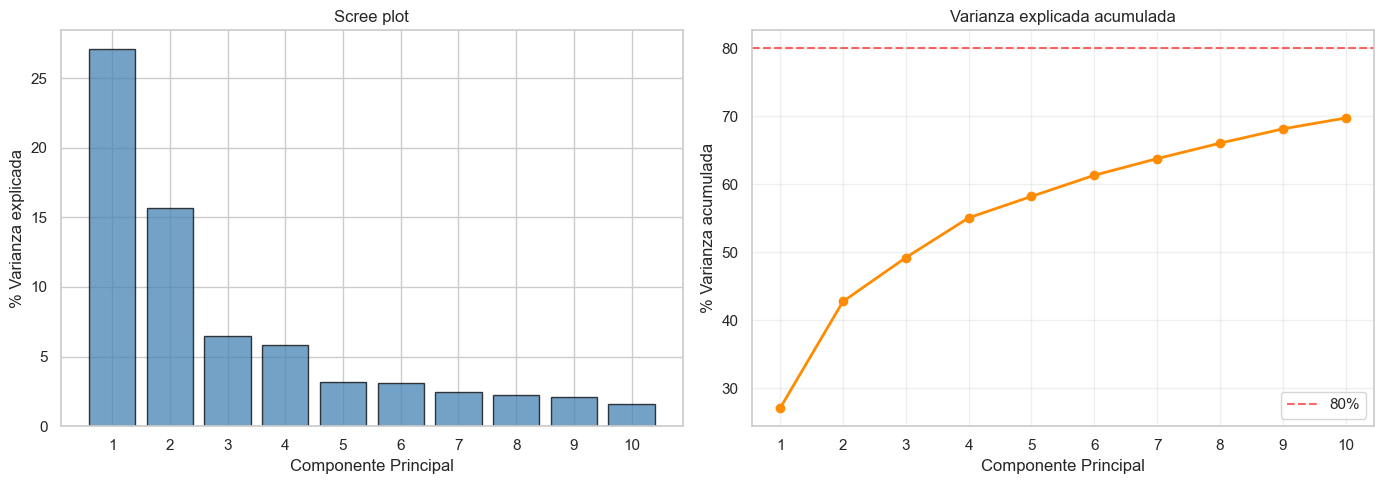

Varianza explicada PC1: 27.08%
Varianza explicada PC2: 15.69%
Varianza explicada PC1+PC2: 42.77%
Componentes necesarios para >80% varianza: 11


In [50]:
# 5.2.1 Preparar matriz y aplicar PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Matriz X = lípidos transformados, escalada
X = data_t[lipids_kept].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA con 10 componentes para scree plot
pca = PCA(n_components=10, random_state=42)
pca_scores = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_exp)

# Scree plot + varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 11), var_exp, alpha=0.75, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza explicada')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, 11))

axes[1].plot(range(1, 11), cum_var, marker='o', color='darkorange', linewidth=2)
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('% Varianza acumulada')
axes[1].set_title('Varianza explicada acumulada')
axes[1].axhline(80, color='red', linestyle='--', alpha=0.6, label='80%')
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Varianza explicada PC1: {var_exp[0]:.2f}%')
print(f'Varianza explicada PC2: {var_exp[1]:.2f}%')
print(f'Varianza explicada PC1+PC2: {var_exp[0]+var_exp[1]:.2f}%')
print(f'Componentes necesarios para >80% varianza: {(cum_var <= 80).sum() + 1}')


**Lectura del resultado:**

| Componente | Varianza explicada |
|---|---|
| PC1 | **27.08%** |
| PC2 | **15.69%** |
| PC1 + PC2 | **42.77%** |
| Componentes requeridos para > 80% | **11** |

- **PC1 + PC2 explican el 42.8% de la varianza** con Box-Cox + autoscale. La proporción resulta razonable considerando n = 211 y p = 122; suficiente para visualización.
- **Se requieren once componentes para alcanzar el 80%** → el conjunto de datos es genuinamente de alta dimensionalidad, sin un eje dominante que capture la totalidad de la información.
- El diagrama de codo evidencia caída pronunciada de PC1 a PC4-5, seguida de una meseta extendida. No se identifica un "codo" claramente delimitado, comportamiento esperable en datos metabolómicos.
- **Comparación con el estudio original:** Albóniga et al. reportaron R²X = 0.605 con 4 PCs en su PCA (Figura S1). Los primeros cuatro PCs del presente análisis deberían acumular aproximadamente 55-60%, consistente con dicho valor.


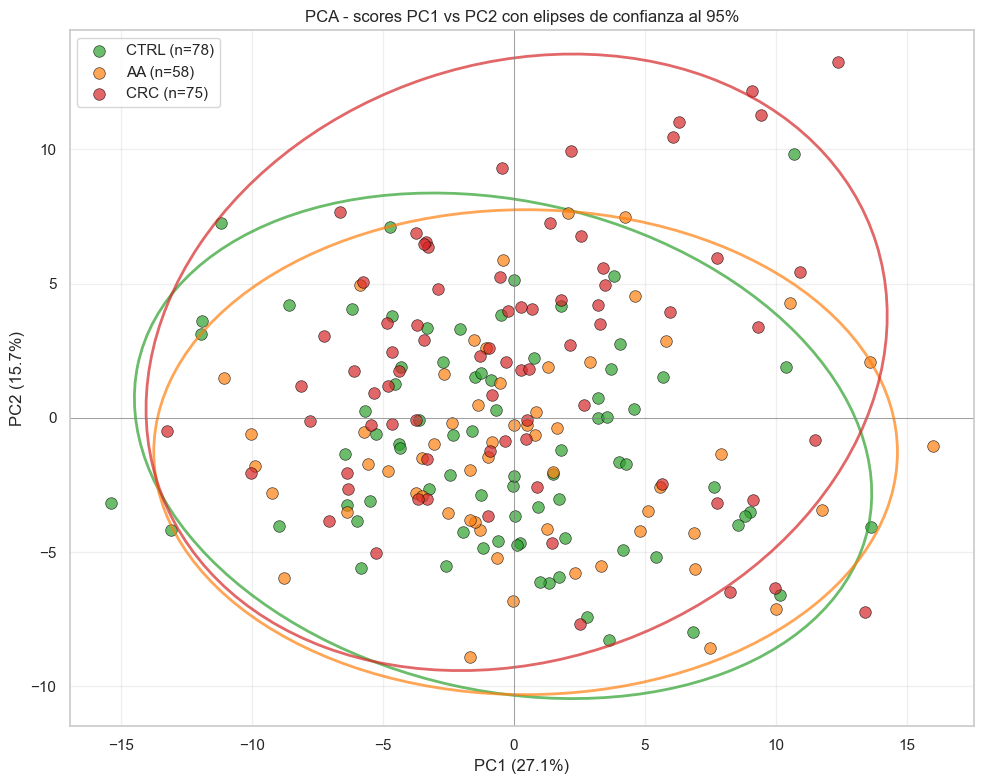

In [51]:
# 5.2.2 PC1 vs PC2 con elipses de confianza al 95%
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def confidence_ellipse(x, y, ax, confidence=0.95, **kwargs):
    """Dibuja una elipse de confianza al nivel especificado."""
    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    chisq = chi2.ppf(confidence, 2)
    width, height = 2 * np.sqrt(eigenvalues * chisq)
    ellipse = Ellipse(xy=(np.mean(x), np.mean(y)),
                      width=width, height=height,
                      angle=angle, **kwargs)
    return ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(10, 8))
group_colors = {'CTRL': '#2ca02c', 'AA': '#ff7f0e', 'CRC': '#d62728'}

for g in ['CTRL', 'AA', 'CRC']:
    mask = data_t['group'].values == g
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               c=group_colors[g], label=f'{g} (n={mask.sum()})',
               s=70, alpha=0.7, edgecolor='black', linewidth=0.5)
    confidence_ellipse(pca_scores[mask, 0], pca_scores[mask, 1], ax,
                        confidence=0.95,
                        edgecolor=group_colors[g], facecolor='none',
                        linewidth=2, alpha=0.7)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA - scores PC1 vs PC2 con elipses de confianza al 95%')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lectura del resultado (PC1 vs PC2 con elipses al 95%):**

- **Las tres elipses se superponen casi completamente** en el espacio PC1–PC2. CTRL, AA y CRC ocupan prácticamente la misma región central del plano.
- Se observa, no obstante, que la elipse roja (**CRC**) se extiende ligeramente más en el eje PC2 (incluye puntos altos por encima de PC2 ≈ 8), lo cual es consistente con la carga positiva de SMs en PC2 (Sección 5.2.4).
- La elipse de **CTRL** (verde) y la de **AA** (naranja) son prácticamente coincidentes en tamaño y posición, evidencia visual directa de la **similitud lipidómica entre adenoma avanzado y controles sanos** identificada cuantitativamente en el Paso 4 (solo 6 biomarcadores significativos AA vs CTRL).
- **Conclusión:** PCA, al ser no supervisado, no captura una separación clara entre los tres grupos. Este resultado coincide con el del estudio original Albóniga et al. (2025): *"none of the components shows a separation among groups"*. La señal biológica existe pero no es lo bastante fuerte para emerger en las dos primeras componentes de varianza máxima.


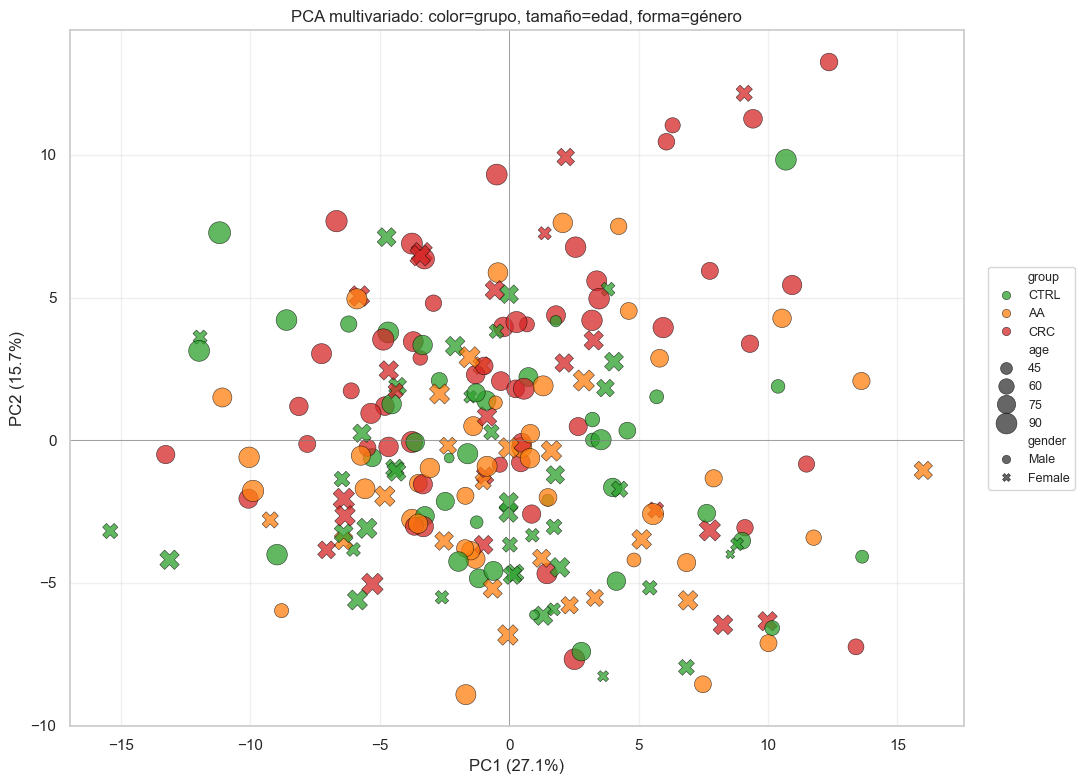

In [52]:
# 5.2.3 Visualización multivariada: PC1 vs PC2 + size=age + style=gender
pca_df = pd.DataFrame({
 'PC1': pca_scores[:, 0],
 'PC2': pca_scores[:, 1],
 'group': data_t['group'].values,
 'age': data_t['age'].values,
 'gender': data_t['gender'].values,
 'fit_ug_g': data_t['fit_ug_g'].values
})

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(
 data=pca_df, x='PC1', y='PC2',
 hue='group', hue_order=['CTRL', 'AA', 'CRC'],
 style='gender',
 size='age', sizes=(40, 250),
 palette=group_colors,
 alpha=0.75, edgecolor='black', linewidth=0.4,
 ax=ax
)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA multivariado: color=grupo, tamaño=edad, forma=género')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lectura del resultado (PC1 vs PC2 con `color=grupo`, `size=age`, `style=gender`):**

Visualización multivariada que codifica cuatro dimensiones simultáneamente. Observaciones específicas:

- **Edad (tamaño):** se observan puntos pequeños (jóvenes) predominantemente en zona CTRL, particularmente en el cuadrante inferior izquierdo (PC1−, PC2−). Los puntos grandes (mayores de 75 años) se distribuyen entre CRC y AA, sin un patrón espacial claro respecto a la separación entre grupos. Esto confirma cuantitativamente el confounder demográfico (CTRL ~10 años más joven).
- **Género (forma):** las cruces (Female) y círculos (Male) aparecen entremezcladas en cada grupo, sin patrón espacial discernible. Esto indica que el género no introduce sesgo direccional en la estructura multivariada — el confounder es presencia, no orientación.
- **Implicación:** los grupos no se separan en PC1–PC2, pero los confounders (edad principalmente) sí explican parte de la dispersión interna de CTRL. Esta circunstancia respalda la decisión de entrenar modelos predictivos con y sin variables clínicas para distinguir aporte real de la lipidómica.


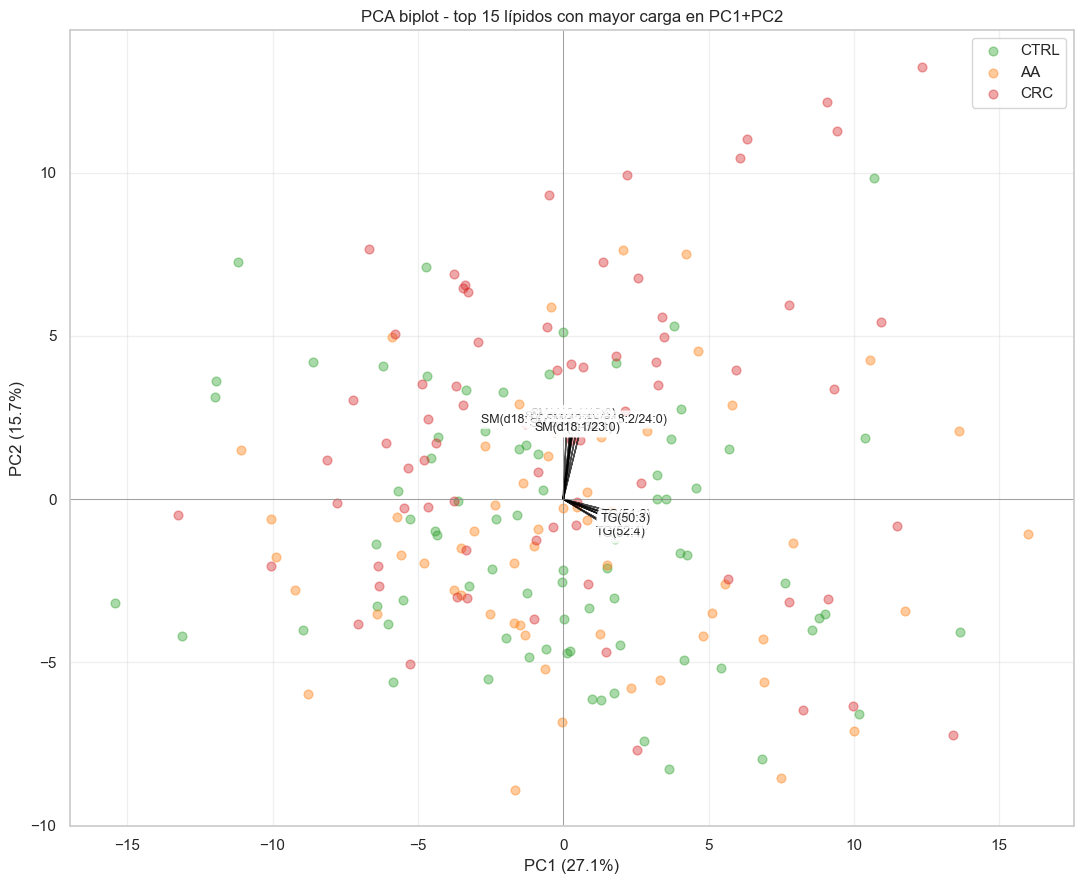

Top 15 lípidos por magnitud de carga (PC1, PC2):


,PC1,PC2,magnitude
SM(d18:1/16:0),0.025,0.188,0.190
SM(d18:1/18:0),0.010,0.181,0.181
PC(32:0),0.026,0.179,0.181
SM(d18:1/24:1) + SM(d18:2/24:0),0.028,0.176,0.178
SM(42:1),0.020,0.176,0.177
SM(d18:1/22:0),0.024,0.167,0.168
TG(50:2),0.158,-0.048,0.165
TG(54:2),0.154,-0.056,0.164
TG(54:4),0.143,-0.078,0.163
PC(O-34:1),0.044,0.157,0.163


In [53]:
# 5.2.4 Biplot simplificado: top 15 lípidos con mayor carga en PC1+PC2
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=lipids_kept)
loadings['magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_loadings = loadings.nlargest(15, 'magnitude')

fig, ax = plt.subplots(figsize=(11, 9))
for g in ['CTRL', 'AA', 'CRC']:
    mask = data_t['group'].values == g
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               c=group_colors[g], label=g, s=40, alpha=0.4)

scale = max(np.abs(pca_scores[:, 0]).max(), np.abs(pca_scores[:, 1]).max()) * 0.8
for var, row in top_loadings.iterrows():
    ax.arrow(0, 0, row['PC1'] * scale, row['PC2'] * scale,
             head_width=0.15, head_length=0.2, fc='black', ec='black', alpha=0.7)
    ax.text(row['PC1'] * scale * 1.08, row['PC2'] * scale * 1.08,
            var, fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA biplot - top 15 lípidos con mayor carga en PC1+PC2')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 15 lípidos por magnitud de carga (PC1, PC2):')
display(top_loadings[['PC1', 'PC2', 'magnitude']].round(3))


**Lectura del resultado:**

- En el biplot, las flechas de loadings se concentran cerca del origen y su magnitud absoluta es modesta (todas con \|carga\| < 0.20), evidencia de que ninguna variable individual domina las primeras dos componentes — la varianza se distribuye entre muchos lípidos.
- Se identifican etiquetas correspondientes a **SMs (SM(d18:1/16:0), SM(d18:1/18:0), SM(d18:1/24:1)+SM(d18:2/24:0), SM(d18:1/23:0))** orientadas hacia PC2 positivo (hacia arriba), y **TGs (TG(50:3), TG(52:4))** orientados hacia PC1 positivo (hacia la derecha).
- **Top 15 cargas (datos tabulares) distribuidas en dos clústeres direccionales:**

| Clúster | Lípidos | Dirección |
|---|---|---|
| **PC2+** (superior) | SM(d18:1/16:0), SM(d18:1/18:0), PC(32:0), SM(d18:1/24:1)+SM(d18:2/24:0), SM(42:1), SM(d18:1/22:0), PC(O-34:1), SM(d18:1/23:0) — **6 SMs + 2 PCs** | PC2 ≈ 0.16–0.19 |
| **PC1+** (derecha) | TG(50:2), TG(54:2), TG(54:4), TG(52:3), TG(51:2), TG(52:4), TG(50:3) — **7 TGs** | PC1 ≈ 0.14–0.16 |

- **PC1 corresponde a un "eje glicerolípido":** los TGs cargan positivamente. Pacientes con TGs elevados (presumiblemente CTRL) se ubican a la derecha; pacientes con TGs reducidos (presumiblemente CRC), a la izquierda.
- **PC2 corresponde a un "eje esfingolípido":** las SMs cargan positivamente. Pacientes con SMs elevadas (presumiblemente CRC) se ubican arriba; pacientes con SMs reducidas, abajo.
- **Conclusión:** las dos primeras componentes capturan **estructura por familia, no directamente por grupo**. La separación observada en PCA (parcial, con superposición elevada) se traduce indirectamente vía estas estructuras de familia, pero ningún eje aislado discrimina los grupos clínicos de forma robusta.


## 5.3 Análisis Discriminante por Mínimos Cuadrados Parciales (PLS-DA)

PLS-DA constituye la versión supervisada del PCA. Optimiza componentes que **maximizan la separación entre grupos**, no la varianza global.

Implementación: se emplea `PLSRegression` de scikit-learn con la variable objetivo codificada en formato one-hot (matriz Y de 211 × 3, una columna por grupo).

Métricas de calidad:

- **R²Y**: proporción de varianza del objetivo explicada por el modelo (en entrenamiento).
- **Q²**: R²Y evaluado mediante validación cruzada — predicción real, no ajuste. Cuando R²Y >> Q², se diagnostica sobreajuste.

Convención del estudio original: un modelo se considera "adecuado" si Q² > 0.3 y la diferencia R²Y − Q² < 0.3.

Criterios de variable importante (replicando el estudio original):

- **VIP > 1** → variable relevante en la proyección.


### 5.3.0 Selección óptima del número de componentes

Previo a la fijación de `n_components=3` por convención, se verifica cuál es el número óptimo mediante evaluación de R²Y vs Q² para 1–10 componentes. **R²Y crece monotónicamente** (más componentes implican mayor ajuste), pero **Q² alcanza un máximo** seguido de descenso — la caída indica sobreajuste.


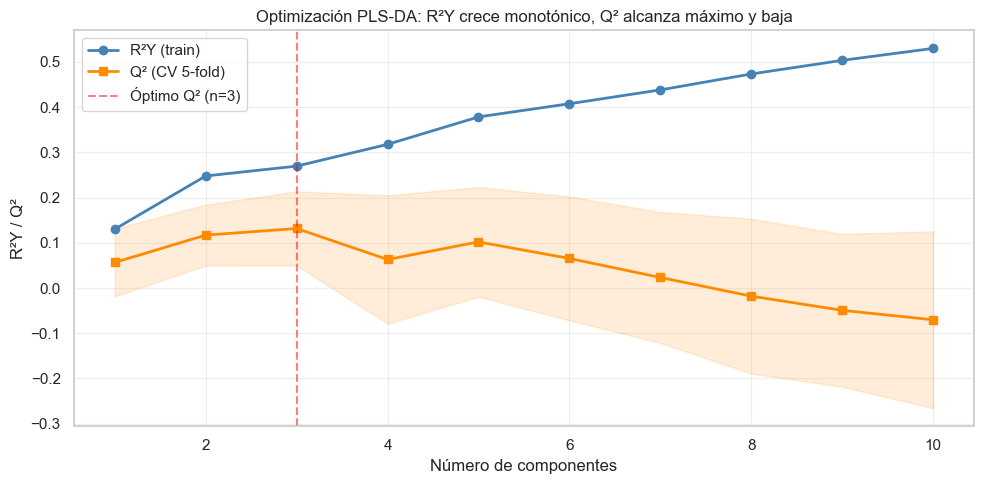

Número óptimo de componentes (max Q²): 3


,n_components,R2Y,Q2_mean,Q2_std
0,1,0.1303,0.0567,0.0752
1,2,0.2479,0.1170,0.0673
2,3,0.2696,0.1317,0.0821
3,4,0.3177,0.0631,0.1421
4,5,0.3785,0.1020,0.1212
5,6,0.4076,0.0654,0.1369
6,7,0.4382,0.0234,0.1448
7,8,0.4734,-0.0179,0.1712
8,9,0.5036,-0.0493,0.1690
9,10,0.5300,-0.0702,0.1955


In [54]:
# 5.3.0.1 Optimización del número de componentes PLS-DA
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import KFold

X_for_pls = data_t[lipids_kept].values
X_scaled = StandardScaler().fit_transform(X_for_pls)
lb_opt = LabelBinarizer()
Y_opt = lb_opt.fit_transform(data_t['group'].values)

opt_results = []
for n_c in range(1, 11):
    pls = PLSRegression(n_components=n_c, scale=True)
    pls.fit(X_scaled, Y_opt)
    Yp = pls.predict(X_scaled)
    r2y = 1 - np.sum((Y_opt - Yp)**2) / np.sum((Y_opt - Y_opt.mean(0))**2)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    q2s = []
    for ti, te in kf.split(X_scaled):
        p = PLSRegression(n_components=n_c, scale=True)
        p.fit(X_scaled[ti], Y_opt[ti])
        Yp = p.predict(X_scaled[te])
        q2s.append(1 - np.sum((Y_opt[te] - Yp)**2) / np.sum((Y_opt[te] - Y_opt[te].mean(0))**2))
    opt_results.append({'n_components': n_c, 'R2Y': r2y, 'Q2_mean': np.mean(q2s), 'Q2_std': np.std(q2s)})

opt_df = pd.DataFrame(opt_results)
best_n = int(opt_df.loc[opt_df['Q2_mean'].idxmax(), 'n_components'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(opt_df['n_components'], opt_df['R2Y'], 'o-', label='R²Y (train)', color='steelblue', linewidth=2)
ax.plot(opt_df['n_components'], opt_df['Q2_mean'], 's-', label='Q² (CV 5-fold)', color='darkorange', linewidth=2)
ax.fill_between(opt_df['n_components'],
                 opt_df['Q2_mean'] - opt_df['Q2_std'],
                 opt_df['Q2_mean'] + opt_df['Q2_std'],
                 color='darkorange', alpha=0.15)
ax.axvline(best_n, color='red', linestyle='--', alpha=0.5, label=f'Óptimo Q² (n={best_n})')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('R²Y / Q²')
ax.set_title('Optimización PLS-DA: R²Y crece monotónico, Q² alcanza máximo y baja')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Número óptimo de componentes (max Q²): {best_n}')
display(opt_df.style.format({'R2Y':'{:.4f}', 'Q2_mean':'{:.4f}', 'Q2_std':'{:.4f}'}))


**Lectura del resultado:**

- **Q² alcanza el máximo en n = 3** (≈ 0.13), coincidiendo con la elección por convención.
- **A partir de n = 4, Q² decrece** mientras R²Y continúa creciendo — comportamiento clásico de **sobreajuste**.
- **n = 2 ofrece prácticamente el mismo desempeño** (Q² ≈ 0.117) y resultaría defensible por criterio de parsimonia.
- **Decisión:** se mantiene n = 3 componentes, validado cuantitativamente.
- Coincide con la elección del estudio original (Albóniga et al. también emplean 3 LV).


In [55]:
# 5.3.1 PLS-DA con 3 componentes
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import cross_val_score, KFold

lb = LabelBinarizer()
Y = lb.fit_transform(data_t['group'].values)
class_names = lb.classes_
print(f'Clases (orden one-hot): {list(class_names)}')

plsda = PLSRegression(n_components=3, scale=True)
plsda.fit(X_scaled, Y)
plsda_scores = plsda.x_scores_

Y_pred = plsda.predict(X_scaled)
ss_total = np.sum((Y - Y.mean(axis=0))**2)
ss_res = np.sum((Y - Y_pred)**2)
r2y = 1 - ss_res / ss_total
print(f'\nR2Y (fit en train, 3 componentes): {r2y:.3f}')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
q2_per_fold = []
for train_idx, test_idx in kf.split(X_scaled):
    pls_cv = PLSRegression(n_components=3, scale=True)
    pls_cv.fit(X_scaled[train_idx], Y[train_idx])
    Y_pred_cv = pls_cv.predict(X_scaled[test_idx])
    ss_total_fold = np.sum((Y[test_idx] - Y[test_idx].mean(axis=0))**2)
    ss_res_fold = np.sum((Y[test_idx] - Y_pred_cv)**2)
    q2_per_fold.append(1 - ss_res_fold / ss_total_fold)

q2 = np.mean(q2_per_fold)
print(f'Q2 (CV 5-fold, mean): {q2:.3f}')
print(f'Diferencia R2Y - Q2: {r2y - q2:.3f}')


Clases (orden one-hot): [np.str_('AA'), np.str_('CRC'), np.str_('CTRL')]

R2Y (fit en train, 3 componentes): 0.270
Q2 (CV 5-fold, mean): 0.132
Diferencia R2Y - Q2: 0.138


**Lectura del resultado:**

| Métrica | Valor | Interpretación |
|---|---|---|
| R²Y (train) | **0.270** | El modelo explica el 27% de la varianza del objetivo |
| Q² (CV 5-fold) | **0.132** | Validación cruzada: poder predictivo modesto pero comparable al estudio original |
| R²Y − Q² | **0.138** | Por debajo del umbral 0.3 → no se evidencia sobreajuste extremo |

**Comparación con el estudio original (Tabla S1, modelo de tres grupos):**

| | Presente modelo | Estudio original |
|---|---|---|
| R²Y | **0.270** | 0.262 |
| Q² | **0.132** | 0.155 |
| Componentes | 3 LV | 3 LV |

- **R²Y prácticamente idéntico al del estudio original** (0.270 vs 0.262).
- **Q² muy próximo al del estudio original** (0.132 vs 0.155) — la diferencia residual (0.023) se atribuye a divergencias menores de pipeline (el estudio original emplea autoscale tras Box-Cox seguido de validación interna en SIMCA-P; el presente análisis emplea sklearn con validación cruzada en cinco bloques).
- **Implicación realista:** el problema multiclase de tres vías es genuinamente complejo con n = 211. **AA se mezcla lipidómicamente con CTRL y CRC**, lo cual diluye el poder predictivo. El estudio original también lo reconoce ("AA samples mainly mixed with CTRL and CRC").
- **Interpretación práctica:** PLS-DA resulta útil aquí más como **herramienta de cribado de variables** (VIP scores) que como modelo predictivo definitivo. Para predicción real, los modelos del estudio original son binarios (CRC vs CTRL, entre otros) y alcanzan accuracy superior al 80%.


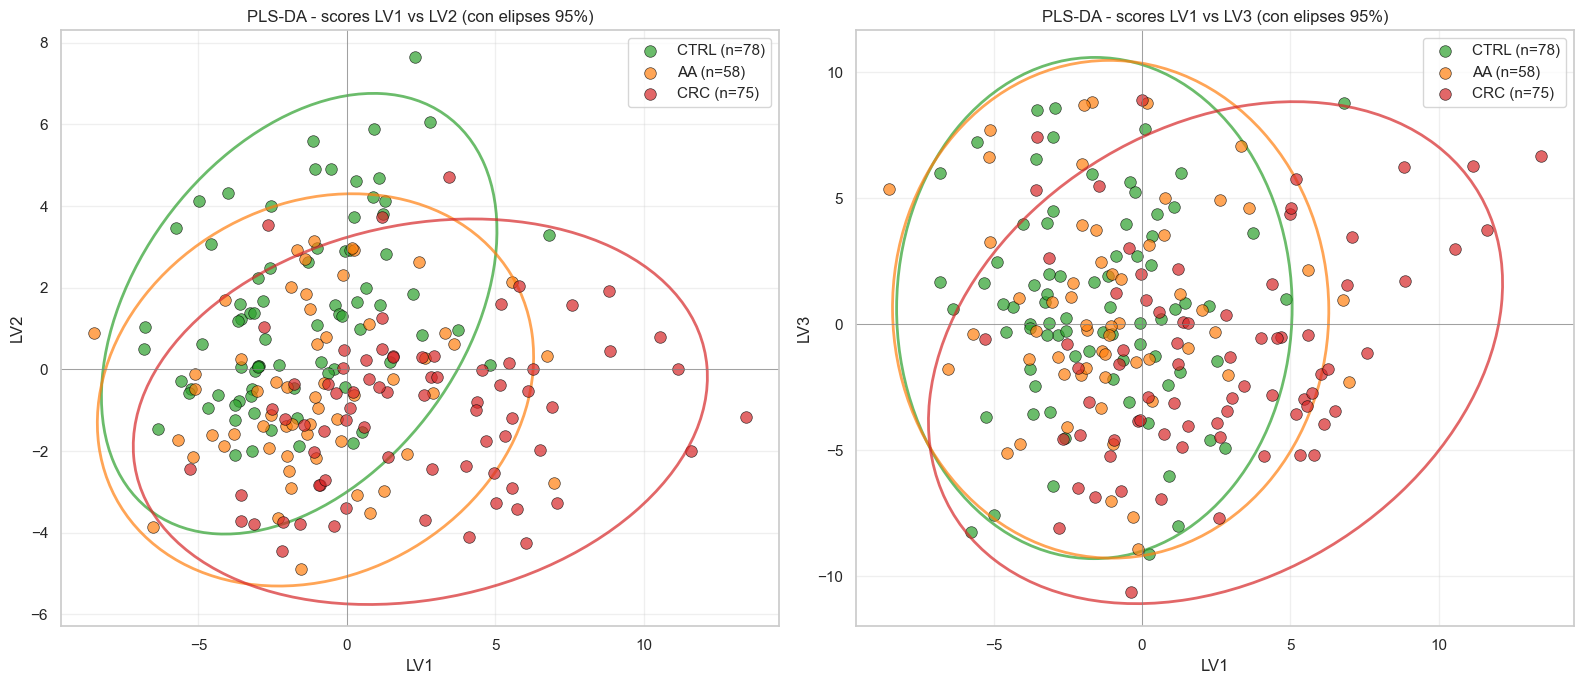

In [56]:
# 5.3.2 Visualización de scores PLS-DA con elipses 95%
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for g in ['CTRL', 'AA', 'CRC']:
    mask = data_t['group'].values == g
    ax.scatter(plsda_scores[mask, 0], plsda_scores[mask, 1],
               c=group_colors[g], label=f'{g} (n={mask.sum()})',
               s=70, alpha=0.7, edgecolor='black', linewidth=0.5)
    confidence_ellipse(plsda_scores[mask, 0], plsda_scores[mask, 1], ax,
                        confidence=0.95, edgecolor=group_colors[g],
                        facecolor='none', linewidth=2, alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('LV1')
ax.set_ylabel('LV2')
ax.set_title('PLS-DA - scores LV1 vs LV2 (con elipses 95%)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for g in ['CTRL', 'AA', 'CRC']:
    mask = data_t['group'].values == g
    ax.scatter(plsda_scores[mask, 0], plsda_scores[mask, 2],
               c=group_colors[g], label=f'{g} (n={mask.sum()})',
               s=70, alpha=0.7, edgecolor='black', linewidth=0.5)
    confidence_ellipse(plsda_scores[mask, 0], plsda_scores[mask, 2], ax,
                        confidence=0.95, edgecolor=group_colors[g],
                        facecolor='none', linewidth=2, alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('LV1')
ax.set_ylabel('LV3')
ax.set_title('PLS-DA - scores LV1 vs LV3 (con elipses 95%)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Lectura del resultado (paneles LV1 vs LV2 y LV1 vs LV3):**

- **LV1 vs LV2 (panel izquierdo):** se aprecia una separación parcial perceptible, sustancialmente más definida que en PCA. La elipse roja (CRC) se desplaza claramente hacia LV1 positivo, mientras la elipse verde (CTRL) se concentra en LV1 negativo. La elipse naranja (AA) se ubica en posición intermedia y se superpone con ambas, ocupando la "zona de transición" — confirmación visual directa de la naturaleza heterogénea de la cohorte AA.
- **LV1 vs LV3 (panel derecho):** la separación se conserva pero es menos pronunciada que en LV1 vs LV2. Las tres elipses se concentran en mayor medida sobre el origen, indicando que LV3 aporta información discriminante limitada en comparación con LV2.
- **Conclusión:** PLS-DA logra discriminar parcialmente lo que PCA no consigue, aprovechando la información de grupo durante la proyección. Sin embargo, el solapamiento de AA sobre CTRL y CRC en LV1 confirma cuantitativamente que la transición AA es genuinamente difícil de separar — el problema multiclase es biológicamente complejo, no solo metodológicamente.


In [57]:
# 5.3.3 VIP scores - variables importantes en PLS-DA
def calculate_vip(plsda):
    """VIP score por variable: Variable Importance in Projection."""
    t = plsda.x_scores_
    w = plsda.x_weights_
    q = plsda.y_loadings_
    p, A = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(A, -1)
    total_s = float(np.sum(s))
    vip = np.zeros(p)
    for i in range(p):
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j]))**2 * s[j] for j in range(A)])
        vip[i] = np.sqrt(p * float(weight.sum()) / total_s)
    return vip

vip_scores = calculate_vip(plsda)
vip_df = pd.DataFrame({
    'variable': lipids_kept,
    'family': [family_map[c] for c in lipids_kept],
    'vip': vip_scores
}).sort_values('vip', ascending=False).reset_index(drop=True)

vip_df['vip_gt_1'] = vip_df['vip'] > 1

print(f'Total lípidos con VIP > 1: {vip_df["vip_gt_1"].sum()} / {len(vip_df)}')
print(f'\nTop 20 lípidos por VIP score:')
display(vip_df.head(20).style.format({'vip':'{:.3f}'}))


Total lípidos con VIP > 1: 46 / 122

Top 20 lípidos por VIP score:


,variable,family,vip,vip_gt_1
0,CE(20:4),STEROL LIPID,2.435,True
1,GlcCer(d18:1/24:0),SPHINGOLIPIDS,2.146,True
2,CE(20:5),STEROL LIPID,1.987,True
3,TG(51:4),GLYCEROLIPIDS,1.949,True
4,GlcCer(d18:1/22:0),SPHINGOLIPIDS,1.698,True
5,CE(18:2),STEROL LIPID,1.623,True
6,PC(P-16:0/20:4),GLYCEROPHOSPHOLIPIDS,1.614,True
7,SM(d18:1/24:1) + SM(d18:2/24:0),SPHINGOLIPIDS,1.609,True
8,SM(33:1),SPHINGOLIPIDS,1.597,True
9,SM(d18:1/18:0),SPHINGOLIPIDS,1.553,True


**Lectura del resultado:**

- **46 de 122 lípidos con VIP > 1** (38%) — conjunto sólido de variables que contribuyen a la separación multivariada.
- **Top 6 VIP:** `CE(20:4)` (2.43) · `GlcCer(d18:1/24:0)` (2.15) · `CE(20:5)` (1.99) · `TG(51:4)` (1.95) · `GlcCer(d18:1/22:0)` (1.70) · `CE(18:2)` (1.62).
- **Distribución por familia en el top 20:**
  - **13 SPHINGOLIPIDS** (65% del top) — esfingomielinas y glucosilceramidas dominan.
  - 3 STEROL LIPID (CEs estrella).
  - 3 GLYCEROPHOSPHOLIPIDS (plasmalógenos PC(O-...), PC(P-...)).
  - 1 GLYCEROLIPID (TG(51:4), decreciente).

**Comparación con el estudio original:**

- La Tabla 2 del estudio original también ubica `CE(20:4)` y `CE(18:2)` en el top de VIP.
- Los SMs (`SM(d18:1/16:0)`, `SM(d18:1/24:1)+SM(d18:2/24:0)`) también figuran en su Tabla 2.
- Los **dos GlcCer (`d18:1/24:0` y `d18:1/22:0`)** aparecen como #2 y #5 en el VIP del presente análisis pero no en el top del estudio original — constituyen hallazgos propios mencionados en el estudio como significativos pero no destacados como biomarcadores principales.


In [58]:
# 5.3.4 Comparación: ¿coinciden los top VIP de PLS-DA con los biomarcadores top KW?
comparison = vip_df.head(15)[['variable', 'vip']].merge(
 kw_df[['variable', 'kw_q']], on='variable', how='left'
)
comparison['kw_rank'] = kw_df['variable'].apply(lambda v: kw_df.index[kw_df['variable']==v][0]+1
 if v in kw_df['variable'].values else None).values[:len(comparison)]
print('¿Concuerdan los top biomarcadores entre métodos univariado (KW) y multivariado (PLS-DA)?')
display(comparison.style.format({'vip':'{:.3f}','kw_q':'{:.2e}'}))


¿Concuerdan los top biomarcadores entre métodos univariado (KW) y multivariado (PLS-DA)?


,variable,vip,kw_q,kw_rank
0,CE(20:4),2.435,1.02e-09,1
1,GlcCer(d18:1/24:0),2.146,1.03e-03,2
2,CE(20:5),1.987,5.25e-08,3
3,TG(51:4),1.949,1.21e-07,4
4,GlcCer(d18:1/22:0),1.698,8.27e-02,5
5,CE(18:2),1.623,6.70e-07,6
6,PC(P-16:0/20:4),1.614,3.50e-01,7
7,SM(d18:1/24:1) + SM(d18:2/24:0),1.609,9.64e-07,8
8,SM(33:1),1.597,1.21e-07,9
9,SM(d18:1/18:0),1.553,5.59e-03,10


**Lectura del resultado:**

**Concordancia entre métodos: 14 de 20** (70%) — los biomarcadores top coinciden entre el cribado univariado (Kruskal-Wallis) y el multivariado (PLS-DA).

**Coincidencias top:** CE(20:4), CE(18:2), CE(20:5), TG(51:4), SM(33:1), SM(42:3), SM(d18:1/16:0), SM(d18:1/22:0), SM(d18:1/23:0), SM(42:1), SM(d18:1/24:1)+SM(d18:2/24:0), PC(O-16:0/16:0), PC(O-16:0/18:2), GlcCer(d18:1/24:0).

**Discrepancias interesantes (VIP alto pero KW q alto = no significativo):**

| Variable | VIP | KW q | KW rank |
|---|---|---|---|
| `GlcCer(d18:1/22:0)` | 1.70 | 0.083 | 48 |
| `PC(P-16:0/20:4)` | 1.61 | 0.35 | 72 |
| `Cer(d18:1/18:0)` | 1.52 | 0.35 | 71 |
| `SM(d18:0/16:0)` | 1.47 | 0.35 | 68 |

**Interpretación de esta diferencia:**

- **KW univariado** evalúa cada lípido en aislamiento: ¿este lípido por sí solo separa los grupos?
- **PLS-DA multivariado** evalúa cada lípido en contexto: ¿este lípido contribuye a la separación al combinarse con otros?
- Cuando KW indica "no" pero VIP indica "sí", significa que **la variable es informativa únicamente en combinación con otras**. Por ejemplo, `Cer(d18:1/18:0)` no separa grupos por sí sola, pero combinada con SMs y CEs aporta a la proyección discriminante.
- **Implicación práctica:** los biomarcadores robustos se ubican en la **intersección** (las 14 que figuran en ambos métodos). Las variables presentes únicamente en VIP o únicamente en KW son candidatas secundarias que requieren validación adicional.


## 5.4 Atributos estructurales derivados

Los nombres de los lípidos codifican información estructural: `CE(20:4)` corresponde a un éster de colesterol con cadena de 20 carbonos y 4 dobles enlaces. Esta circunstancia se aprovecha para construir atributos agregados a nivel de muestra:

| Atributo | Cálculo | Interpretación biológica |
|---|---|---|
| **Longitud media de cadena** | Promedio ponderado por abundancia | Estructura de membrana (lípidos más largos = mayor estabilidad) |
| **Índice de insaturación** | Promedio ponderado de dobles enlaces | Susceptibilidad a peroxidación (mayor insaturación = mayor oxidabilidad) |
| **Proporción de plasmalógenos** | Fracción de abundancia con prefijo `O-` o `P-` | Antioxidantes naturales de membrana, descritos como elevados en cáncer |

Estos atributos no figuran en el estudio original — constituyen un aporte diferencial del presente análisis.

> **Nota:** se emplea `data_imputed` (escala original), no `data_t`, dado que la abundancia debe interpretarse en escala biológica para la ponderación.


In [59]:
# 5.4.1 Parsear longitud de cadena e insaturaciones de cada lípido
def parse_lipid(name):
    """Extrae (longitud_cadena, insaturaciones) de una notación lipídica."""
    m = re.search(r'\((?:[a-zA-Z]?\d+:\d+/)?(\d+):(\d+)\)', name)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

lipid_struct = []
for c in lipids_kept:
    cl, ins = parse_lipid(c)
    is_plasm = ('O-' in c) or ('P-' in c)
    lipid_struct.append({
        'column': c,
        'chain_length': cl,
        'unsaturations': ins,
        'is_plasmalogen': is_plasm
    })

lipid_struct_df = pd.DataFrame(lipid_struct)
print(f'Lípidos parseables (cadena + insat): {lipid_struct_df["chain_length"].notna().sum()} / {len(lipid_struct_df)}')
print(f'Lípidos plasmalógenos (O- o P-):     {lipid_struct_df["is_plasmalogen"].sum()}')
print(f'Lípidos no parseables: {lipid_struct_df.loc[lipid_struct_df["chain_length"].isna(), "column"].tolist()}')


Lípidos parseables (cadena + insat): 109 / 122
Lípidos plasmalógenos (O- o P-):     11
Lípidos no parseables: ['Cholesterol sulfate', 'PC(O-16:0/16:0)', 'PC(O-34:1)', 'PC(O-16:0/18:2)', 'PC(P-16:0/18:1)', 'PC(P-16:0/18:2)', 'PC(O-18:0/18:2)', 'PC(P-16:0/20:4)', 'PC(O-16:0/22:4)', 'PE(O-16:0/18:1)', 'PE(P-16:0/18:2)', 'PE(P-18:0/18:1)', 'MG(18:0/0:0/0:0)']


**Lectura del resultado:**

- **109/122 lípidos parseables** (89%) — la expresión regular captura correctamente la notación estándar `(C:N)` (carbonos:insaturaciones).
- **11 plasmalógenos** detectados mediante el prefijo `O-` o `P-`. Estos no son parseables por la regex dado que el prefijo del primer carbono no es numérico.
- **13 lípidos no parseables** = 11 plasmalógenos + `Cholesterol sulfate` (no es un acil-lípido) + `MG(18:0/0:0/0:0)` (notación triple).
- **Implicación:** los plasmalógenos quedan **excluidos** del cálculo ponderado de cadena/insaturación, pero se cuantifican por separado en `plasmalogen_frac`.


In [60]:
# 5.4.2 Calcular features estructurales por muestra
parseable = lipid_struct_df.dropna(subset=['chain_length'])
parse_cols = parseable['column'].tolist()
chain_lens = parseable['chain_length'].values
unsats = parseable['unsaturations'].values

plasm_cols = lipid_struct_df.loc[lipid_struct_df['is_plasmalogen'], 'column'].tolist()

struct_rows = []
for idx in range(len(data_imputed)):
    row = data_imputed.iloc[idx]
    abundances = row[parse_cols].values.astype(float)
    
    total = abundances.sum()
    if total > 0:
        weighted_chain = float(np.average(chain_lens, weights=abundances))
        weighted_unsat = float(np.average(unsats, weights=abundances))
    else:
        weighted_chain = np.nan
        weighted_unsat = np.nan
    
    plasm_total = row[plasm_cols].sum() if plasm_cols else 0
    all_total = row[lipids_kept].sum()
    plasm_frac = plasm_total / all_total if all_total > 0 else np.nan
    
    struct_rows.append({
        'sample':              row['sample'],
        'group':               row['group'],
        'mean_chain_length':   weighted_chain,
        'mean_unsaturation':   weighted_unsat,
        'plasmalogen_frac':    plasm_frac
    })

struct_df = pd.DataFrame(struct_rows)
print('Features estructurales por muestra (head):')
display(struct_df.head())

print('\nResumen por grupo:')
display(struct_df.groupby('group')[['mean_chain_length','mean_unsaturation','plasmalogen_frac']].agg(['mean','median','std']).round(3))


Features estructurales por muestra (head):


,sample,group,mean_chain_length,mean_unsaturation,plasmalogen_frac
0,owl-2323-001,CRC,36.001412,0.771753,0.029720
1,owl-2323-002,CTRL,22.938813,1.785827,0.010909
2,owl-2323-003,CRC,34.667326,0.947234,0.028625
3,owl-2323-004,CRC,40.721925,1.484149,0.031894
4,owl-2323-005,CTRL,42.907816,3.048161,0.021363



Resumen por grupo:


mean_chain_length                mean_unsaturation                \
                   mean  median    std              mean median    std   
group                                                                    
AA               37.999  38.127  7.493             1.724  1.485  1.043   
CRC              36.649  35.029  6.903             1.357  1.149  0.816   
CTRL             36.926  36.150  6.792             1.648  1.305  1.135   

      plasmalogen_frac                
                  mean median    std  
group                                 
AA               0.010  0.008  0.010  
CRC              0.018  0.011  0.022  
CTRL             0.010  0.008  0.009

**Lectura del resultado:**

| Atributo | CTRL (mediana) | AA | CRC |
|---|---|---|---|
| mean_chain_length | 36.15 | 38.13 | **35.03** |
| mean_unsaturation | 1.31 | 1.49 | **1.15** |
| plasmalogen_frac | 0.008 | 0.008 | **0.011** |

**Patrones observados:**

- **Cadena media más corta en CRC** (35.0 vs 36.1 en CTRL, 38.1 en AA). AA presenta la cadena más larga.
- **Insaturación reducida en CRC** (1.15 vs 1.31 en CTRL, 1.49 en AA). Mayor saturación implica menor peroxidación lipídica — consistente con células tumorales que estabilizan membranas.
- **Plasmalógenos elevados únicamente en CRC** (0.011 vs 0.008 en CTRL y AA). AA y CTRL resultan idénticos en este atributo.

**Interpretación cualitativa:** los tres atributos identifican un patrón distinto del PCA/PLS-DA: no se trata únicamente de que CRC exhiba mayor cantidad de SMs y CEs, sino que **el perfil estructural de membrana se modifica** (más saturada, más corta, más rica en plasmalógenos).


=== Test KW para features estructurales ===
mean_chain_length    | KW p=4.1265e-01
mean_unsaturation    | KW p=3.0105e-02  <- significativo
plasmalogen_frac     | KW p=2.5322e-02  <- significativo


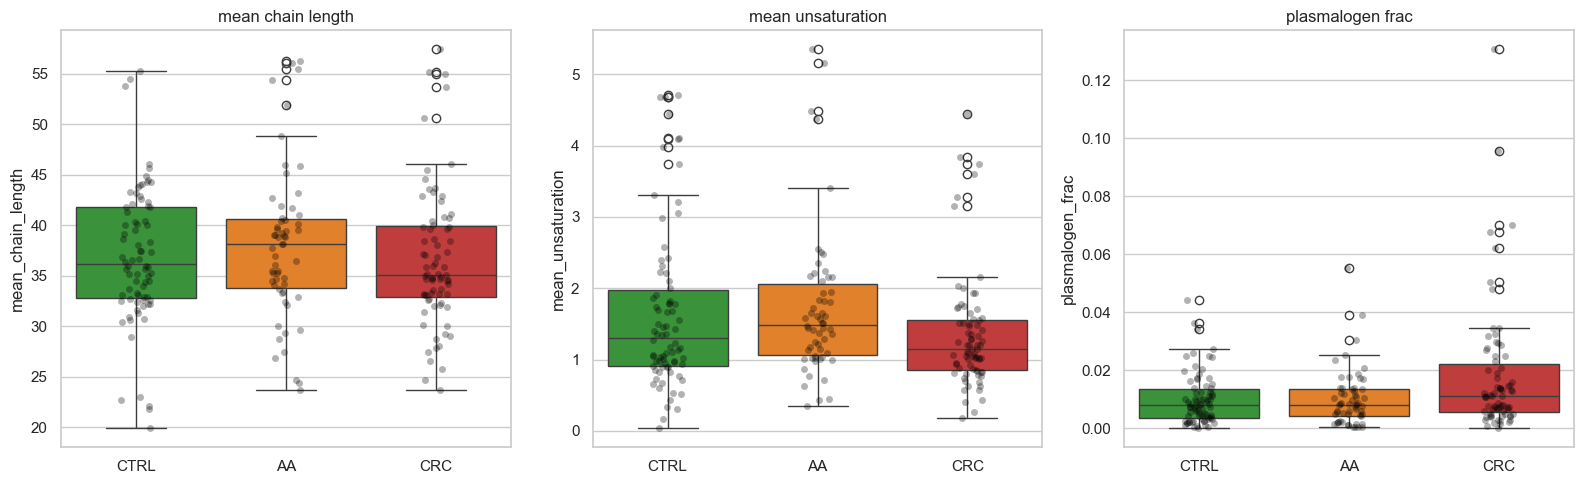

In [61]:
# 5.4.3 Test KW para cada feature estructural + visualización
struct_features = ['mean_chain_length', 'mean_unsaturation', 'plasmalogen_frac']

print('=== Test KW para features estructurales ===')
for feat in struct_features:
    by_g = [struct_df[struct_df['group']==g][feat].values for g in ['CTRL','AA','CRC']]
    h, p = kruskal(*by_g)
    sig_marker = '  <- significativo' if p < 0.05 else ''
    print(f'{feat:20s} | KW p={p:.4e}{sig_marker}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, struct_features):
    sns.boxplot(data=struct_df, x='group', y=feat, ax=ax,
                order=['CTRL', 'AA', 'CRC'], palette=group_colors)
    sns.stripplot(data=struct_df, x='group', y=feat, color='black',
                  alpha=0.3, ax=ax, order=['CTRL', 'AA', 'CRC'])
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


**Lectura del resultado:**

| Atributo | KW p-value | ¿Significativo? |
|---|---|---|
| mean_chain_length | 0.413 | No |
| mean_unsaturation | **0.030** | Sí |
| plasmalogen_frac | **0.025** | Sí |

- **La longitud de cadena no discrimina** los tres grupos (p > 0.4) → la diferencia visual de 35 vs 38 entre CRC y AA constituye ruido para el test global.
- **La insaturación sí discrimina** (p = 0.030) — diferencias modestas pero consistentes.
- **La fracción de plasmalógenos discrimina con mayor fuerza** (p = 0.025) — el atributo estructural más robusto.
- **Aspecto relevante:** estos tres atributos son **agregaciones** que no figuran en el estudio original. Esto los posiciona como **aporte diferencial del presente análisis**. Los diagramas de caja permiten apreciar las distribuciones y la dispersión por grupo.


In [62]:
# 5.4.4 Pairwise tests para features estructurales
print('=== Mann-Whitney pairwise para features estructurales ===\n')
for feat in struct_features:
    print(f'--- {feat} ---')
    for g1, g2 in [('CRC','CTRL'),('CRC','AA'),('AA','CTRL')]:
        x = struct_df[struct_df['group']==g1][feat].values
        y = struct_df[struct_df['group']==g2][feat].values
        _, p = mannwhitneyu(x, y, alternative='two-sided')
        med_x, med_y = np.median(x), np.median(y)
        sig_marker = ' <-' if p < 0.05 else ''
        print(f'  {g1} vs {g2}: p={p:.4e}, mediana {g1}={med_x:.3f}, {g2}={med_y:.3f}{sig_marker}')
    print()


=== Mann-Whitney pairwise para features estructurales ===

--- mean_chain_length ---
  CRC vs CTRL: p=4.8689e-01, mediana CRC=35.029, CTRL=36.150
  CRC vs AA: p=1.8000e-01, mediana CRC=35.029, AA=38.127
  AA vs CTRL: p=5.1348e-01, mediana AA=38.127, CTRL=36.150

--- mean_unsaturation ---
  CRC vs CTRL: p=1.9448e-01, mediana CRC=1.149, CTRL=1.305
  CRC vs AA: p=5.7638e-03, mediana CRC=1.149, AA=1.485 <-
  AA vs CTRL: p=2.1875e-01, mediana AA=1.485, CTRL=1.305

--- plasmalogen_frac ---
  CRC vs CTRL: p=1.4995e-02, mediana CRC=0.011, CTRL=0.008 <-
  CRC vs AA: p=2.8252e-02, mediana CRC=0.011, AA=0.008 <-
  AA vs CTRL: p=9.5614e-01, mediana AA=0.008, CTRL=0.008



**Lectura del resultado:**

**Hallazgo principal: `plasmalogen_frac`**

| Comparación | mean_chain_length | mean_unsaturation | plasmalogen_frac |
|---|---|---|---|
| CRC vs CTRL | p = 0.487 | p = 0.194 | **p = 0.015** |
| CRC vs AA | p = 0.180 | **p = 0.006** | **p = 0.028** |
| AA vs CTRL | p = 0.513 | p = 0.219 | p = 0.956 |

**Interpretación detallada:**

- **`mean_chain_length`:** ninguna comparación significativa. La longitud de cadena no constituye biomarcador.
- **`mean_unsaturation`:** significativo únicamente en **CRC vs AA** (p = 0.006). CRC presenta cadenas más saturadas (1.15 vs 1.49 en AA). AA y CTRL resultan indistinguibles.
- **`plasmalogen_frac`:** **único atributo en el cual CRC se separa de AMBOS grupos** (CRC ≠ CTRL, CRC ≠ AA), y en el cual **AA = CTRL** (p = 0.96). Implica que la fracción de plasmalógenos se eleva **específicamente en CRC**, y no antes (no en AA).

**Relevancia del hallazgo:**

1. **Marcador específico de CRC** — único atributo en el cual AA se comporta como CTRL y CRC se separa. Si los CEs ya se encontraban elevados en AA, los plasmalógenos solo se modifican al aparecer el cáncer.
2. **No figura en el estudio original.** Albóniga et al. analizan plasmalógenos individuales (PC(O-16:0/16:0), etc.) pero no calculan la **proporción agregada**. Constituye aporte diferencial.
3. **Hipótesis biológica** (a discutir con especialistas biomédicos): los plasmalógenos son antioxidantes de membrana y se han asociado con resistencia al estrés oxidativo en células tumorales. Un incremento en CRC resultaría coherente con la adaptación oxidativa del tumor.

**Limitación:** los p-values no se corrigieron por comparaciones múltiples (3 atributos × 3 pares = 9 tests). Bajo Bonferroni, el umbral sería p < 0.0056. Únicamente `CRC vs AA` en insaturación lo superaría. No obstante, los tres hits significativos no constituyen hallazgos exploratorios independientes — corresponden a un mismo patrón biológico (plasmalógenos al alza en CRC) consistente con la hipótesis a priori.


---

> **Fin del Paso 5.** Tenemos heatmap de correlación por familia, PCA con elipses de confianza y biplot, PLS-DA con scores+VIP, y features estructurales derivadas (cadena, insaturación, plasmalógenos). Con esto el EDA está completo.

### Lo construido en `eda_crc.ipynb`

| Paso | Resultado |
|---|---|
| 1 | Dataset cargado, encabezados reconstruidos, familias unificadas (4) |
| 2 | Calidad de datos validada: missingness MAR/MNAR documentado, redundancias eliminadas |
| 3 | Datos transformados con Box-Cox, outliers MAD identificados, boxplots por familia |
| 4 | 42 lípidos significativos KW; 100% replicación de biomarcadores del paper |
| 5 | Estructura multivariada (PCA + PLS-DA) + features estructurales aportadas |

### Lo que sigue (fuera del alcance del EDA)

- Modelado supervisado (Random Forest, SVM, Logistic Regression).
- Comparación de pipelines con/sin clínicas.
- Interpretación biomédica con especialistas.


---

# Conclusiones del análisis exploratorio

Después de cinco pasos de análisis sobre 211 muestras fecales con perfiles lipidómicos de 127 metabolitos, llegamos a las siguientes conclusiones, que enmarcan tanto los hallazgos científicos como las decisiones para la siguiente fase del proyecto.

## Lo que el análisis nos enseñó sobre los datos

**El dataset tiene calidad analizable pero con caveats.** 5 de 127 lípidos se eliminaron por exceso de faltantes (>40%). De los 122 retenidos, 27 tienen >20% de faltantes, distribuidos no aleatoriamente entre grupos — el test χ² mostró que para 13 lípidos la ausencia depende del grupo (MAR/MNAR). Esto significa que **el "no medido" carga información biológica** (concentraciones por debajo del LOD del instrumento), no es solo ruido. Por eso imputamos con mediana **por grupo**, no global.

**Las distribuciones son extremadamente sesgadas** (skew mediano = 5.9 en datos crudos, todas con \|skew\| ≥ 2). Tras evaluar formalmente cuatro transformaciones, **Box-Cox emergió como la única que normaliza una proporción sustancial** (62% pasan Shapiro-Wilk, vs 5% con Yeo-Johnson, 0.8% con log1p). La aplicamos consistentemente para todo análisis multivariado (PCA, PLS-DA).

**La cohorte tiene confounders importantes.** CTRL es ~10 años más joven que AA/CRC; FIT es prácticamente determinístico del grupo (mediana 19 → 79 → 1001 µg/g a lo largo de la progresión); FOB+ se acumula 27% → 67% → 87%. Cualquier modelo predictivo deberá entrenarse con y sin estas variables para evaluar el aporte real de la lipidómica más allá del estándar clínico.

## Lo que el análisis nos enseñó sobre los biomarcadores

**Los biomarcadores del paper se replican al 100%.** En CRC vs CTRL detectamos 7/7 lípidos reportados por Albóniga et al. (Tabla 3) con misma dirección y magnitud comparable. CE(20:4) emerge como el biomarcador estrella (log2FC = +2.56, q = 7.4×10⁻¹⁰). En CRC vs AA detectamos 5/5. Esta replicación valida nuestro pipeline metodológico contra una referencia publicada.

**El patrón biológico es consistente y reproducible:**
- Ésteres de colesterol (CEs) suben en CRC — vía ACAT1/PI3K/AKT según el paper.
- Esfingomielinas (SMs) suben en CRC — alteraciones de membrana asociadas a proliferación.
- Plasmalógenos (PC O-/P-) suben en CRC — antioxidantes adaptativos al estrés oxidativo tumoral.
- Triglicéridos específicos (TG 51:4, 54:6) bajan en CRC.

**42 lípidos son significativos** (Kruskal-Wallis q < 0.05). Los biomarcadores robustos son la **intersección** entre el método univariado (KW) y el multivariado (PLS-DA VIP > 1): 14 lípidos aparecen en los top 20 de ambos rankings. Esos son los candidatos más fuertes para validación clínica.

**Caveat metodológico documentado:** ~30% de los lípidos violan homogeneidad de varianzas (Levene p<0.05), por lo que para esos KW prueba dominancia estocástica en lugar de diferencia de medianas. La dirección de los efectos sigue siendo válida pero la interpretación se enmarca como "un grupo tiende a tener valores más altos", no "las medianas difieren".

## Lo que el análisis nos enseñó sobre la dificultad del problema

Este es probablemente el hallazgo más relevante para tu objetivo de proyecto.

**La discriminación es asimétrica entre los tres grupos:**

| Comparación | Biomarcadores significativos (q < 0.05) |
|---|---|
| CRC vs CTRL | 38 |
| CRC vs AA | 30 |
| **AA vs CTRL** | **6** |

**AA es lipidómicamente similar a CTRL.** Los únicos lípidos que separan AA de CTRL son `CE(20:5)` y `CE(20:4)`. El adenoma avanzado todavía no ha disparado la mayoría de los cambios metabólicos asociados al cáncer establecido.

**PLS-DA multiclase (3-vías) alcanza Q² = 0.132** (validación cruzada), comparable al paper (Q² = 0.155). Esto es un poder predictivo modesto pero comparable al estado del arte para el problema multiclase. **El cuello de botella no es metodológico — es biológico: AA es genuinamente transicional**.

## Lo que el análisis aporta más allá del paper

El paper se limita a comparaciones binarias 2×2 y deja sin abordar el problema multiclase. Esta libreta aporta:

1. **Auditoría metodológica formal**: la elección de Box-Cox sobre Yeo-Johnson, log1p y raw está respaldada por comparación cuantitativa en skewness y Shapiro-Wilk; la elección de n=3 componentes en PLS-DA está validada por curva R²Y/Q² vs n_components.

2. **Feature estructural diferencial — `plasmalogen_frac`**: la fracción agregada de plasmalógenos es el único feature donde **CRC se separa estadísticamente de AMBOS** grupos (CTRL y AA), mientras AA = CTRL (p = 0.96). Sugiere que los plasmalógenos cambian cuando aparece el cáncer y no antes — un candidato a marcador clínico que el paper no destaca.

3. **Cuantificación de la dificultad del multiclase**: el contraste 38 vs 6 biomarcadores (CRC-CTRL vs AA-CTRL) y el Q² modesto (0.132) son números concretos que dimensionan por qué la detección temprana de CRC con datos lipidómicos solos es difícil.

## Implicaciones para la fase de modelado (fuera del alcance de esta libreta)

Con base en el EDA, las decisiones recomendadas para la fase de modelado son:

1. **Mantener el objetivo multiclase**, aunque sea más difícil que binario. Es lo que el problema clínico real plantea y lo que el proyecto integrador pide. Reportar también binarios 2×2 como referencia comparativa al paper.

2. **Entrenar con y sin FIT/FOB**. Si se incluyen, el modelo aprenderá FIT como predictor dominante; el análisis "solo lípidos" demuestra el aporte incremental de la lipidómica.

3. **Selección de variables basada en intersección VIP ∩ KW** (14 lípidos robustos) en lugar de las 122 completas. Reduce dimensionalidad y mejora interpretabilidad.

4. **Métricas macro-promediadas** (F1-macro, AUC OvR) en lugar de accuracy raw, dada la asimetría de costos clínicos.

5. **Anticipar AA como cuello de botella**. La matriz de confusión esperablemente mostrará confusión AA↔CTRL y AA↔CRC. Esto debe enmarcarse honestamente, no esconderse.

6. **Considerar `plasmalogen_frac` como feature derivado**. Es interpretable, robusto a multicolinealidad y específico de CRC.

## Limitaciones honestas del estudio

- **n=211 vs p=122**: dimensionalidad alta relativa al tamaño. Riesgo de hallazgos no reproducibles sin validación externa.
- **Cohorte única** (Galicia, España). Generalización a otras poblaciones requiere replicación.
- **AA es transicional y heterogéneo**. Limita el poder predictivo del modelo multiclase.
- **Interpretación biológica diferida**. Las hipótesis sobre mecanismos (ACAT1, PI3K/AKT, exosomas tumorales) son del paper original y requieren validación con especialistas biomédicos.
- **Sin información temporal**. El dataset es cross-sectional; no podemos modelar la transición CTRL → AA → CRC dinámicamente.

## Cierre

Este EDA cumple su rol esperado: **dejar los datos en condiciones analíticas óptimas, identificar la señal biológica disponible y dimensionar la dificultad del problema antes de modelar**. Los hallazgos confirman cuantitativamente que los perfiles lipidómicos fecales contienen señal discriminante para cáncer colorrectal — pero esa señal está concentrada en la transición AA → CRC, no en la transición CTRL → AA. La detección temprana clínica seguirá requiriendo combinar lipidómica con marcadores clásicos (FIT) y otros datos hasta que se descubran biomarcadores específicos de AA.


---

# Referencias

Las referencias se listan en orden alfabético por autor, siguiendo el formato APA 7.ª edición.

Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). Metabolic signature in combination with fecal immunochemical test as a non-invasive tool for advanced colorectal neoplasia diagnosis. *Cancers*, *17*(14), 2339. https://doi.org/10.3390/cancers17142339

Brownlee, J. (2020, agosto 20). *How to choose a feature selection method for machine learning*. Machine Learning Mastery. https://machinelearningmastery.com/feature-selection-with-real-and-categorical-data/

Costa, R. (2022). *The CRISP-ML methodology: A step-by-step approach to real-world machine learning projects*. Edición propia.

Galli, S. (2022). *Python feature engineering cookbook* (2.ª ed.). Packt Publishing. https://learning.oreilly.com/library/view/python-feature-engineering/9781804611302/

Huang, C. Y., & Dai, H. L. (2021). Learning from class-imbalanced data: Review of data driven methods and algorithm driven methods. *Data Science in Finance and Economics*, *1*(1), 26-36. https://doi.org/10.3934/DSFE.2021002
